In [1]:
# !pip install networkx pandas torch torch-geometric
# !pip install torch-scatter
# !pip install optuna

In [2]:
import random
import time
from datetime import datetime
import collections
import csv

# Numerical and data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Network analysis
import networkx as nx

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score,  roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# PyTorch core
import torch
import torch.nn as nn
import torch.nn.functional as F

# PyTorch Geometric
from torch_geometric.data import Data, HeteroData
from torch_geometric.utils import from_networkx
from torch_geometric.nn import (
    HeteroConv,
    GATv2Conv,
    TransformerConv,
    GCNConv,
    MessagePassing
)
from torch_geometric.loader import DataLoader
from collections import Counter, defaultdict

#optuna
import optuna

/home/rshrestha1/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# def set_seed(seed):
#     torch.manual_seed(seed)
#     torch.cuda.manual_seed(seed)
#     np.random.seed(seed)
#     random.seed(seed)
#     torch.backends.cudnn.deterministic = True
#     torch.backends.cudnn.benchmark = False

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

In [4]:
class HeteroGCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        
        self.dropout = nn.Dropout(0.05)
        
        self.conv1 = HeteroConv({
            ('company', 'supply', 'company'): TransformerConv(
                in_channels, hidden_channels, edge_dim=3, heads=10, concat = False),
            ('company', 'boardex', 'company'): TransformerConv(
                in_channels, hidden_channels, edge_dim=3, heads=10, concat = False),
            ('company', 'competition', 'company'): TransformerConv(
                in_channels, hidden_channels, edge_dim=3, heads=10, concat = False),
        }, aggr='cat')

        self.conv2 = HeteroConv({
            ('company', 'supply', 'company'): TransformerConv(
                hidden_channels * 3, out_channels, edge_dim=3, heads=1),
            ('company', 'boardex', 'company'): TransformerConv(
                hidden_channels * 3, out_channels, edge_dim=3, heads=1),
            ('company', 'competition', 'company'): TransformerConv(
                hidden_channels * 3, out_channels, edge_dim=3, heads=1),
        }, aggr='cat')

    def forward(self, x_dict, edge_index_dict, edge_attr_dict):
        for key in edge_attr_dict:
          edge_attr_dict[key] = edge_attr_dict[key].float()
            
        x_dict = self.conv1(x_dict, edge_index_dict, edge_attr_dict)
        x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        x_dict = {k: self.dropout(v) for k, v in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict, edge_attr_dict)
        return x_dict
        

class NodeClassifier(nn.Module):
    def __init__(self, out_channels, num_classes):
        super().__init__()
        self.dropout = nn.Dropout(0.01)
        self.fc = nn.Linear(out_channels * 3 + 12, out_channels)
        self.fc1 = nn.Linear(out_channels, num_classes)

    def forward(self, x):
        x = self.fc(x)
        x = self.dropout(x)
        return self.fc1(x)

In [5]:
def train_model(encoder, classifier, data, optimizer, criterion, device):
    encoder.train()
    classifier.train()
    optimizer.zero_grad()
    data = data.to(device)

    x_dict, edge_index_dict, edge_attr_dict = data.x_dict, data.edge_index_dict, data.edge_attr_dict
    y = data['company'].y
    train_mask = data['company'].train_mask

    x_dict = {k: v.to(device) for k, v in x_dict.items()}
    edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
    y = y.to(device)

    node_repr = encoder(x_dict, edge_index_dict, edge_attr_dict)
    # x_gcn = node_repr['company']                 # (num_nodes, gcn_out_dim)
    # x_raw = data['company'].raw_feat.to(x_gcn.device)  # (num_nodes, raw_feat_dim)
    
    # x_combined = torch.cat([x_gcn, x_raw], dim=1)  # Concatenate along feature dim
    # logits = classifier(x_combined)

    logits = node_repr['company']
    
    loss = criterion(logits[train_mask], y[train_mask])
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.softmax(logits[train_mask], dim=1)
        preds = logits[train_mask].argmax(dim=1)

        y_true = y[train_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[train_mask])) > 1 else 0.0

        # if probs.size(1) == 2:
        #     auc = roc_auc_score(y_true, y_probs[:, 1])
        #     fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        # else:
        #     auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        #     fpr, tpr = None, None

    return loss.item(), acc, f1


def validate_model(encoder, classifier, data, criterion, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict, edge_attr_dict = data.x_dict, data.edge_index_dict, data.edge_attr_dict
        y = data['company'].y
        val_mask = data['company'].val_mask

        x_dict = {k: v.to(device) for k, v in x_dict.items()}
        edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict, edge_attr_dict)
        # x_gcn = node_repr['company']                 # (num_nodes, gcn_out_dim)
        # x_raw = data['company'].raw_feat.to(x_gcn.device)  # (num_nodes, raw_feat_dim)
        
        # x_combined = torch.cat([x_gcn, x_raw], dim=1)  # Concatenate along feature dim
        # logits = classifier(x_combined)

        logits = node_repr['company']

        loss = criterion(logits[val_mask], y[val_mask])
        probs = torch.softmax(logits[val_mask], dim=1)
        preds = logits[val_mask].argmax(dim=1)

        y_true = y[val_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[val_mask])) > 1 else 0.0

        # if probs.size(1) == 2:
        #     auc = roc_auc_score(y_true, y_probs[:, 1])
        #     fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        # else:
        #     auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        #     fpr, tpr = None, None

    return loss.item(), acc, f1


def test_model(encoder, classifier, data, device):
    encoder.eval()
    classifier.eval()
    data = data.to(device)

    with torch.no_grad():
        x_dict, edge_index_dict, edge_attr_dict = data.x_dict, data.edge_index_dict, data.edge_attr_dict
        y = data['company'].y
        test_mask = data['company'].test_mask  # use test_mask if available

        x_dict = {k: v.to(device) for k, v in x_dict.items()}
        edge_index_dict = {k: v.to(device) for k, v in edge_index_dict.items()}
        y = y.to(device)

        node_repr = encoder(x_dict, edge_index_dict, edge_attr_dict)
        # x_gcn = node_repr['company']                 # (num_nodes, gcn_out_dim)
        # x_raw = data['company'].raw_feat.to(x_gcn.device)  # (num_nodes, raw_feat_dim)
        
        # x_combined = torch.cat([x_gcn, x_raw], dim=1)  # Concatenate along feature dim
        # logits = classifier(x_combined)

        logits = node_repr['company']

        probs = torch.softmax(logits[test_mask], dim=1)
        preds = logits[test_mask].argmax(dim=1)

        y_true = y[test_mask].cpu().numpy()
        y_pred = preds.cpu().numpy()
        y_probs = probs.cpu().numpy()

        acc = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, average='macro') if len(torch.unique(y[test_mask])) > 1 else 0.0

        # if probs.size(1) == 2:
        #     auc = roc_auc_score(y_true, y_probs[:, 1])
        #     fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        # else:
        #     auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        #     fpr, tpr = None, None

    return acc, f1

In [6]:
def train_test(encoder, classifier, data, optimizer, criterion, device, epochs=1000, patience=100):
    best_val_loss = float('inf')
    counter = 0
    best_encoder = None
    best_classifier = None
    best_train_acc = None
    best_f1 = None

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc, train_f1 = train_model(encoder, classifier, data, optimizer, criterion, device)
        val_loss, val_acc, val_f1 = validate_model(encoder, classifier, data, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_f1s.append(train_f1)
        val_f1s.append(val_f1)

        if (epoch + 1) % 10 == 0:
            print(f'Epoch: {epoch+1:03d}, '
                  f'Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, '
                  f'Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_train_acc = train_acc
            best_f1 = val_f1
            counter = 0
            best_encoder = encoder.state_dict()
            best_classifier = classifier.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f'Early stopping at epoch {epoch+1}')
                break

    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")

    if best_encoder is not None and best_classifier is not None:
        encoder.load_state_dict(best_encoder)
        classifier.load_state_dict(best_classifier)

    return encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, best_val_loss, best_train_acc, best_f1

In [7]:
def run_experiment(year, metric, hidden_channels=64, out_channels=32, num_heads=4,
                   lr=0.01, weight_decay=5e-4, epochs=1000, patience=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    data = torch.load(f'Dataset/heterographdata{year}.pt', weights_only=False)
    in_channels = data['company'].x.size(1)
    num_classes = int(data['company'].y.max().item()) + 1

    if torch.min(data['company'].y) < 0:
        valid_labels = data['company'].y >= 0
        num_classes = int(data['company'].y[valid_labels].max().item()) + 1

    print(f"Input channels: {in_channels}, Number of classes: {num_classes}")

    encoder = HeteroGCNEncoder(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels
    ).to(device)

    classifier = NodeClassifier(
        out_channels=out_channels,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(classifier.parameters()), 
        lr=lr, weight_decay=weight_decay
    )
    criterion = nn.CrossEntropyLoss()

    encoder, classifier, training_time, train_losses, val_losses, train_accs, val_accs, _, best_train_acc, best_f1 = train_test(
        encoder, classifier, data, optimizer, criterion, device, epochs=epochs, patience=patience
    )

    test_acc, test_f1 = test_model(encoder, classifier, data, device)
    print(f'Test Accuracy: {test_acc:.4f}, Test F1 Score: {test_f1:.4f}')

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(val_accs, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'Graph_EncoderClassifier_training_{year}_{metric}.png')
    plt.show()

    return {
        'encoder': encoder,
        'classifier': classifier,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time': training_time,
        'epochs_run': len(train_losses),
        'best_train_acc': best_train_acc
    }

In [8]:
def objective(trial, year, metric):
    hidden_channels = trial.suggest_categorical("hidden_channels", [64, 128])
    out_channels = trial.suggest_categorical("out_channels", [32, 64])
    # num_heads = trial.suggest_int("num_heads", 1)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-2)
    weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    data = prepare_data(year, metric)
    in_channels = data['company'].x.size(1)
    num_classes = int(data['company'].y.max().item()) + 1

    if torch.min(data['company'].y) < 0:
        valid_labels = data['company'].y >= 0
        num_classes = int(data['company'].y[valid_labels].max().item()) + 1

    print(f"Input channels: {in_channels}, Number of classes: {num_classes}")

    model = HeteroGCNGNN(
        in_channels=in_channels,
        hidden_channels=hidden_channels,
        out_channels=out_channels,
        num_classes=num_classes
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    model, training_time, train_losses, val_losses, train_accs, val_accs, best_val_loss, _, best_f1 = train_test(
        model, data, optimizer, criterion, device
    )

    print(best_f1)
    return best_f1


========== Run 1 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5755, Val Loss: 3.3433, Train Acc: 0.3836, Val Acc: 0.4699
Epoch: 020, Train Loss: 2.3646, Val Loss: 2.1967, Train Acc: 0.5318, Val Acc: 0.4737
Epoch: 030, Train Loss: 1.6014, Val Loss: 1.5312, Train Acc: 0.5407, Val Acc: 0.4812
Epoch: 040, Train Loss: 1.1706, Val Loss: 1.1519, Train Acc: 0.5447, Val Acc: 0.4774
Epoch: 050, Train Loss: 0.9441, Val Loss: 0.9440, Train Acc: 0.5963, Val Acc: 0.5564
Epoch: 060, Train Loss: 0.8201, Val Loss: 0.8418, Train Acc: 0.6285, Val Acc: 0.5865
Epoch: 070, Train Loss: 0.7483, Val Loss: 0.7907, Train Acc: 0.6350, Val Acc: 0.5865
Epoch: 080, Train Loss: 0.7080, Val Loss: 0.7575, Train Acc: 0.6342, Val Acc: 0.5827
Epoch: 090, Train Loss: 0.6829, Val Loss: 0.7422, Train Acc: 0.6398, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.6651, Val Loss: 0.7379, Train Acc: 0.6430, Val Acc: 0.5677
Epoch: 110, Train Loss

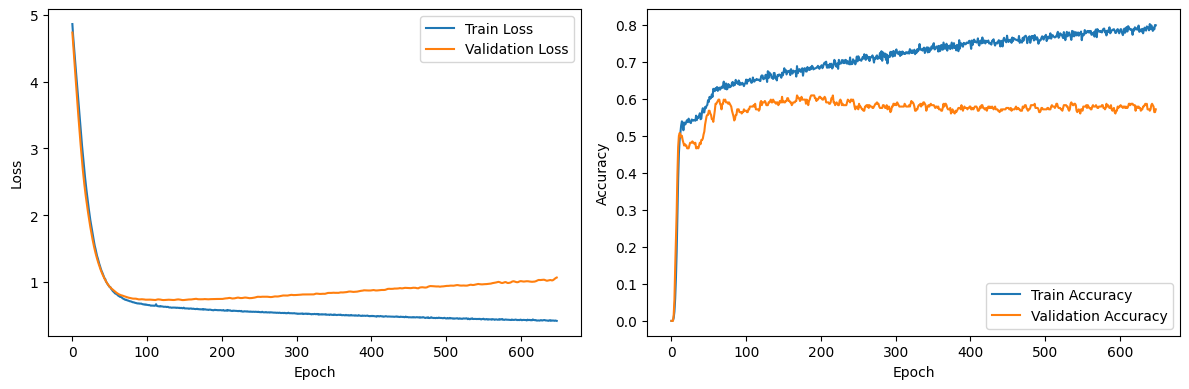


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1921, Val Loss: 3.1103, Train Acc: 0.3901, Val Acc: 0.4392
Epoch: 020, Train Loss: 2.1130, Val Loss: 2.0639, Train Acc: 0.5042, Val Acc: 0.5137
Epoch: 030, Train Loss: 1.4492, Val Loss: 1.4278, Train Acc: 0.5302, Val Acc: 0.5373
Epoch: 040, Train Loss: 1.0888, Val Loss: 1.1099, Train Acc: 0.5839, Val Acc: 0.5373
Epoch: 050, Train Loss: 0.9101, Val Loss: 0.9426, Train Acc: 0.5906, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.7947, Val Loss: 0.8464, Train Acc: 0.6166, Val Acc: 0.5333
Epoch: 070, Train Loss: 0.7442, Val Loss: 0.8036, Train Acc: 0.6242, Val Acc: 0.5569
Epoch: 080, Train Loss: 0.6949, Val Loss: 0.7720, Train Acc: 0.6418, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6700, Val Loss: 0.7547, Train Acc: 0.6451, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.6747, Val Loss: 0.7420, Train Acc: 0.6351, Val Acc: 0.5412
Epoch: 110, Train Loss: 0.6374, Val Loss: 0.7499, Tr

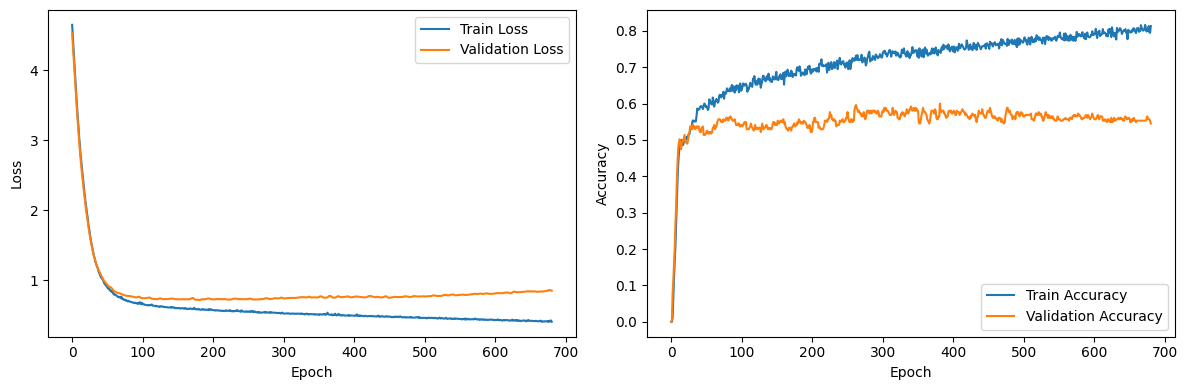


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4205, Val Loss: 3.2618, Train Acc: 0.3140, Val Acc: 0.3644
Epoch: 020, Train Loss: 2.4918, Val Loss: 2.4645, Train Acc: 0.4955, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.7764, Val Loss: 1.8028, Train Acc: 0.5127, Val Acc: 0.5127
Epoch: 040, Train Loss: 1.3131, Val Loss: 1.3577, Train Acc: 0.5254, Val Acc: 0.5127
Epoch: 050, Train Loss: 1.0579, Val Loss: 1.1159, Train Acc: 0.5463, Val Acc: 0.5212
Epoch: 060, Train Loss: 0.8945, Val Loss: 0.9538, Train Acc: 0.6034, Val Acc: 0.5297
Epoch: 070, Train Loss: 0.8179, Val Loss: 0.8678, Train Acc: 0.5998, Val Acc: 0.5424
Epoch: 080, Train Loss: 0.7542, Val Loss: 0.8122, Train Acc: 0.6334, Val Acc: 0.5297
Epoch: 090, Train Loss: 0.7099, Val Loss: 0.7805, Train Acc: 0.6452, Val Acc: 0.5254
Epoch: 100, Train Loss: 0.6895, Val Loss: 0.7699, Train Acc: 0.6234, Val Acc: 0.5254
Epoch: 110, Train Loss: 0.6629, Val Loss: 0.7590, Tr

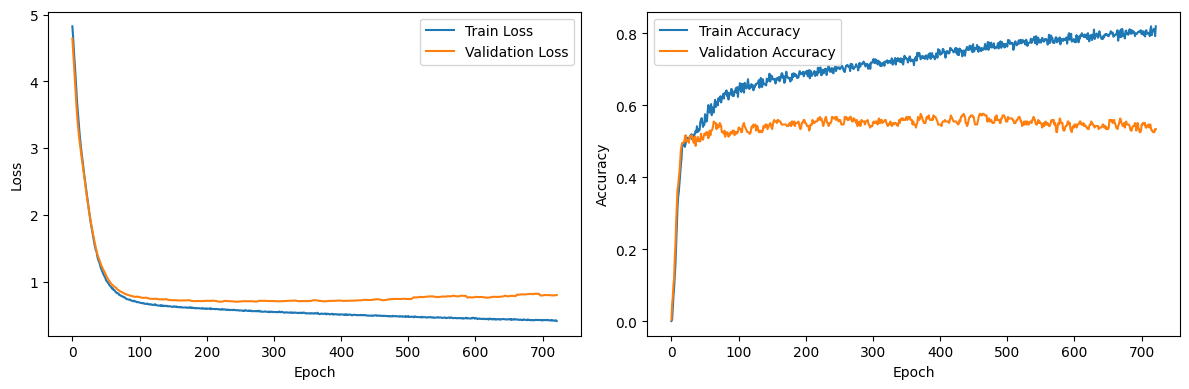


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0686, Val Loss: 2.8940, Train Acc: 0.4528, Val Acc: 0.4633
Epoch: 020, Train Loss: 2.1160, Val Loss: 2.0352, Train Acc: 0.5561, Val Acc: 0.5092
Epoch: 030, Train Loss: 1.5157, Val Loss: 1.4709, Train Acc: 0.5571, Val Acc: 0.4954
Epoch: 040, Train Loss: 1.1751, Val Loss: 1.1623, Train Acc: 0.5512, Val Acc: 0.5183
Epoch: 050, Train Loss: 0.9797, Val Loss: 0.9830, Train Acc: 0.5837, Val Acc: 0.5505
Epoch: 060, Train Loss: 0.8749, Val Loss: 0.8805, Train Acc: 0.5886, Val Acc: 0.5275
Epoch: 070, Train Loss: 0.7792, Val Loss: 0.8269, Train Acc: 0.6093, Val Acc: 0.5550
Epoch: 080, Train Loss: 0.7328, Val Loss: 0.7918, Train Acc: 0.6201, Val Acc: 0.5505
Epoch: 090, Train Loss: 0.7010, Val Loss: 0.7608, Train Acc: 0.6368, Val Acc: 0.5505
Epoch: 100, Train Loss: 0.6727, Val Loss: 0.7512, Train Acc: 0.6398, Val Acc: 0.5642
Epoch: 110, Train Loss: 0.6552, Val Loss: 0.7410, Tr

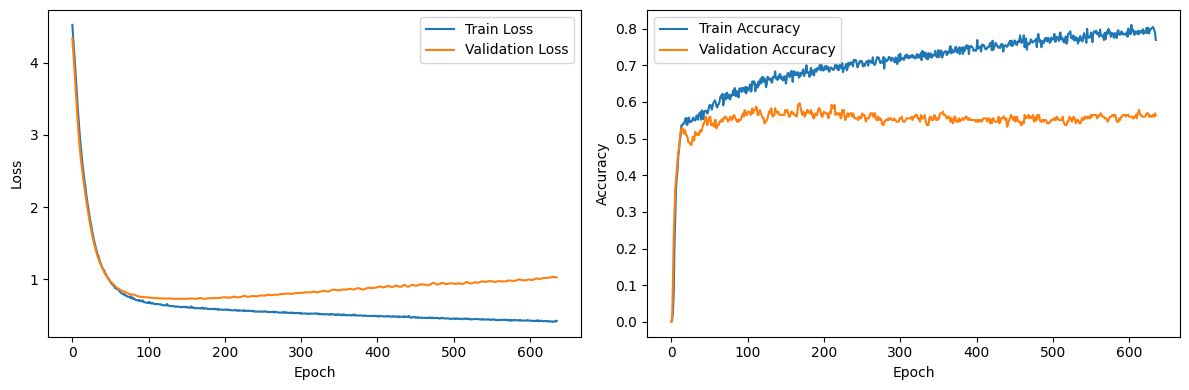


========== Run 2 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4661, Val Loss: 3.2440, Train Acc: 0.4182, Val Acc: 0.4662
Epoch: 020, Train Loss: 2.3544, Val Loss: 2.1537, Train Acc: 0.5028, Val Acc: 0.5113
Epoch: 030, Train Loss: 1.6636, Val Loss: 1.5464, Train Acc: 0.5085, Val Acc: 0.5263
Epoch: 040, Train Loss: 1.2538, Val Loss: 1.2063, Train Acc: 0.5149, Val Acc: 0.5188
Epoch: 050, Train Loss: 1.0116, Val Loss: 1.0246, Train Acc: 0.5383, Val Acc: 0.5150
Epoch: 060, Train Loss: 0.8712, Val Loss: 0.9428, Train Acc: 0.5874, Val Acc: 0.5075
Epoch: 070, Train Loss: 0.7849, Val Loss: 0.8785, Train Acc: 0.6100, Val Acc: 0.5075
Epoch: 080, Train Loss: 0.7305, Val Loss: 0.8395, Train Acc: 0.6052, Val Acc: 0.5301
Epoch: 090, Train Loss: 0.6973, Val Loss: 0.8229, Train Acc: 0.6390, Val Acc: 0.5226
Epoch: 100, Train Loss: 0.6740, Val Loss: 0.8044, Train Acc: 0.6422, Val Acc: 0.5602
Epoch: 110, Train Loss

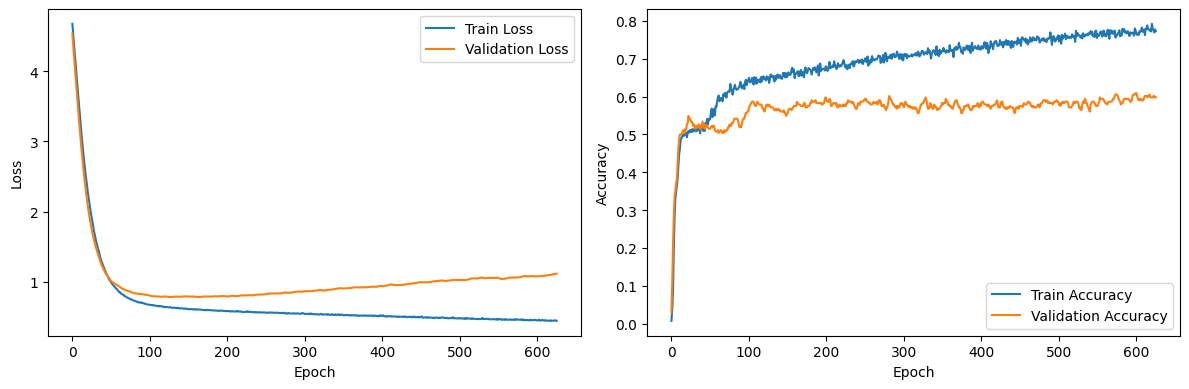


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5353, Val Loss: 3.4271, Train Acc: 0.4144, Val Acc: 0.4510
Epoch: 020, Train Loss: 2.2893, Val Loss: 2.2689, Train Acc: 0.5386, Val Acc: 0.5176
Epoch: 030, Train Loss: 1.5845, Val Loss: 1.5651, Train Acc: 0.5604, Val Acc: 0.5137
Epoch: 040, Train Loss: 1.1876, Val Loss: 1.2015, Train Acc: 0.5696, Val Acc: 0.5098
Epoch: 050, Train Loss: 0.9604, Val Loss: 0.9941, Train Acc: 0.5906, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.8410, Val Loss: 0.8859, Train Acc: 0.6040, Val Acc: 0.5333
Epoch: 070, Train Loss: 0.7670, Val Loss: 0.8214, Train Acc: 0.5998, Val Acc: 0.5569
Epoch: 080, Train Loss: 0.7256, Val Loss: 0.7928, Train Acc: 0.6091, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6886, Val Loss: 0.7697, Train Acc: 0.6267, Val Acc: 0.5608
Epoch: 100, Train Loss: 0.6620, Val Loss: 0.7511, Train Acc: 0.6485, Val Acc: 0.5725
Epoch: 110, Train Loss: 0.6471, Val Loss: 0.7425, Tr

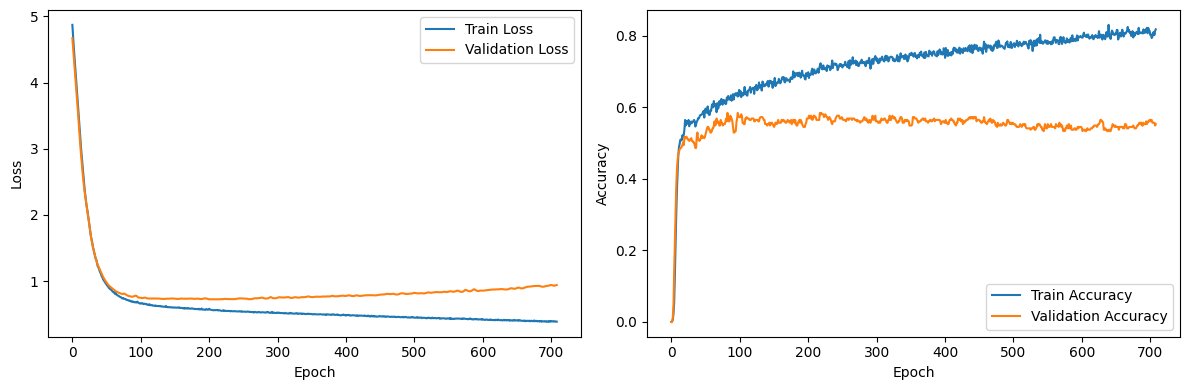


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6534, Val Loss: 3.5054, Train Acc: 0.3730, Val Acc: 0.3941
Epoch: 020, Train Loss: 2.3711, Val Loss: 2.3221, Train Acc: 0.4782, Val Acc: 0.4746
Epoch: 030, Train Loss: 1.6456, Val Loss: 1.6336, Train Acc: 0.4819, Val Acc: 0.4746
Epoch: 040, Train Loss: 1.2059, Val Loss: 1.2558, Train Acc: 0.4955, Val Acc: 0.4619
Epoch: 050, Train Loss: 0.9911, Val Loss: 1.0417, Train Acc: 0.5318, Val Acc: 0.5339
Epoch: 060, Train Loss: 0.8696, Val Loss: 0.8978, Train Acc: 0.5526, Val Acc: 0.5763
Epoch: 070, Train Loss: 0.7867, Val Loss: 0.8244, Train Acc: 0.5989, Val Acc: 0.5254
Epoch: 080, Train Loss: 0.7466, Val Loss: 0.7958, Train Acc: 0.5953, Val Acc: 0.5720
Epoch: 090, Train Loss: 0.7053, Val Loss: 0.7675, Train Acc: 0.6125, Val Acc: 0.5805
Epoch: 100, Train Loss: 0.6818, Val Loss: 0.7475, Train Acc: 0.6452, Val Acc: 0.5763
Epoch: 110, Train Loss: 0.6685, Val Loss: 0.7260, Tr

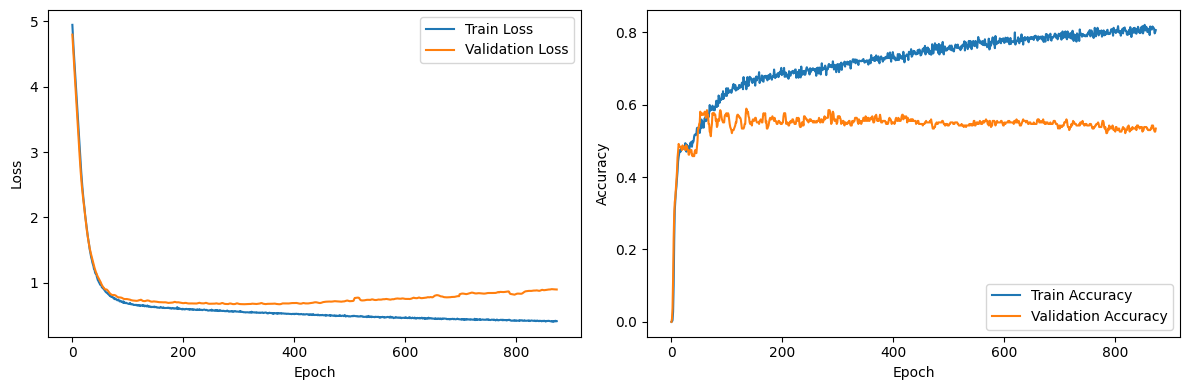


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4296, Val Loss: 3.2765, Train Acc: 0.4242, Val Acc: 0.4495
Epoch: 020, Train Loss: 2.2726, Val Loss: 2.1694, Train Acc: 0.5236, Val Acc: 0.4954
Epoch: 030, Train Loss: 1.6227, Val Loss: 1.5663, Train Acc: 0.5295, Val Acc: 0.4725
Epoch: 040, Train Loss: 1.2266, Val Loss: 1.2081, Train Acc: 0.5335, Val Acc: 0.4862
Epoch: 050, Train Loss: 1.0224, Val Loss: 1.0003, Train Acc: 0.5620, Val Acc: 0.4862
Epoch: 060, Train Loss: 0.8760, Val Loss: 0.8883, Train Acc: 0.5827, Val Acc: 0.5229
Epoch: 070, Train Loss: 0.7995, Val Loss: 0.8248, Train Acc: 0.5965, Val Acc: 0.5138
Epoch: 080, Train Loss: 0.7416, Val Loss: 0.7894, Train Acc: 0.6024, Val Acc: 0.5321
Epoch: 090, Train Loss: 0.7058, Val Loss: 0.7620, Train Acc: 0.6240, Val Acc: 0.5183
Epoch: 100, Train Loss: 0.6936, Val Loss: 0.7474, Train Acc: 0.6142, Val Acc: 0.5413
Epoch: 110, Train Loss: 0.6683, Val Loss: 0.7407, Tr

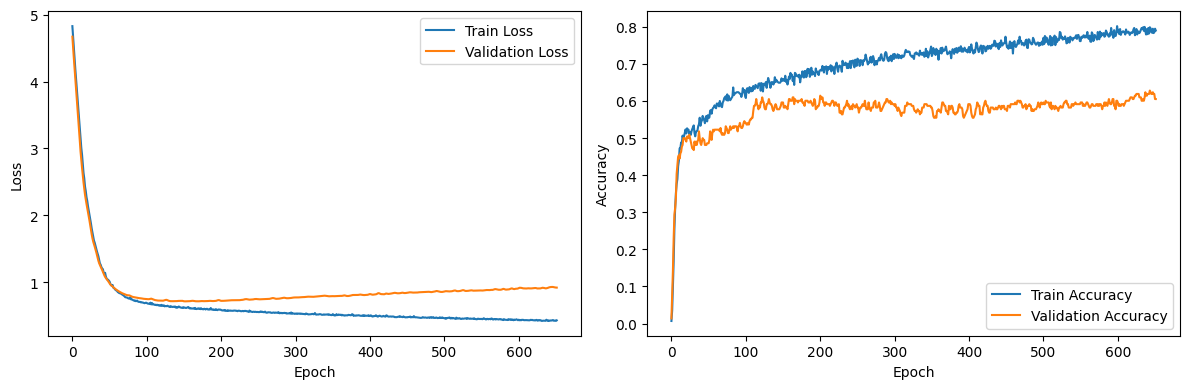


========== Run 3 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3685, Val Loss: 3.1643, Train Acc: 0.4730, Val Acc: 0.4774
Epoch: 020, Train Loss: 2.2988, Val Loss: 2.1047, Train Acc: 0.5077, Val Acc: 0.4774
Epoch: 030, Train Loss: 1.5967, Val Loss: 1.4598, Train Acc: 0.5238, Val Acc: 0.5526
Epoch: 040, Train Loss: 1.1886, Val Loss: 1.1606, Train Acc: 0.5391, Val Acc: 0.4850
Epoch: 050, Train Loss: 0.9636, Val Loss: 1.0038, Train Acc: 0.5729, Val Acc: 0.4737
Epoch: 060, Train Loss: 0.8403, Val Loss: 0.9096, Train Acc: 0.5987, Val Acc: 0.4812
Epoch: 070, Train Loss: 0.7630, Val Loss: 0.8494, Train Acc: 0.6156, Val Acc: 0.5038
Epoch: 080, Train Loss: 0.7191, Val Loss: 0.8187, Train Acc: 0.6197, Val Acc: 0.5226
Epoch: 090, Train Loss: 0.6934, Val Loss: 0.7968, Train Acc: 0.6326, Val Acc: 0.5489
Epoch: 100, Train Loss: 0.6629, Val Loss: 0.7785, Train Acc: 0.6430, Val Acc: 0.5564
Epoch: 110, Train Loss

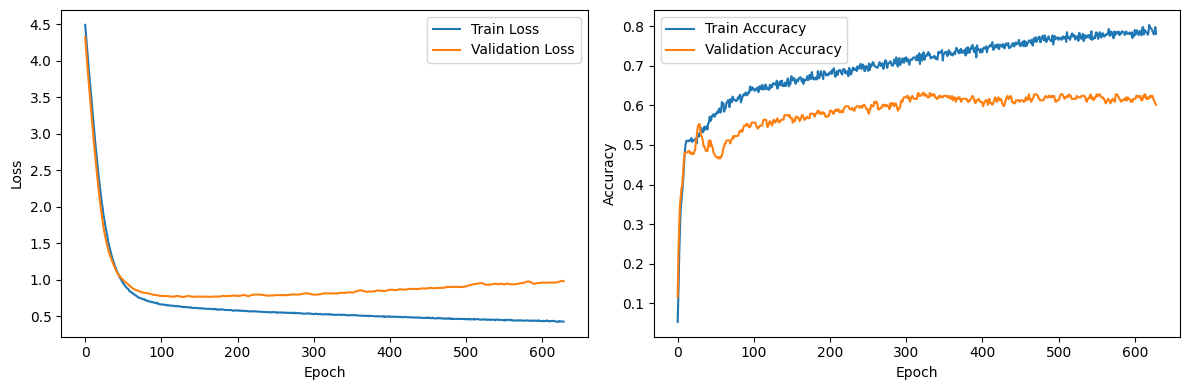


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2179, Val Loss: 3.1262, Train Acc: 0.4488, Val Acc: 0.4510
Epoch: 020, Train Loss: 2.1403, Val Loss: 2.0980, Train Acc: 0.5143, Val Acc: 0.4824
Epoch: 030, Train Loss: 1.4613, Val Loss: 1.4783, Train Acc: 0.5612, Val Acc: 0.4902
Epoch: 040, Train Loss: 1.1110, Val Loss: 1.1629, Train Acc: 0.5948, Val Acc: 0.4784
Epoch: 050, Train Loss: 0.9547, Val Loss: 0.9903, Train Acc: 0.5940, Val Acc: 0.4980
Epoch: 060, Train Loss: 0.8176, Val Loss: 0.8891, Train Acc: 0.6242, Val Acc: 0.4980
Epoch: 070, Train Loss: 0.7429, Val Loss: 0.8311, Train Acc: 0.6342, Val Acc: 0.4863
Epoch: 080, Train Loss: 0.7086, Val Loss: 0.7994, Train Acc: 0.6359, Val Acc: 0.5255
Epoch: 090, Train Loss: 0.6824, Val Loss: 0.7634, Train Acc: 0.6628, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6471, Val Loss: 0.7517, Train Acc: 0.6569, Val Acc: 0.5255
Epoch: 110, Train Loss: 0.6281, Val Loss: 0.7456, Tr

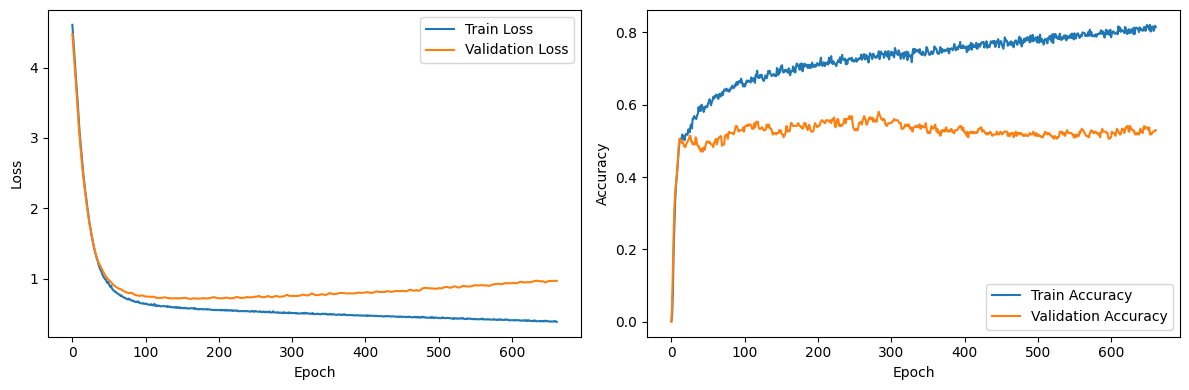


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3962, Val Loss: 3.3270, Train Acc: 0.4918, Val Acc: 0.4958
Epoch: 020, Train Loss: 2.1410, Val Loss: 2.1318, Train Acc: 0.5045, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.4581, Val Loss: 1.4895, Train Acc: 0.5245, Val Acc: 0.5042
Epoch: 040, Train Loss: 1.0956, Val Loss: 1.1214, Train Acc: 0.5263, Val Acc: 0.5212
Epoch: 050, Train Loss: 0.9244, Val Loss: 0.9638, Train Acc: 0.5417, Val Acc: 0.5169
Epoch: 060, Train Loss: 0.8373, Val Loss: 0.8618, Train Acc: 0.5681, Val Acc: 0.5169
Epoch: 070, Train Loss: 0.7571, Val Loss: 0.8060, Train Acc: 0.6071, Val Acc: 0.5254
Epoch: 080, Train Loss: 0.7154, Val Loss: 0.7727, Train Acc: 0.6216, Val Acc: 0.5508
Epoch: 090, Train Loss: 0.6929, Val Loss: 0.7535, Train Acc: 0.6334, Val Acc: 0.5551
Epoch: 100, Train Loss: 0.6673, Val Loss: 0.7353, Train Acc: 0.6506, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6515, Val Loss: 0.7168, Tr

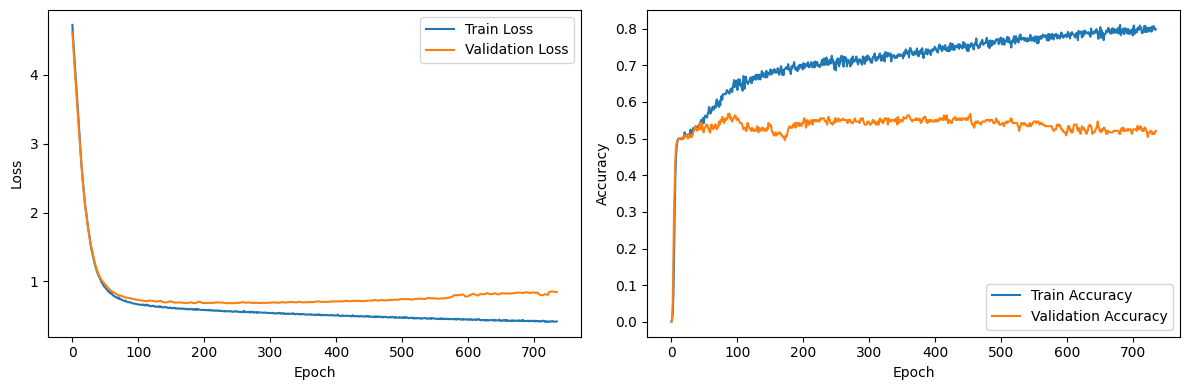


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2400, Val Loss: 3.0437, Train Acc: 0.3415, Val Acc: 0.3532
Epoch: 020, Train Loss: 2.2237, Val Loss: 2.1194, Train Acc: 0.5551, Val Acc: 0.4358
Epoch: 030, Train Loss: 1.5331, Val Loss: 1.5050, Train Acc: 0.5630, Val Acc: 0.4450
Epoch: 040, Train Loss: 1.1871, Val Loss: 1.1729, Train Acc: 0.5679, Val Acc: 0.4633
Epoch: 050, Train Loss: 0.9672, Val Loss: 0.9780, Train Acc: 0.6014, Val Acc: 0.5046
Epoch: 060, Train Loss: 0.8464, Val Loss: 0.8872, Train Acc: 0.6093, Val Acc: 0.5505
Epoch: 070, Train Loss: 0.7796, Val Loss: 0.8362, Train Acc: 0.6053, Val Acc: 0.5367
Epoch: 080, Train Loss: 0.7217, Val Loss: 0.7944, Train Acc: 0.6280, Val Acc: 0.5321
Epoch: 090, Train Loss: 0.6964, Val Loss: 0.7785, Train Acc: 0.6329, Val Acc: 0.5229
Epoch: 100, Train Loss: 0.6704, Val Loss: 0.7695, Train Acc: 0.6437, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6558, Val Loss: 0.7714, Tr

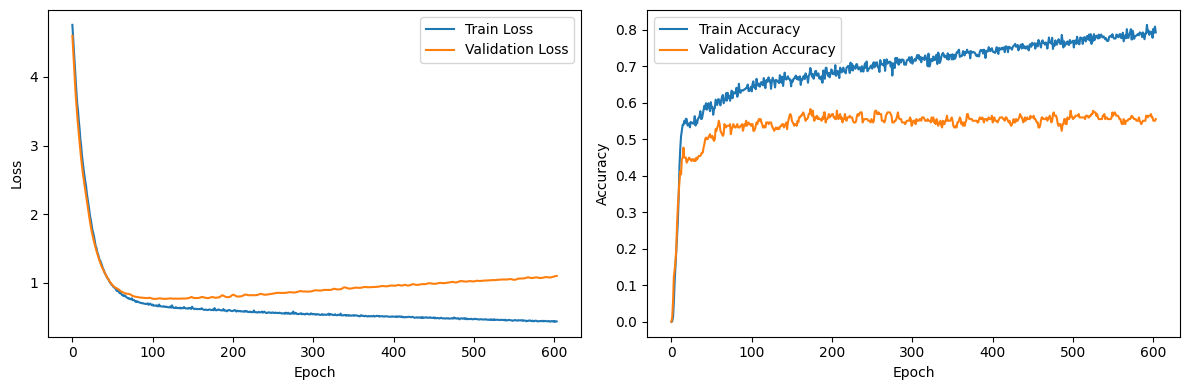


========== Run 4 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3530, Val Loss: 3.1404, Train Acc: 0.4263, Val Acc: 0.5075
Epoch: 020, Train Loss: 2.2825, Val Loss: 2.1111, Train Acc: 0.5334, Val Acc: 0.5489
Epoch: 030, Train Loss: 1.6123, Val Loss: 1.5027, Train Acc: 0.5520, Val Acc: 0.6090
Epoch: 040, Train Loss: 1.2032, Val Loss: 1.1600, Train Acc: 0.5624, Val Acc: 0.5827
Epoch: 050, Train Loss: 0.9817, Val Loss: 0.9710, Train Acc: 0.5721, Val Acc: 0.5602
Epoch: 060, Train Loss: 0.8507, Val Loss: 0.8691, Train Acc: 0.5915, Val Acc: 0.5602
Epoch: 070, Train Loss: 0.7726, Val Loss: 0.8173, Train Acc: 0.6108, Val Acc: 0.5789
Epoch: 080, Train Loss: 0.7219, Val Loss: 0.7808, Train Acc: 0.6358, Val Acc: 0.5789
Epoch: 090, Train Loss: 0.6903, Val Loss: 0.7625, Train Acc: 0.6422, Val Acc: 0.6090
Epoch: 100, Train Loss: 0.6696, Val Loss: 0.7521, Train Acc: 0.6479, Val Acc: 0.6165
Epoch: 110, Train Loss

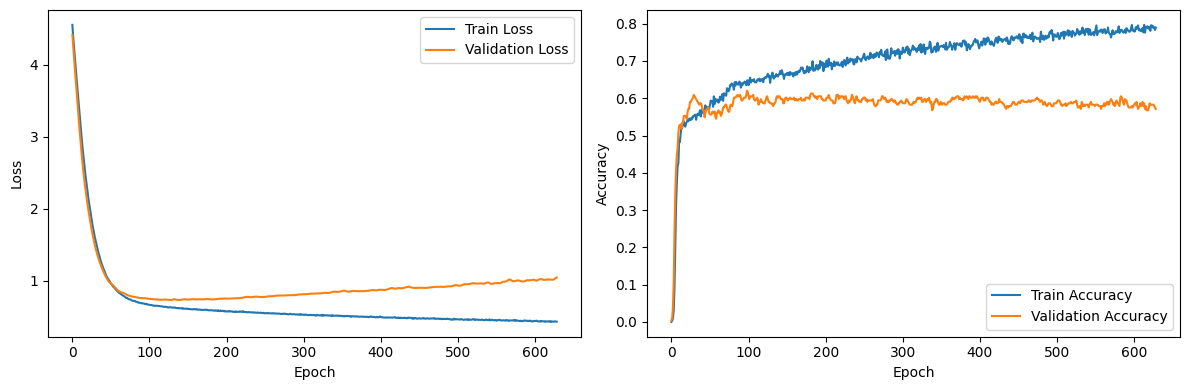


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1704, Val Loss: 3.0953, Train Acc: 0.4161, Val Acc: 0.4039
Epoch: 020, Train Loss: 2.1940, Val Loss: 2.1784, Train Acc: 0.5453, Val Acc: 0.5137
Epoch: 030, Train Loss: 1.5489, Val Loss: 1.5736, Train Acc: 0.5940, Val Acc: 0.5098
Epoch: 040, Train Loss: 1.1883, Val Loss: 1.2328, Train Acc: 0.6074, Val Acc: 0.5373
Epoch: 050, Train Loss: 0.9827, Val Loss: 1.0383, Train Acc: 0.6158, Val Acc: 0.5294
Epoch: 060, Train Loss: 0.8567, Val Loss: 0.9238, Train Acc: 0.6200, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.7697, Val Loss: 0.8370, Train Acc: 0.6451, Val Acc: 0.5412
Epoch: 080, Train Loss: 0.7161, Val Loss: 0.7933, Train Acc: 0.6518, Val Acc: 0.5725
Epoch: 090, Train Loss: 0.6778, Val Loss: 0.7707, Train Acc: 0.6661, Val Acc: 0.5490
Epoch: 100, Train Loss: 0.6524, Val Loss: 0.7471, Train Acc: 0.6695, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.6406, Val Loss: 0.7420, Tr

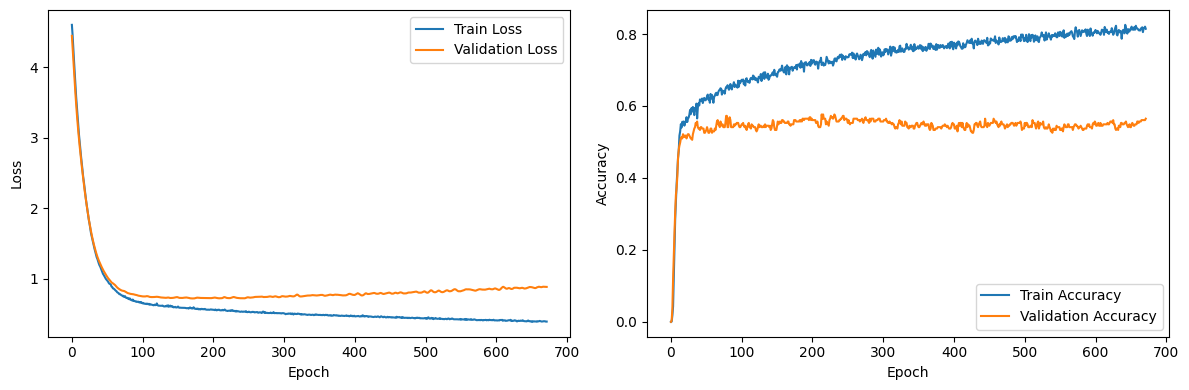


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3700, Val Loss: 3.2509, Train Acc: 0.4828, Val Acc: 0.4873
Epoch: 020, Train Loss: 2.2678, Val Loss: 2.2667, Train Acc: 0.5236, Val Acc: 0.4915
Epoch: 030, Train Loss: 1.5492, Val Loss: 1.5820, Train Acc: 0.5399, Val Acc: 0.4958
Epoch: 040, Train Loss: 1.1492, Val Loss: 1.1869, Train Acc: 0.5653, Val Acc: 0.5127
Epoch: 050, Train Loss: 0.9508, Val Loss: 1.0018, Train Acc: 0.5599, Val Acc: 0.5424
Epoch: 060, Train Loss: 0.8330, Val Loss: 0.9013, Train Acc: 0.5871, Val Acc: 0.5466
Epoch: 070, Train Loss: 0.7630, Val Loss: 0.8371, Train Acc: 0.6225, Val Acc: 0.5466
Epoch: 080, Train Loss: 0.7313, Val Loss: 0.7989, Train Acc: 0.6152, Val Acc: 0.5381
Epoch: 090, Train Loss: 0.6966, Val Loss: 0.7797, Train Acc: 0.6552, Val Acc: 0.5678
Epoch: 100, Train Loss: 0.6668, Val Loss: 0.7584, Train Acc: 0.6670, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6535, Val Loss: 0.7505, Tr

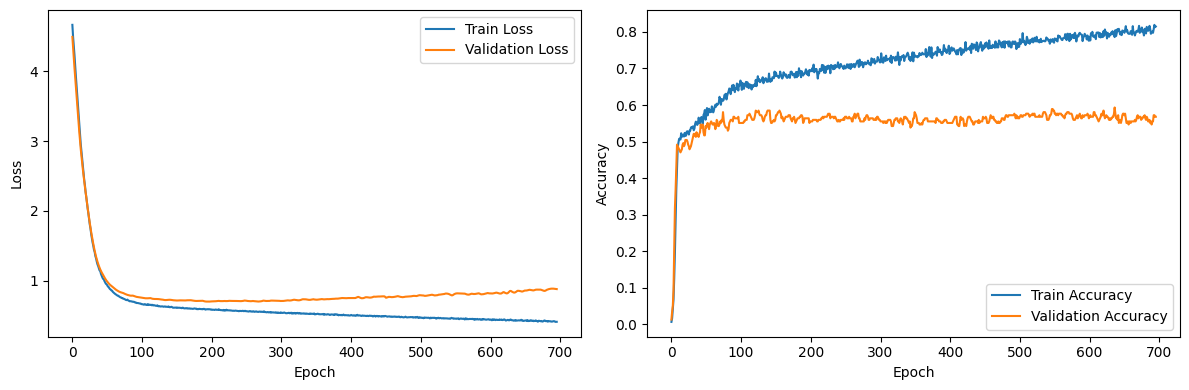


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0769, Val Loss: 2.9094, Train Acc: 0.4793, Val Acc: 0.4495
Epoch: 020, Train Loss: 2.1747, Val Loss: 2.0711, Train Acc: 0.5502, Val Acc: 0.5138
Epoch: 030, Train Loss: 1.6037, Val Loss: 1.5443, Train Acc: 0.5856, Val Acc: 0.5138
Epoch: 040, Train Loss: 1.2433, Val Loss: 1.2096, Train Acc: 0.5915, Val Acc: 0.5321
Epoch: 050, Train Loss: 1.0205, Val Loss: 1.0351, Train Acc: 0.6122, Val Acc: 0.5321
Epoch: 060, Train Loss: 0.8952, Val Loss: 0.9165, Train Acc: 0.6250, Val Acc: 0.5275
Epoch: 070, Train Loss: 0.8029, Val Loss: 0.8545, Train Acc: 0.6024, Val Acc: 0.5459
Epoch: 080, Train Loss: 0.7401, Val Loss: 0.8140, Train Acc: 0.6388, Val Acc: 0.5367
Epoch: 090, Train Loss: 0.7052, Val Loss: 0.7827, Train Acc: 0.6260, Val Acc: 0.5183
Epoch: 100, Train Loss: 0.6799, Val Loss: 0.7653, Train Acc: 0.6378, Val Acc: 0.5183
Epoch: 110, Train Loss: 0.6559, Val Loss: 0.7721, Tr

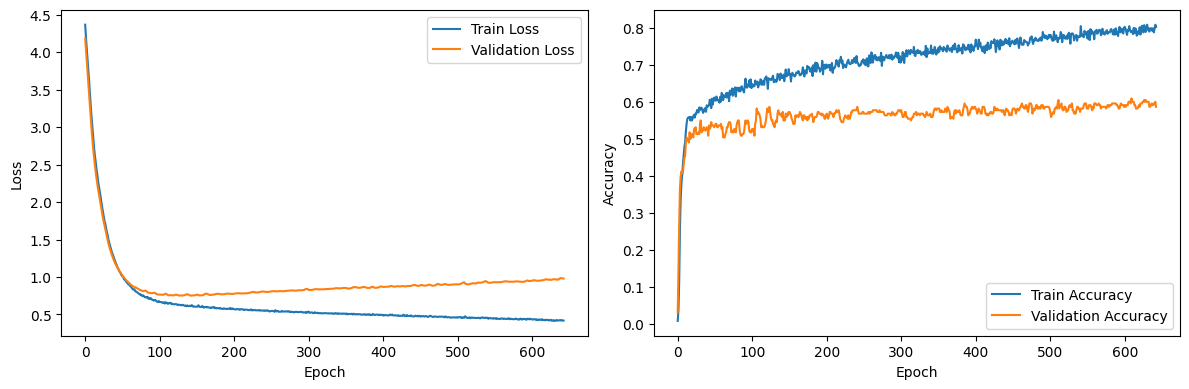


========== Run 5 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2555, Val Loss: 2.9851, Train Acc: 0.4295, Val Acc: 0.4098
Epoch: 020, Train Loss: 2.2665, Val Loss: 2.0748, Train Acc: 0.5520, Val Acc: 0.4887
Epoch: 030, Train Loss: 1.6051, Val Loss: 1.4842, Train Acc: 0.5689, Val Acc: 0.5113
Epoch: 040, Train Loss: 1.2115, Val Loss: 1.1517, Train Acc: 0.5770, Val Acc: 0.5376
Epoch: 050, Train Loss: 0.9773, Val Loss: 0.9612, Train Acc: 0.5915, Val Acc: 0.5789
Epoch: 060, Train Loss: 0.8496, Val Loss: 0.8614, Train Acc: 0.6124, Val Acc: 0.5827
Epoch: 070, Train Loss: 0.7763, Val Loss: 0.8040, Train Acc: 0.6205, Val Acc: 0.6128
Epoch: 080, Train Loss: 0.7320, Val Loss: 0.7844, Train Acc: 0.6277, Val Acc: 0.5827
Epoch: 090, Train Loss: 0.6937, Val Loss: 0.7570, Train Acc: 0.6430, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6728, Val Loss: 0.7420, Train Acc: 0.6398, Val Acc: 0.5902
Epoch: 110, Train Loss

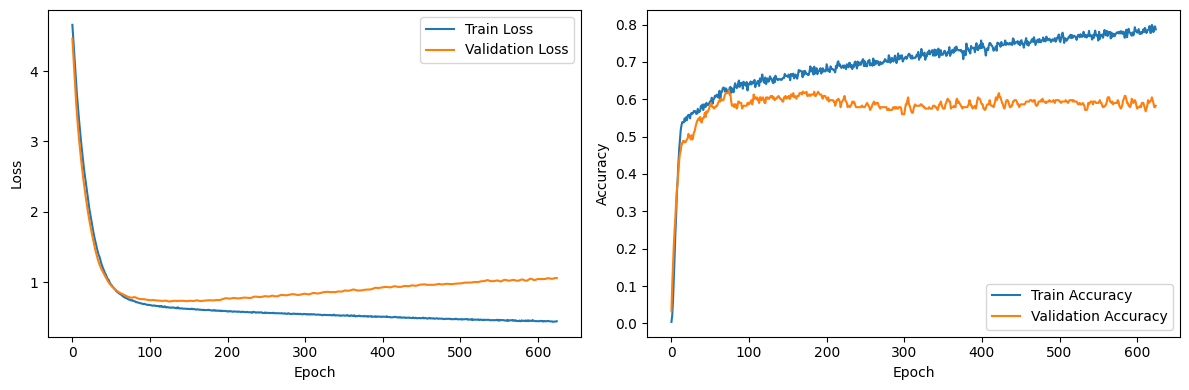


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4019, Val Loss: 3.3061, Train Acc: 0.4757, Val Acc: 0.4980
Epoch: 020, Train Loss: 2.1684, Val Loss: 2.1338, Train Acc: 0.5294, Val Acc: 0.5020
Epoch: 030, Train Loss: 1.5169, Val Loss: 1.5357, Train Acc: 0.5545, Val Acc: 0.4510
Epoch: 040, Train Loss: 1.1648, Val Loss: 1.2263, Train Acc: 0.5688, Val Acc: 0.4667
Epoch: 050, Train Loss: 0.9789, Val Loss: 1.0312, Train Acc: 0.5713, Val Acc: 0.4824
Epoch: 060, Train Loss: 0.8506, Val Loss: 0.9217, Train Acc: 0.5931, Val Acc: 0.5098
Epoch: 070, Train Loss: 0.7736, Val Loss: 0.8496, Train Acc: 0.6032, Val Acc: 0.5137
Epoch: 080, Train Loss: 0.7164, Val Loss: 0.8055, Train Acc: 0.6225, Val Acc: 0.5176
Epoch: 090, Train Loss: 0.6823, Val Loss: 0.7781, Train Acc: 0.6376, Val Acc: 0.5373
Epoch: 100, Train Loss: 0.6784, Val Loss: 0.7504, Train Acc: 0.6451, Val Acc: 0.5412
Epoch: 110, Train Loss: 0.6456, Val Loss: 0.7294, Tr

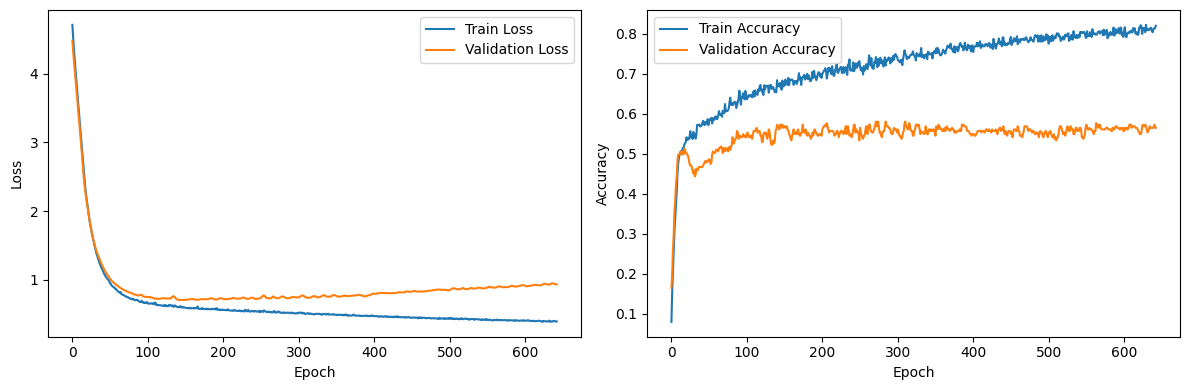


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1262, Val Loss: 3.0247, Train Acc: 0.4165, Val Acc: 0.4025
Epoch: 020, Train Loss: 2.1860, Val Loss: 2.2233, Train Acc: 0.5617, Val Acc: 0.4703
Epoch: 030, Train Loss: 1.5335, Val Loss: 1.6163, Train Acc: 0.5771, Val Acc: 0.4788
Epoch: 040, Train Loss: 1.1486, Val Loss: 1.2423, Train Acc: 0.5962, Val Acc: 0.4831
Epoch: 050, Train Loss: 0.9514, Val Loss: 1.0196, Train Acc: 0.6089, Val Acc: 0.5381
Epoch: 060, Train Loss: 0.8275, Val Loss: 0.8957, Train Acc: 0.6207, Val Acc: 0.5424
Epoch: 070, Train Loss: 0.7504, Val Loss: 0.8322, Train Acc: 0.6361, Val Acc: 0.5720
Epoch: 080, Train Loss: 0.7292, Val Loss: 0.7801, Train Acc: 0.6325, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.6845, Val Loss: 0.7558, Train Acc: 0.6561, Val Acc: 0.5636
Epoch: 100, Train Loss: 0.6631, Val Loss: 0.7344, Train Acc: 0.6697, Val Acc: 0.5678
Epoch: 110, Train Loss: 0.6504, Val Loss: 0.7358, Tr

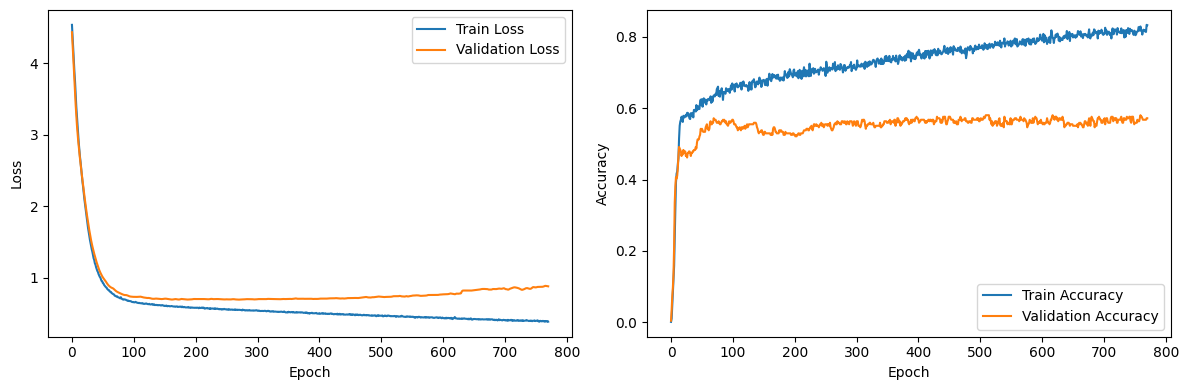


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8938, Val Loss: 2.7380, Train Acc: 0.4331, Val Acc: 0.3853
Epoch: 020, Train Loss: 2.0814, Val Loss: 1.9957, Train Acc: 0.5679, Val Acc: 0.4771
Epoch: 030, Train Loss: 1.5097, Val Loss: 1.4701, Train Acc: 0.5955, Val Acc: 0.5138
Epoch: 040, Train Loss: 1.1897, Val Loss: 1.1665, Train Acc: 0.5787, Val Acc: 0.5046
Epoch: 050, Train Loss: 1.0006, Val Loss: 1.0186, Train Acc: 0.6063, Val Acc: 0.5000
Epoch: 060, Train Loss: 0.8755, Val Loss: 0.9149, Train Acc: 0.6073, Val Acc: 0.5275
Epoch: 070, Train Loss: 0.7859, Val Loss: 0.8584, Train Acc: 0.6270, Val Acc: 0.5321
Epoch: 080, Train Loss: 0.7397, Val Loss: 0.8269, Train Acc: 0.6280, Val Acc: 0.5459
Epoch: 090, Train Loss: 0.6973, Val Loss: 0.7974, Train Acc: 0.6447, Val Acc: 0.5505
Epoch: 100, Train Loss: 0.6699, Val Loss: 0.7834, Train Acc: 0.6467, Val Acc: 0.5413
Epoch: 110, Train Loss: 0.6526, Val Loss: 0.7741, Tr

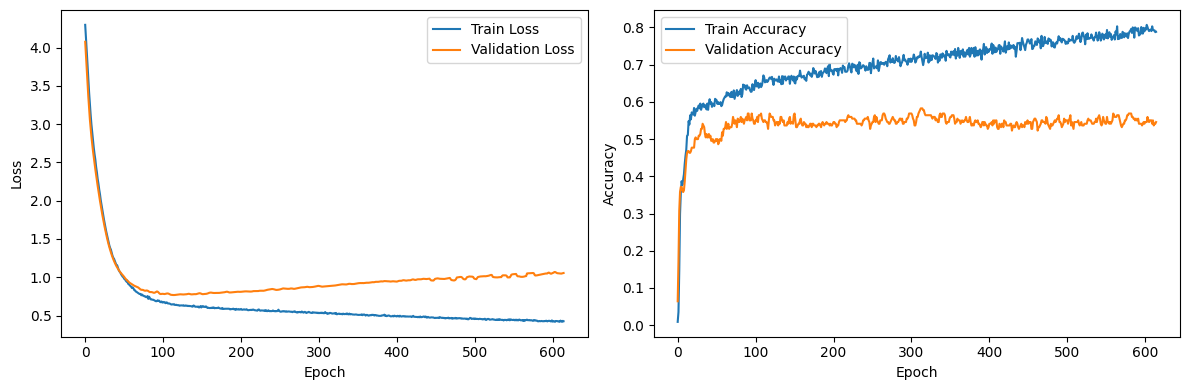


========== Run 6 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3474, Val Loss: 3.1176, Train Acc: 0.4512, Val Acc: 0.5000
Epoch: 020, Train Loss: 2.1951, Val Loss: 2.0165, Train Acc: 0.5383, Val Acc: 0.4962
Epoch: 030, Train Loss: 1.5084, Val Loss: 1.4031, Train Acc: 0.5407, Val Acc: 0.5188
Epoch: 040, Train Loss: 1.1348, Val Loss: 1.0785, Train Acc: 0.5576, Val Acc: 0.5752
Epoch: 050, Train Loss: 0.9353, Val Loss: 0.9234, Train Acc: 0.5770, Val Acc: 0.5789
Epoch: 060, Train Loss: 0.8162, Val Loss: 0.8356, Train Acc: 0.5931, Val Acc: 0.6053
Epoch: 070, Train Loss: 0.7528, Val Loss: 0.7862, Train Acc: 0.6076, Val Acc: 0.6203
Epoch: 080, Train Loss: 0.7167, Val Loss: 0.7635, Train Acc: 0.6269, Val Acc: 0.6053
Epoch: 090, Train Loss: 0.6883, Val Loss: 0.7361, Train Acc: 0.6390, Val Acc: 0.6165
Epoch: 100, Train Loss: 0.6630, Val Loss: 0.7270, Train Acc: 0.6390, Val Acc: 0.6241
Epoch: 110, Train Loss

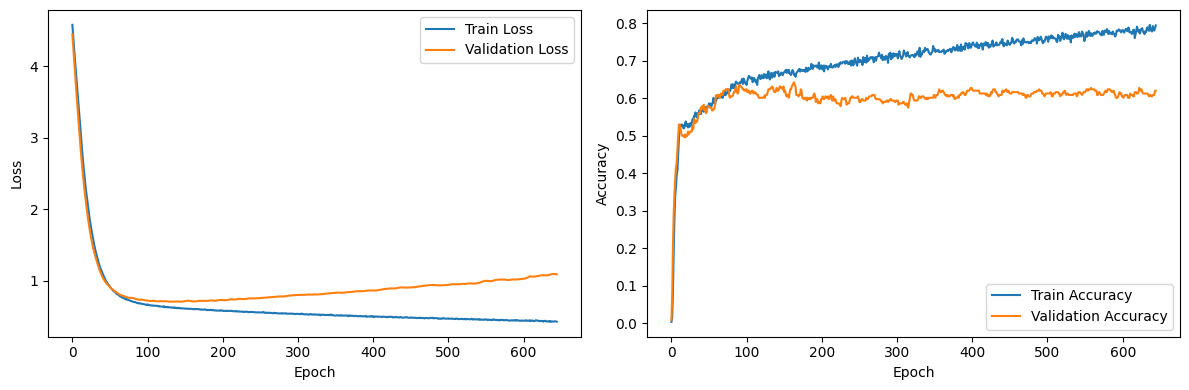


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5313, Val Loss: 3.4505, Train Acc: 0.4362, Val Acc: 0.4157
Epoch: 020, Train Loss: 2.3223, Val Loss: 2.2707, Train Acc: 0.5596, Val Acc: 0.5216
Epoch: 030, Train Loss: 1.5843, Val Loss: 1.5627, Train Acc: 0.5453, Val Acc: 0.5176
Epoch: 040, Train Loss: 1.1762, Val Loss: 1.1896, Train Acc: 0.5940, Val Acc: 0.5020
Epoch: 050, Train Loss: 0.9614, Val Loss: 1.0017, Train Acc: 0.6107, Val Acc: 0.5137
Epoch: 060, Train Loss: 0.8467, Val Loss: 0.9037, Train Acc: 0.6023, Val Acc: 0.5176
Epoch: 070, Train Loss: 0.7714, Val Loss: 0.8335, Train Acc: 0.6107, Val Acc: 0.5294
Epoch: 080, Train Loss: 0.7158, Val Loss: 0.7900, Train Acc: 0.6544, Val Acc: 0.5686
Epoch: 090, Train Loss: 0.6824, Val Loss: 0.7744, Train Acc: 0.6502, Val Acc: 0.5569
Epoch: 100, Train Loss: 0.6525, Val Loss: 0.7555, Train Acc: 0.6443, Val Acc: 0.5647
Epoch: 110, Train Loss: 0.6313, Val Loss: 0.7461, Tr

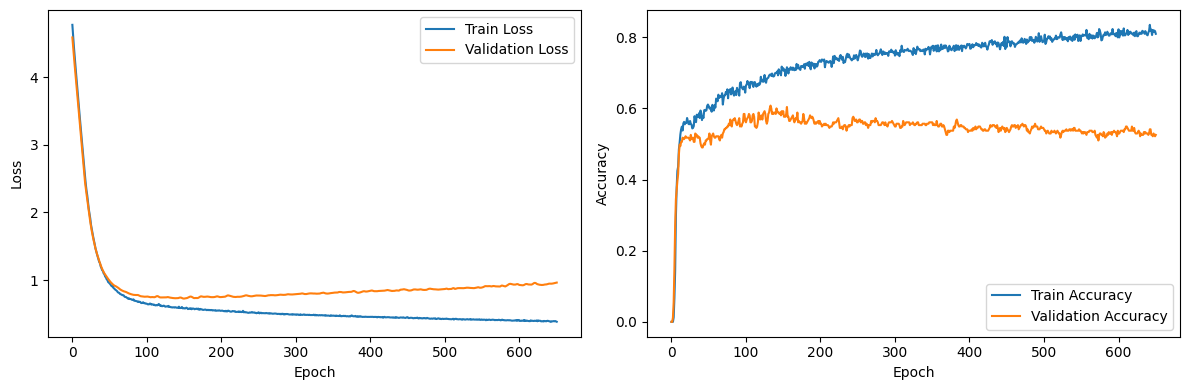


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6073, Val Loss: 3.5168, Train Acc: 0.3966, Val Acc: 0.4068
Epoch: 020, Train Loss: 2.3050, Val Loss: 2.2407, Train Acc: 0.5082, Val Acc: 0.5466
Epoch: 030, Train Loss: 1.5998, Val Loss: 1.6092, Train Acc: 0.5000, Val Acc: 0.5297
Epoch: 040, Train Loss: 1.1618, Val Loss: 1.2290, Train Acc: 0.5535, Val Acc: 0.5085
Epoch: 050, Train Loss: 0.9603, Val Loss: 1.0056, Train Acc: 0.5817, Val Acc: 0.5085
Epoch: 060, Train Loss: 0.8396, Val Loss: 0.9022, Train Acc: 0.5962, Val Acc: 0.4703
Epoch: 070, Train Loss: 0.7798, Val Loss: 0.8330, Train Acc: 0.6044, Val Acc: 0.5085
Epoch: 080, Train Loss: 0.7271, Val Loss: 0.7795, Train Acc: 0.6243, Val Acc: 0.5466
Epoch: 090, Train Loss: 0.6978, Val Loss: 0.7570, Train Acc: 0.6497, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6771, Val Loss: 0.7434, Train Acc: 0.6379, Val Acc: 0.5636
Epoch: 110, Train Loss: 0.6767, Val Loss: 0.7278, Tr

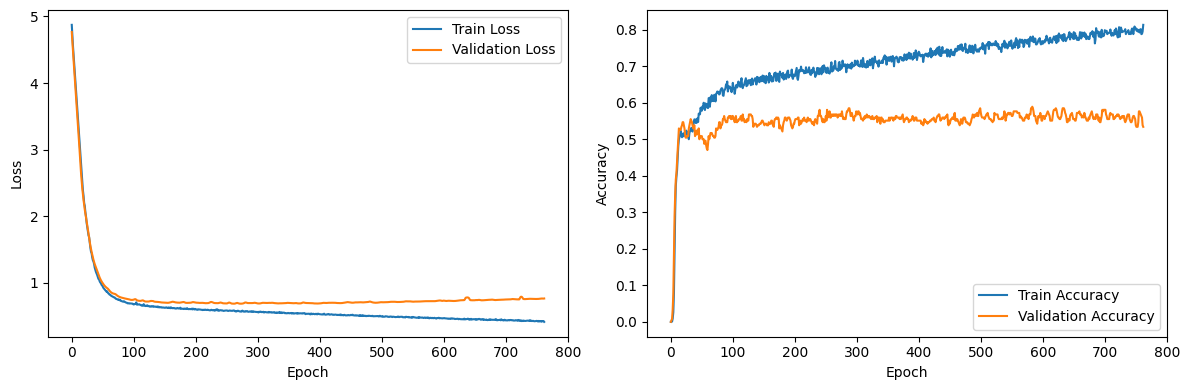


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6724, Val Loss: 3.4362, Train Acc: 0.2136, Val Acc: 0.2569
Epoch: 020, Train Loss: 2.4510, Val Loss: 2.2997, Train Acc: 0.4961, Val Acc: 0.5138
Epoch: 030, Train Loss: 1.7129, Val Loss: 1.6103, Train Acc: 0.5098, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.2595, Val Loss: 1.2193, Train Acc: 0.5404, Val Acc: 0.5138
Epoch: 050, Train Loss: 1.0176, Val Loss: 1.0023, Train Acc: 0.5817, Val Acc: 0.5092
Epoch: 060, Train Loss: 0.8831, Val Loss: 0.8898, Train Acc: 0.5856, Val Acc: 0.5183
Epoch: 070, Train Loss: 0.8009, Val Loss: 0.8266, Train Acc: 0.6142, Val Acc: 0.4908
Epoch: 080, Train Loss: 0.7384, Val Loss: 0.7895, Train Acc: 0.6250, Val Acc: 0.5046
Epoch: 090, Train Loss: 0.7065, Val Loss: 0.7764, Train Acc: 0.6152, Val Acc: 0.5367
Epoch: 100, Train Loss: 0.6856, Val Loss: 0.7750, Train Acc: 0.6230, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6661, Val Loss: 0.7455, Tr

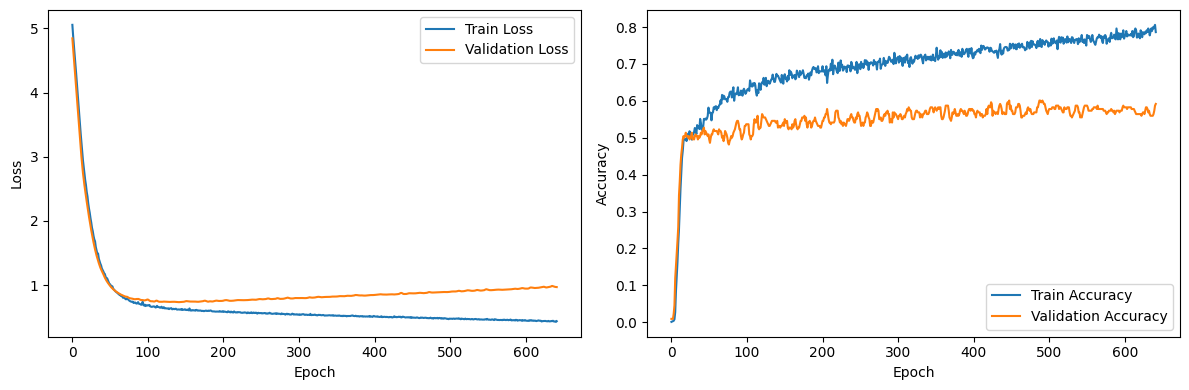


========== Run 7 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1230, Val Loss: 2.8568, Train Acc: 0.4907, Val Acc: 0.5489
Epoch: 020, Train Loss: 2.1026, Val Loss: 1.8887, Train Acc: 0.5536, Val Acc: 0.5752
Epoch: 030, Train Loss: 1.4876, Val Loss: 1.3653, Train Acc: 0.5753, Val Acc: 0.6128
Epoch: 040, Train Loss: 1.1437, Val Loss: 1.1048, Train Acc: 0.5955, Val Acc: 0.5902
Epoch: 050, Train Loss: 0.9449, Val Loss: 0.9364, Train Acc: 0.5963, Val Acc: 0.6165
Epoch: 060, Train Loss: 0.8224, Val Loss: 0.8473, Train Acc: 0.6229, Val Acc: 0.6128
Epoch: 070, Train Loss: 0.7493, Val Loss: 0.7991, Train Acc: 0.6334, Val Acc: 0.5940
Epoch: 080, Train Loss: 0.7063, Val Loss: 0.7657, Train Acc: 0.6317, Val Acc: 0.5827
Epoch: 090, Train Loss: 0.6746, Val Loss: 0.7532, Train Acc: 0.6430, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6583, Val Loss: 0.7435, Train Acc: 0.6422, Val Acc: 0.5752
Epoch: 110, Train Loss

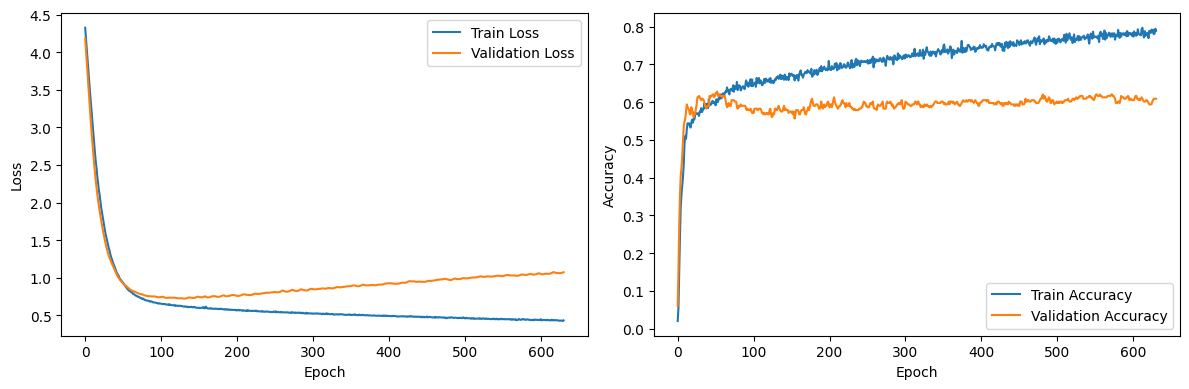


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2784, Val Loss: 3.1728, Train Acc: 0.4480, Val Acc: 0.5255
Epoch: 020, Train Loss: 2.1204, Val Loss: 2.0370, Train Acc: 0.5319, Val Acc: 0.4941
Epoch: 030, Train Loss: 1.4417, Val Loss: 1.4008, Train Acc: 0.5478, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.0815, Val Loss: 1.0974, Train Acc: 0.5831, Val Acc: 0.5098
Epoch: 050, Train Loss: 0.9111, Val Loss: 0.9396, Train Acc: 0.6049, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.8025, Val Loss: 0.8512, Train Acc: 0.6133, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.7462, Val Loss: 0.8056, Train Acc: 0.6300, Val Acc: 0.5451
Epoch: 080, Train Loss: 0.6962, Val Loss: 0.7647, Train Acc: 0.6326, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6681, Val Loss: 0.7414, Train Acc: 0.6518, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.6494, Val Loss: 0.7358, Train Acc: 0.6502, Val Acc: 0.5490
Epoch: 110, Train Loss: 0.6255, Val Loss: 0.7282, Tr

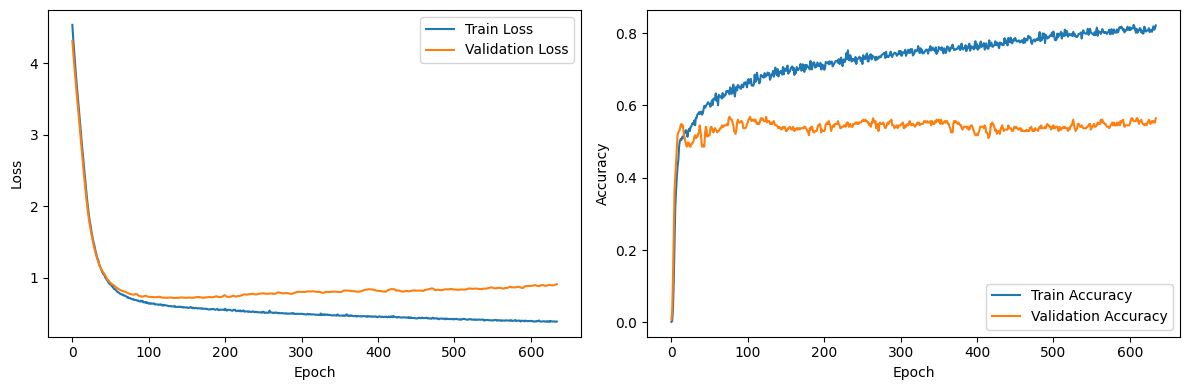


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3338, Val Loss: 3.1921, Train Acc: 0.3040, Val Acc: 0.3602
Epoch: 020, Train Loss: 2.4276, Val Loss: 2.4076, Train Acc: 0.5009, Val Acc: 0.5212
Epoch: 030, Train Loss: 1.7324, Val Loss: 1.7500, Train Acc: 0.5136, Val Acc: 0.4958
Epoch: 040, Train Loss: 1.2781, Val Loss: 1.2996, Train Acc: 0.5245, Val Acc: 0.5297
Epoch: 050, Train Loss: 1.0276, Val Loss: 1.0753, Train Acc: 0.5644, Val Acc: 0.5381
Epoch: 060, Train Loss: 0.8834, Val Loss: 0.9460, Train Acc: 0.6089, Val Acc: 0.5424
Epoch: 070, Train Loss: 0.8009, Val Loss: 0.8586, Train Acc: 0.6243, Val Acc: 0.5254
Epoch: 080, Train Loss: 0.7420, Val Loss: 0.8058, Train Acc: 0.6407, Val Acc: 0.5254
Epoch: 090, Train Loss: 0.7029, Val Loss: 0.7729, Train Acc: 0.6506, Val Acc: 0.5254
Epoch: 100, Train Loss: 0.6975, Val Loss: 0.7578, Train Acc: 0.6543, Val Acc: 0.5297
Epoch: 110, Train Loss: 0.6587, Val Loss: 0.7372, Tr

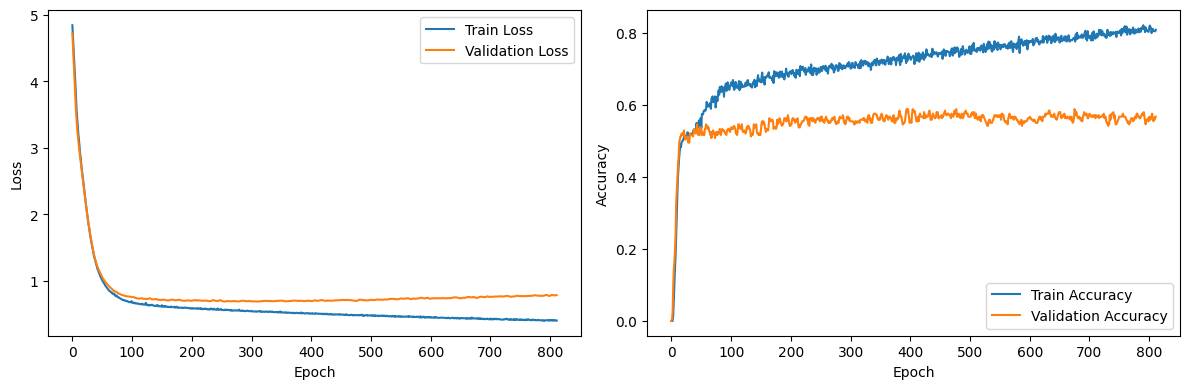


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9765, Val Loss: 2.7880, Train Acc: 0.4665, Val Acc: 0.4817
Epoch: 020, Train Loss: 2.0584, Val Loss: 1.9582, Train Acc: 0.5423, Val Acc: 0.4862
Epoch: 030, Train Loss: 1.4582, Val Loss: 1.4287, Train Acc: 0.5384, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.1131, Val Loss: 1.1248, Train Acc: 0.5522, Val Acc: 0.5275
Epoch: 050, Train Loss: 0.9214, Val Loss: 0.9665, Train Acc: 0.5778, Val Acc: 0.5413
Epoch: 060, Train Loss: 0.8179, Val Loss: 0.8745, Train Acc: 0.6043, Val Acc: 0.5505
Epoch: 070, Train Loss: 0.7815, Val Loss: 0.8249, Train Acc: 0.6024, Val Acc: 0.5688
Epoch: 080, Train Loss: 0.7262, Val Loss: 0.8037, Train Acc: 0.6161, Val Acc: 0.5780
Epoch: 090, Train Loss: 0.6947, Val Loss: 0.7850, Train Acc: 0.6171, Val Acc: 0.6009
Epoch: 100, Train Loss: 0.6648, Val Loss: 0.7723, Train Acc: 0.6476, Val Acc: 0.5780
Epoch: 110, Train Loss: 0.6455, Val Loss: 0.7679, Tr

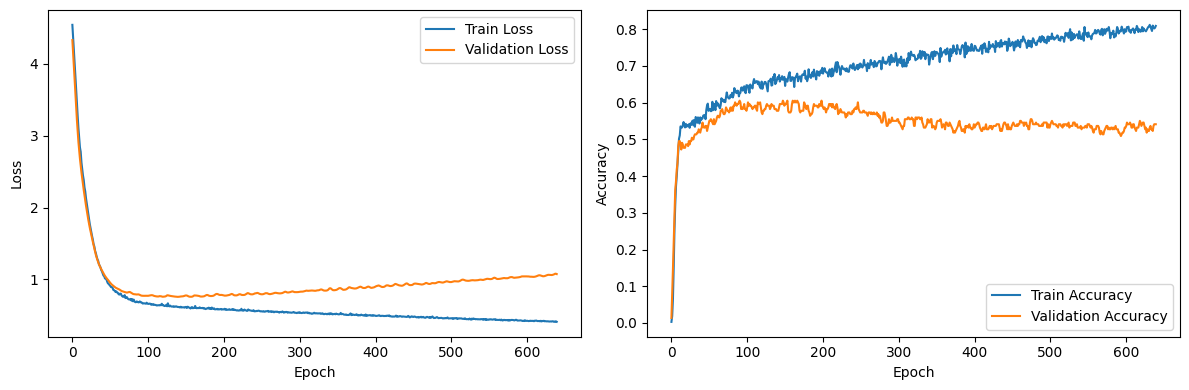


========== Run 8 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3772, Val Loss: 3.1370, Train Acc: 0.3537, Val Acc: 0.3910
Epoch: 020, Train Loss: 2.3397, Val Loss: 2.1597, Train Acc: 0.5431, Val Acc: 0.5150
Epoch: 030, Train Loss: 1.6350, Val Loss: 1.5258, Train Acc: 0.5705, Val Acc: 0.5451
Epoch: 040, Train Loss: 1.1942, Val Loss: 1.1571, Train Acc: 0.5745, Val Acc: 0.5526
Epoch: 050, Train Loss: 0.9540, Val Loss: 0.9708, Train Acc: 0.5931, Val Acc: 0.5639
Epoch: 060, Train Loss: 0.8222, Val Loss: 0.8672, Train Acc: 0.6205, Val Acc: 0.5639
Epoch: 070, Train Loss: 0.7510, Val Loss: 0.8219, Train Acc: 0.6189, Val Acc: 0.5376
Epoch: 080, Train Loss: 0.7032, Val Loss: 0.7888, Train Acc: 0.6317, Val Acc: 0.5526
Epoch: 090, Train Loss: 0.6778, Val Loss: 0.7699, Train Acc: 0.6422, Val Acc: 0.5639
Epoch: 100, Train Loss: 0.6567, Val Loss: 0.7578, Train Acc: 0.6527, Val Acc: 0.5789
Epoch: 110, Train Loss

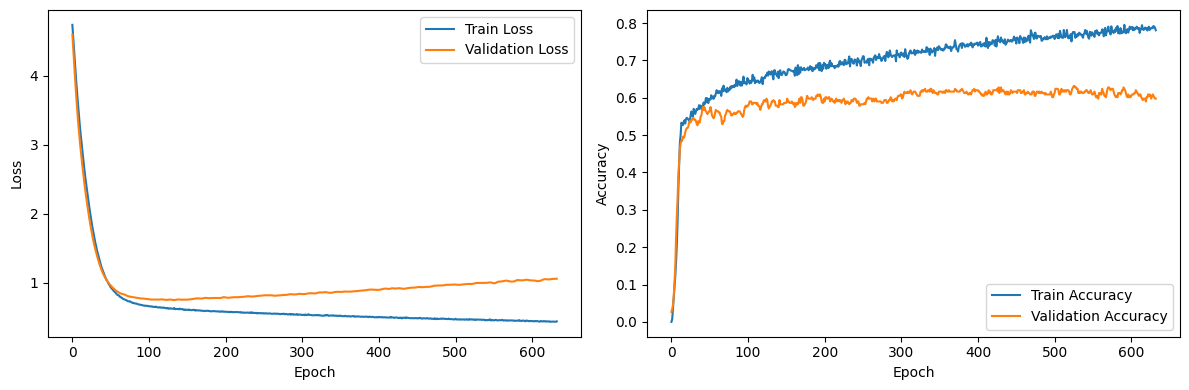


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5539, Val Loss: 3.4903, Train Acc: 0.3087, Val Acc: 0.3216
Epoch: 020, Train Loss: 2.3504, Val Loss: 2.3141, Train Acc: 0.5478, Val Acc: 0.4863
Epoch: 030, Train Loss: 1.5616, Val Loss: 1.6026, Train Acc: 0.5503, Val Acc: 0.5098
Epoch: 040, Train Loss: 1.1777, Val Loss: 1.2035, Train Acc: 0.5738, Val Acc: 0.5373
Epoch: 050, Train Loss: 0.9688, Val Loss: 1.0079, Train Acc: 0.5990, Val Acc: 0.5608
Epoch: 060, Train Loss: 0.8751, Val Loss: 0.8862, Train Acc: 0.6015, Val Acc: 0.5843
Epoch: 070, Train Loss: 0.7801, Val Loss: 0.8266, Train Acc: 0.6275, Val Acc: 0.5922
Epoch: 080, Train Loss: 0.7261, Val Loss: 0.8012, Train Acc: 0.6443, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6949, Val Loss: 0.7600, Train Acc: 0.6367, Val Acc: 0.5882
Epoch: 100, Train Loss: 0.6644, Val Loss: 0.7462, Train Acc: 0.6518, Val Acc: 0.5686
Epoch: 110, Train Loss: 0.6580, Val Loss: 0.7451, Tr

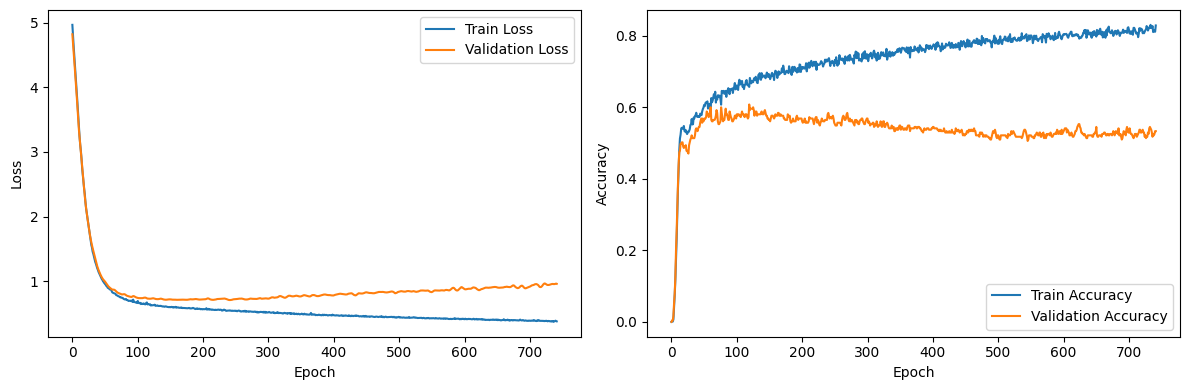


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1766, Val Loss: 3.0565, Train Acc: 0.3920, Val Acc: 0.3941
Epoch: 020, Train Loss: 2.2101, Val Loss: 2.2431, Train Acc: 0.5163, Val Acc: 0.4703
Epoch: 030, Train Loss: 1.6094, Val Loss: 1.6120, Train Acc: 0.5245, Val Acc: 0.5042
Epoch: 040, Train Loss: 1.1780, Val Loss: 1.2494, Train Acc: 0.5499, Val Acc: 0.5042
Epoch: 050, Train Loss: 0.9680, Val Loss: 1.0267, Train Acc: 0.5780, Val Acc: 0.5212
Epoch: 060, Train Loss: 0.8488, Val Loss: 0.9213, Train Acc: 0.5917, Val Acc: 0.5254
Epoch: 070, Train Loss: 0.7803, Val Loss: 0.8512, Train Acc: 0.6007, Val Acc: 0.5381
Epoch: 080, Train Loss: 0.7322, Val Loss: 0.8048, Train Acc: 0.6270, Val Acc: 0.5254
Epoch: 090, Train Loss: 0.6971, Val Loss: 0.7906, Train Acc: 0.6225, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.6845, Val Loss: 0.7651, Train Acc: 0.6479, Val Acc: 0.5127
Epoch: 110, Train Loss: 0.6596, Val Loss: 0.7536, Tr

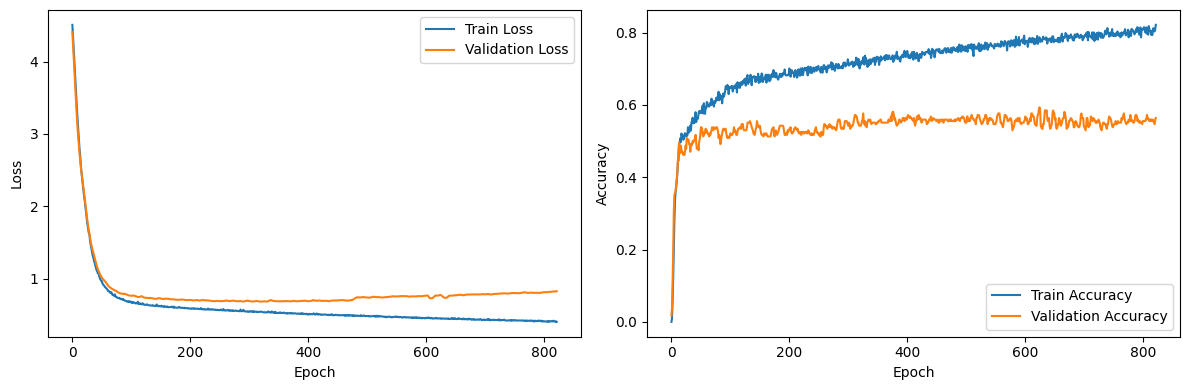


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5201, Val Loss: 3.3798, Train Acc: 0.3760, Val Acc: 0.4128
Epoch: 020, Train Loss: 2.2845, Val Loss: 2.1557, Train Acc: 0.5069, Val Acc: 0.4862
Epoch: 030, Train Loss: 1.5605, Val Loss: 1.4758, Train Acc: 0.5285, Val Acc: 0.4633
Epoch: 040, Train Loss: 1.1605, Val Loss: 1.1140, Train Acc: 0.5413, Val Acc: 0.5367
Epoch: 050, Train Loss: 0.9452, Val Loss: 0.9353, Train Acc: 0.5699, Val Acc: 0.5596
Epoch: 060, Train Loss: 0.8240, Val Loss: 0.8544, Train Acc: 0.6004, Val Acc: 0.5229
Epoch: 070, Train Loss: 0.7554, Val Loss: 0.8061, Train Acc: 0.6339, Val Acc: 0.5000
Epoch: 080, Train Loss: 0.7147, Val Loss: 0.7823, Train Acc: 0.6073, Val Acc: 0.5321
Epoch: 090, Train Loss: 0.6884, Val Loss: 0.7673, Train Acc: 0.6417, Val Acc: 0.5596
Epoch: 100, Train Loss: 0.6672, Val Loss: 0.7642, Train Acc: 0.6447, Val Acc: 0.5550
Epoch: 110, Train Loss: 0.6465, Val Loss: 0.7496, Tr

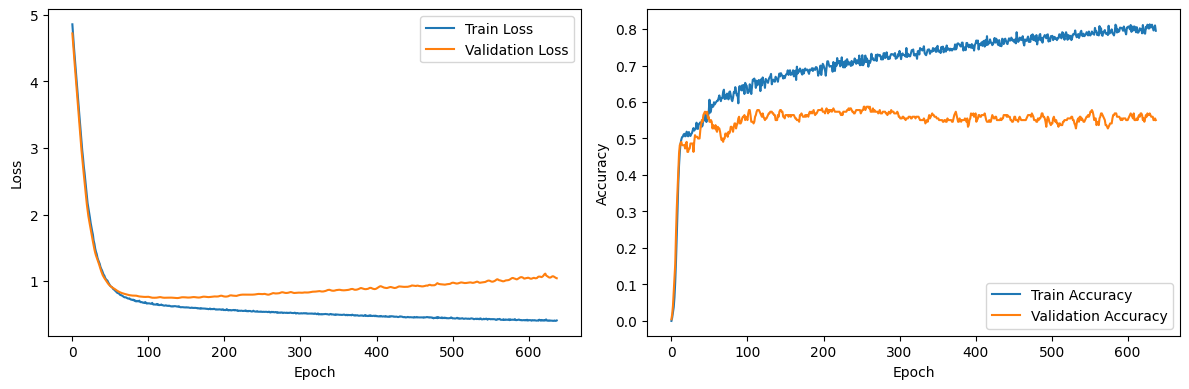


========== Run 9 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5985, Val Loss: 3.3883, Train Acc: 0.2804, Val Acc: 0.3797
Epoch: 020, Train Loss: 2.4072, Val Loss: 2.1975, Train Acc: 0.5504, Val Acc: 0.5639
Epoch: 030, Train Loss: 1.6349, Val Loss: 1.4915, Train Acc: 0.5697, Val Acc: 0.5602
Epoch: 040, Train Loss: 1.1825, Val Loss: 1.1293, Train Acc: 0.5761, Val Acc: 0.5489
Epoch: 050, Train Loss: 0.9484, Val Loss: 0.9505, Train Acc: 0.5923, Val Acc: 0.5789
Epoch: 060, Train Loss: 0.8207, Val Loss: 0.8523, Train Acc: 0.6084, Val Acc: 0.5789
Epoch: 070, Train Loss: 0.7552, Val Loss: 0.8205, Train Acc: 0.6092, Val Acc: 0.5789
Epoch: 080, Train Loss: 0.7123, Val Loss: 0.7793, Train Acc: 0.6213, Val Acc: 0.5865
Epoch: 090, Train Loss: 0.6848, Val Loss: 0.7659, Train Acc: 0.6269, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6672, Val Loss: 0.7673, Train Acc: 0.6366, Val Acc: 0.5827
Epoch: 110, Train Loss

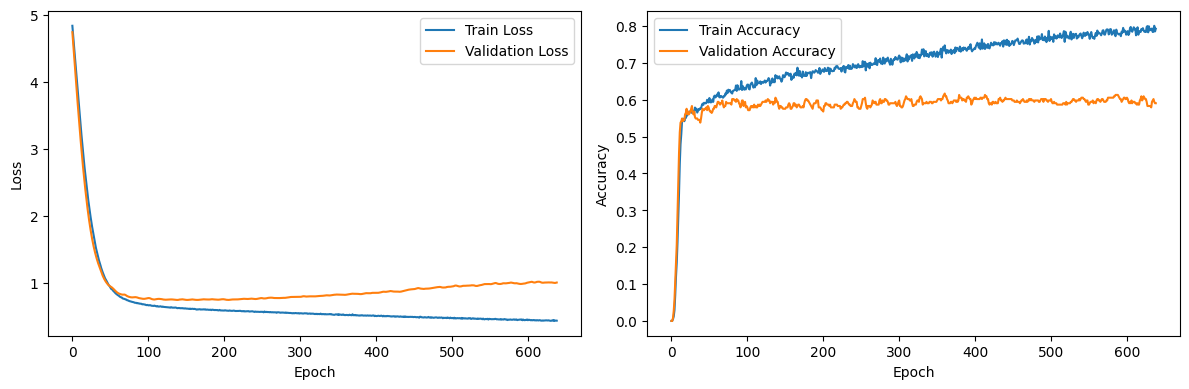


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6610, Val Loss: 3.5730, Train Acc: 0.4572, Val Acc: 0.4784
Epoch: 020, Train Loss: 2.3497, Val Loss: 2.2730, Train Acc: 0.5369, Val Acc: 0.4863
Epoch: 030, Train Loss: 1.4910, Val Loss: 1.4945, Train Acc: 0.5612, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.0999, Val Loss: 1.1388, Train Acc: 0.5763, Val Acc: 0.4941
Epoch: 050, Train Loss: 0.9108, Val Loss: 0.9668, Train Acc: 0.6023, Val Acc: 0.5255
Epoch: 060, Train Loss: 0.8125, Val Loss: 0.8691, Train Acc: 0.6300, Val Acc: 0.5725
Epoch: 070, Train Loss: 0.7421, Val Loss: 0.8092, Train Acc: 0.6317, Val Acc: 0.5804
Epoch: 080, Train Loss: 0.7036, Val Loss: 0.7802, Train Acc: 0.6309, Val Acc: 0.5882
Epoch: 090, Train Loss: 0.6655, Val Loss: 0.7520, Train Acc: 0.6560, Val Acc: 0.6039
Epoch: 100, Train Loss: 0.6454, Val Loss: 0.7340, Train Acc: 0.6560, Val Acc: 0.6000
Epoch: 110, Train Loss: 0.6322, Val Loss: 0.7321, Tr

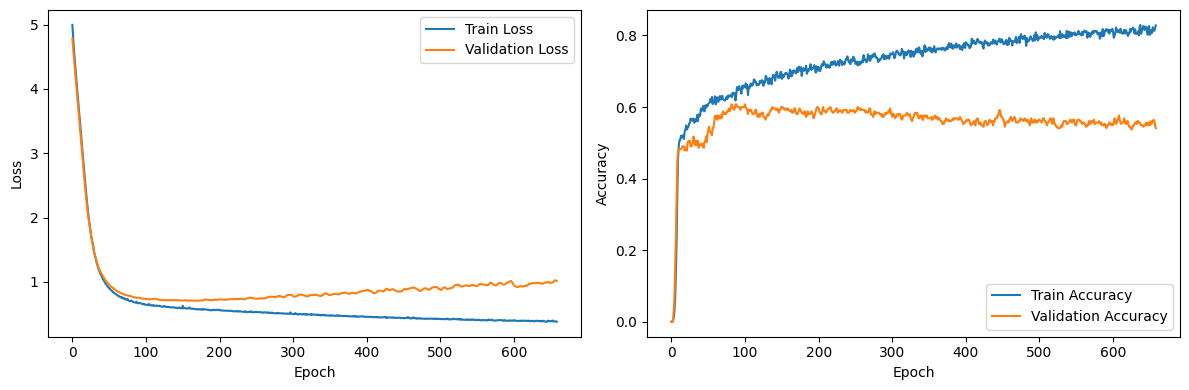


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0249, Val Loss: 2.8835, Train Acc: 0.3893, Val Acc: 0.4703
Epoch: 020, Train Loss: 2.1291, Val Loss: 2.1235, Train Acc: 0.5091, Val Acc: 0.5339
Epoch: 030, Train Loss: 1.5358, Val Loss: 1.5434, Train Acc: 0.5345, Val Acc: 0.5636
Epoch: 040, Train Loss: 1.1908, Val Loss: 1.2077, Train Acc: 0.5490, Val Acc: 0.5339
Epoch: 050, Train Loss: 0.9688, Val Loss: 1.0058, Train Acc: 0.6016, Val Acc: 0.5424
Epoch: 060, Train Loss: 0.8609, Val Loss: 0.8933, Train Acc: 0.6162, Val Acc: 0.5466
Epoch: 070, Train Loss: 0.7754, Val Loss: 0.8285, Train Acc: 0.6216, Val Acc: 0.5339
Epoch: 080, Train Loss: 0.7277, Val Loss: 0.7797, Train Acc: 0.6488, Val Acc: 0.5466
Epoch: 090, Train Loss: 0.6972, Val Loss: 0.7482, Train Acc: 0.6561, Val Acc: 0.5424
Epoch: 100, Train Loss: 0.6811, Val Loss: 0.7351, Train Acc: 0.6561, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6664, Val Loss: 0.7315, Tr

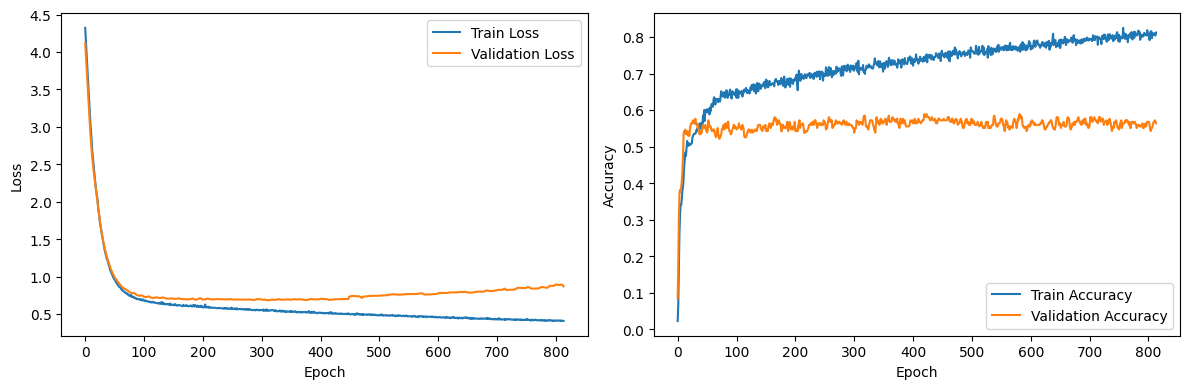


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5439, Val Loss: 3.4086, Train Acc: 0.3967, Val Acc: 0.4037
Epoch: 020, Train Loss: 2.3159, Val Loss: 2.1993, Train Acc: 0.5276, Val Acc: 0.4725
Epoch: 030, Train Loss: 1.5794, Val Loss: 1.5165, Train Acc: 0.5443, Val Acc: 0.4587
Epoch: 040, Train Loss: 1.2005, Val Loss: 1.1495, Train Acc: 0.5512, Val Acc: 0.4771
Epoch: 050, Train Loss: 0.9800, Val Loss: 0.9690, Train Acc: 0.5610, Val Acc: 0.5138
Epoch: 060, Train Loss: 0.8549, Val Loss: 0.8902, Train Acc: 0.5846, Val Acc: 0.4862
Epoch: 070, Train Loss: 0.7795, Val Loss: 0.8255, Train Acc: 0.5955, Val Acc: 0.5046
Epoch: 080, Train Loss: 0.7391, Val Loss: 0.7924, Train Acc: 0.6132, Val Acc: 0.5138
Epoch: 090, Train Loss: 0.6947, Val Loss: 0.7748, Train Acc: 0.6152, Val Acc: 0.5092
Epoch: 100, Train Loss: 0.6805, Val Loss: 0.7653, Train Acc: 0.6329, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6607, Val Loss: 0.7516, Tr

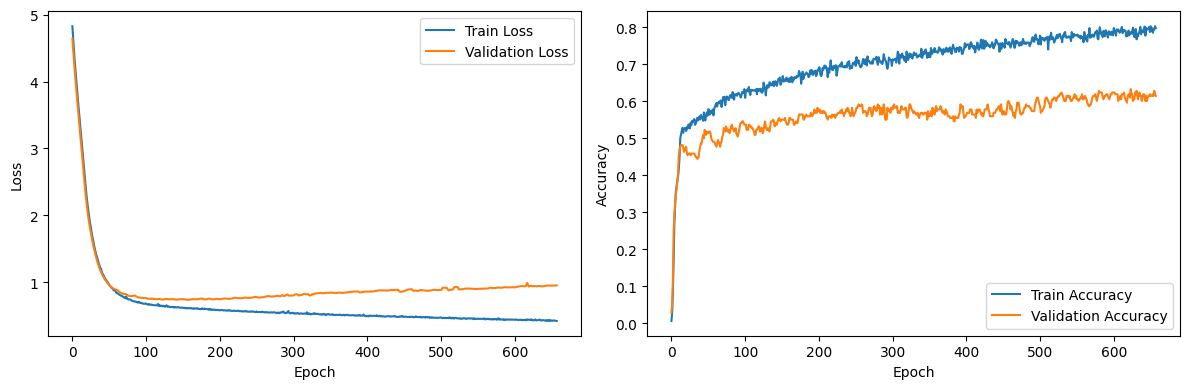


========== Run 10 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5874, Val Loss: 3.3134, Train Acc: 0.2240, Val Acc: 0.2669
Epoch: 020, Train Loss: 2.4471, Val Loss: 2.2212, Train Acc: 0.5624, Val Acc: 0.5602
Epoch: 030, Train Loss: 1.6735, Val Loss: 1.5384, Train Acc: 0.5850, Val Acc: 0.5489
Epoch: 040, Train Loss: 1.2056, Val Loss: 1.1405, Train Acc: 0.6003, Val Acc: 0.5602
Epoch: 050, Train Loss: 0.9595, Val Loss: 0.9440, Train Acc: 0.6253, Val Acc: 0.5602
Epoch: 060, Train Loss: 0.8307, Val Loss: 0.8307, Train Acc: 0.6189, Val Acc: 0.6165
Epoch: 070, Train Loss: 0.7517, Val Loss: 0.7835, Train Acc: 0.6334, Val Acc: 0.6053
Epoch: 080, Train Loss: 0.7084, Val Loss: 0.7649, Train Acc: 0.6309, Val Acc: 0.5752
Epoch: 090, Train Loss: 0.6768, Val Loss: 0.7458, Train Acc: 0.6479, Val Acc: 0.5977
Epoch: 100, Train Loss: 0.6597, Val Loss: 0.7372, Train Acc: 0.6390, Val Acc: 0.5977
Epoch: 110, Train Los

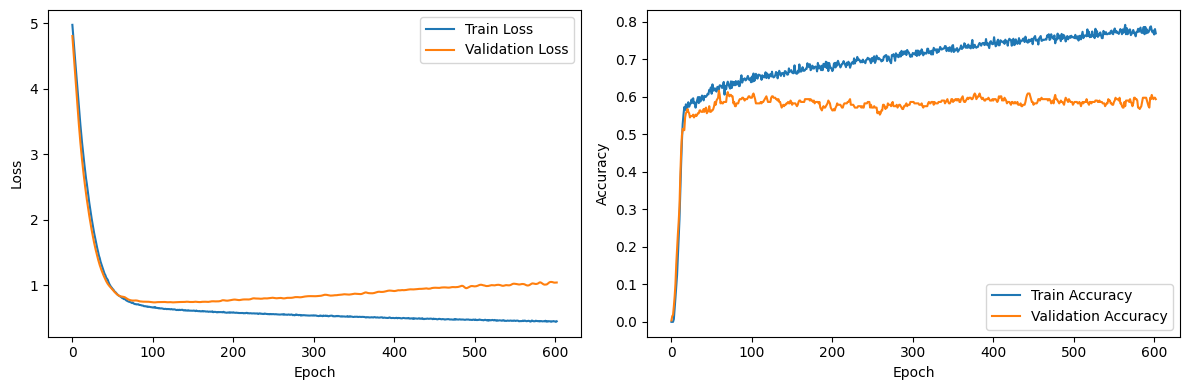


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5213, Val Loss: 3.4019, Train Acc: 0.3884, Val Acc: 0.4510
Epoch: 020, Train Loss: 2.2921, Val Loss: 2.2414, Train Acc: 0.5671, Val Acc: 0.5098
Epoch: 030, Train Loss: 1.5295, Val Loss: 1.5210, Train Acc: 0.5721, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.1295, Val Loss: 1.1413, Train Acc: 0.5965, Val Acc: 0.5020
Epoch: 050, Train Loss: 0.9349, Val Loss: 0.9604, Train Acc: 0.6258, Val Acc: 0.5294
Epoch: 060, Train Loss: 0.8147, Val Loss: 0.8680, Train Acc: 0.6300, Val Acc: 0.5059
Epoch: 070, Train Loss: 0.7533, Val Loss: 0.8100, Train Acc: 0.6191, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.7003, Val Loss: 0.7744, Train Acc: 0.6502, Val Acc: 0.5451
Epoch: 090, Train Loss: 0.6710, Val Loss: 0.7569, Train Acc: 0.6686, Val Acc: 0.5490
Epoch: 100, Train Loss: 0.6487, Val Loss: 0.7451, Train Acc: 0.6695, Val Acc: 0.5490
Epoch: 110, Train Loss: 0.6336, Val Loss: 0.7402, Tr

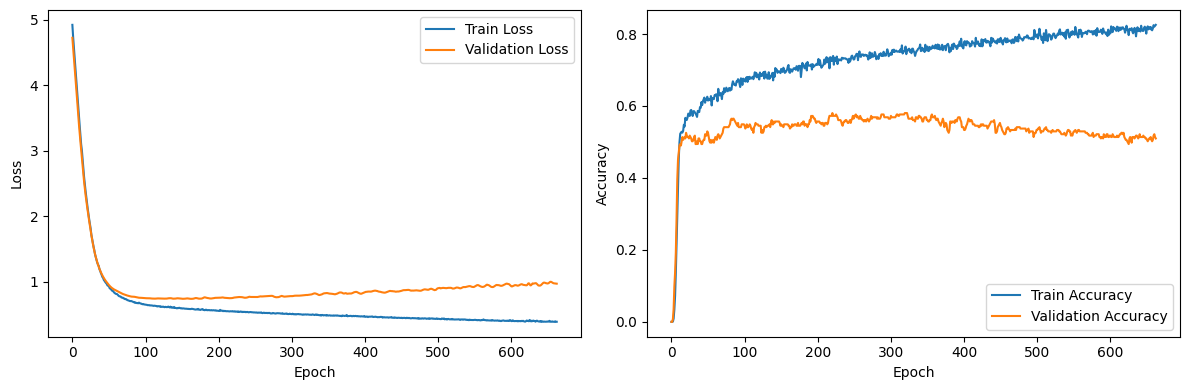


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3810, Val Loss: 3.1876, Train Acc: 0.3494, Val Acc: 0.4703
Epoch: 020, Train Loss: 2.2405, Val Loss: 2.1987, Train Acc: 0.5336, Val Acc: 0.5805
Epoch: 030, Train Loss: 1.5616, Val Loss: 1.5710, Train Acc: 0.5554, Val Acc: 0.5636
Epoch: 040, Train Loss: 1.1692, Val Loss: 1.1935, Train Acc: 0.5789, Val Acc: 0.5297
Epoch: 050, Train Loss: 0.9588, Val Loss: 0.9905, Train Acc: 0.5980, Val Acc: 0.5127
Epoch: 060, Train Loss: 0.8369, Val Loss: 0.8990, Train Acc: 0.6316, Val Acc: 0.5000
Epoch: 070, Train Loss: 0.7795, Val Loss: 0.8232, Train Acc: 0.6198, Val Acc: 0.5127
Epoch: 080, Train Loss: 0.7339, Val Loss: 0.7869, Train Acc: 0.6261, Val Acc: 0.5339
Epoch: 090, Train Loss: 0.6973, Val Loss: 0.7714, Train Acc: 0.6461, Val Acc: 0.5254
Epoch: 100, Train Loss: 0.6884, Val Loss: 0.7564, Train Acc: 0.6370, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6825, Val Loss: 0.7514, Tr

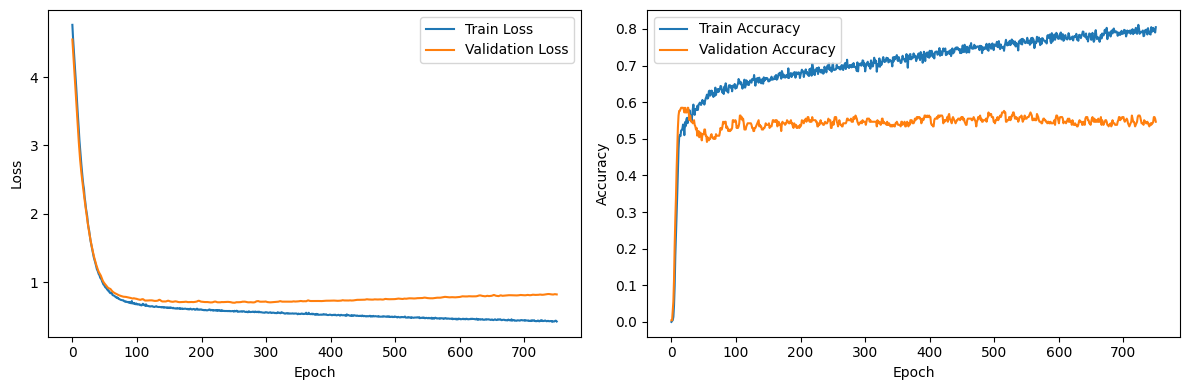


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1803, Val Loss: 3.0150, Train Acc: 0.4685, Val Acc: 0.4495
Epoch: 020, Train Loss: 2.1915, Val Loss: 2.1096, Train Acc: 0.5315, Val Acc: 0.4679
Epoch: 030, Train Loss: 1.5578, Val Loss: 1.5131, Train Acc: 0.5413, Val Acc: 0.4679
Epoch: 040, Train Loss: 1.2237, Val Loss: 1.1696, Train Acc: 0.5561, Val Acc: 0.4862
Epoch: 050, Train Loss: 1.0058, Val Loss: 0.9901, Train Acc: 0.5669, Val Acc: 0.5367
Epoch: 060, Train Loss: 0.8715, Val Loss: 0.8944, Train Acc: 0.6112, Val Acc: 0.5229
Epoch: 070, Train Loss: 0.7904, Val Loss: 0.8371, Train Acc: 0.6230, Val Acc: 0.5321
Epoch: 080, Train Loss: 0.7396, Val Loss: 0.8013, Train Acc: 0.6161, Val Acc: 0.5642
Epoch: 090, Train Loss: 0.7050, Val Loss: 0.7707, Train Acc: 0.6388, Val Acc: 0.5413
Epoch: 100, Train Loss: 0.6700, Val Loss: 0.7597, Train Acc: 0.6476, Val Acc: 0.5688
Epoch: 110, Train Loss: 0.6532, Val Loss: 0.7533, Tr

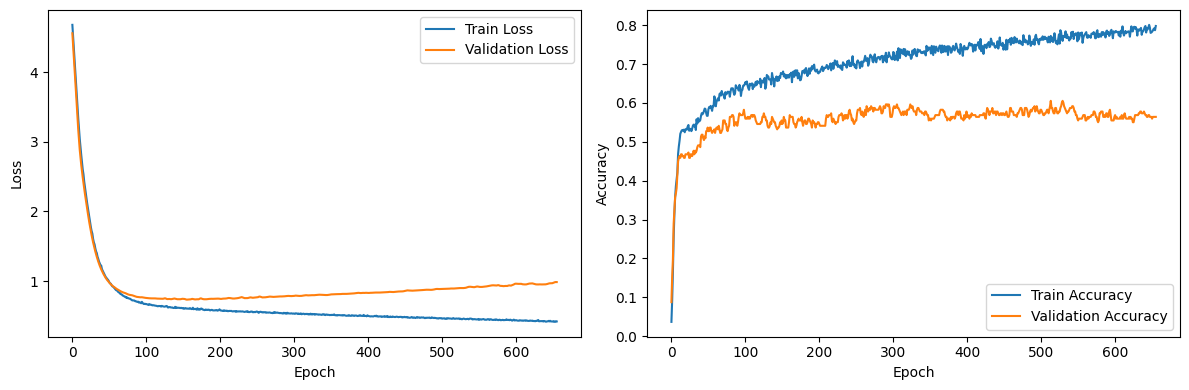


========== Run 11 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4676, Val Loss: 3.2489, Train Acc: 0.4029, Val Acc: 0.4135
Epoch: 020, Train Loss: 2.3424, Val Loss: 2.1667, Train Acc: 0.5262, Val Acc: 0.5188
Epoch: 030, Train Loss: 1.6576, Val Loss: 1.5612, Train Acc: 0.5488, Val Acc: 0.4962
Epoch: 040, Train Loss: 1.2519, Val Loss: 1.2134, Train Acc: 0.5810, Val Acc: 0.5226
Epoch: 050, Train Loss: 1.0127, Val Loss: 1.0275, Train Acc: 0.5713, Val Acc: 0.5526
Epoch: 060, Train Loss: 0.8743, Val Loss: 0.9076, Train Acc: 0.6019, Val Acc: 0.5827
Epoch: 070, Train Loss: 0.7892, Val Loss: 0.8416, Train Acc: 0.6277, Val Acc: 0.6053
Epoch: 080, Train Loss: 0.7396, Val Loss: 0.8025, Train Acc: 0.6245, Val Acc: 0.5977
Epoch: 090, Train Loss: 0.7000, Val Loss: 0.7790, Train Acc: 0.6358, Val Acc: 0.5977
Epoch: 100, Train Loss: 0.6690, Val Loss: 0.7615, Train Acc: 0.6583, Val Acc: 0.6128
Epoch: 110, Train Los

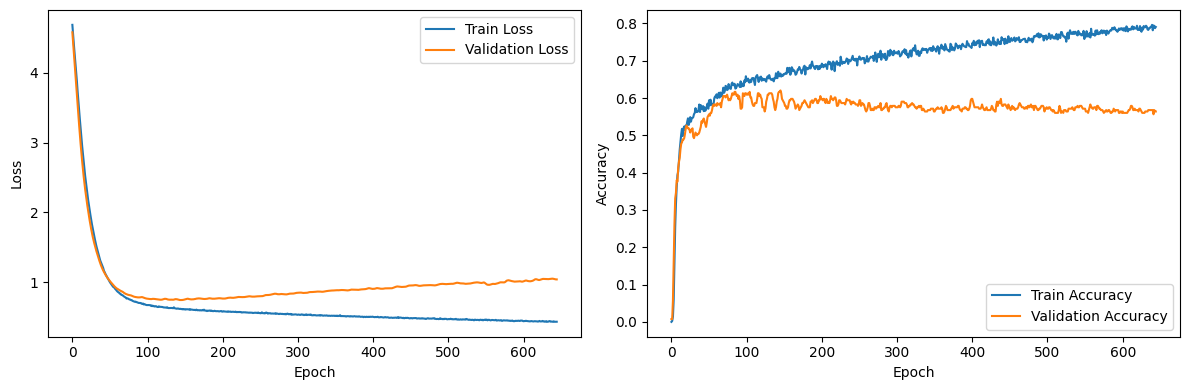


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2014, Val Loss: 3.1253, Train Acc: 0.3951, Val Acc: 0.4275
Epoch: 020, Train Loss: 2.1055, Val Loss: 2.0967, Train Acc: 0.5126, Val Acc: 0.4902
Epoch: 030, Train Loss: 1.4527, Val Loss: 1.4665, Train Acc: 0.5319, Val Acc: 0.4784
Epoch: 040, Train Loss: 1.0953, Val Loss: 1.1231, Train Acc: 0.6007, Val Acc: 0.4980
Epoch: 050, Train Loss: 0.9140, Val Loss: 0.9522, Train Acc: 0.6082, Val Acc: 0.5294
Epoch: 060, Train Loss: 0.8033, Val Loss: 0.8606, Train Acc: 0.6191, Val Acc: 0.5451
Epoch: 070, Train Loss: 0.7334, Val Loss: 0.8106, Train Acc: 0.6409, Val Acc: 0.5373
Epoch: 080, Train Loss: 0.6995, Val Loss: 0.7702, Train Acc: 0.6401, Val Acc: 0.5451
Epoch: 090, Train Loss: 0.6661, Val Loss: 0.7609, Train Acc: 0.6594, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.6569, Val Loss: 0.7333, Train Acc: 0.6569, Val Acc: 0.5529
Epoch: 110, Train Loss: 0.6275, Val Loss: 0.7249, Tr

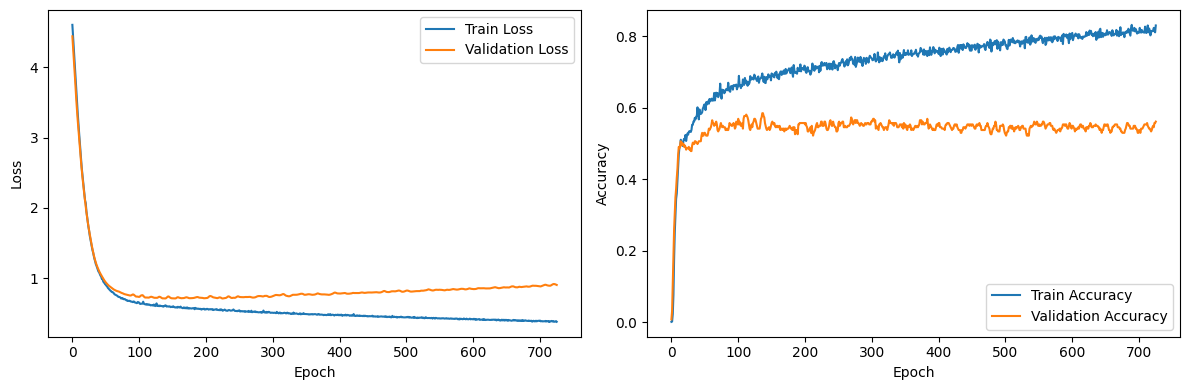


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6505, Val Loss: 3.5507, Train Acc: 0.2840, Val Acc: 0.3093
Epoch: 020, Train Loss: 2.3580, Val Loss: 2.3523, Train Acc: 0.5127, Val Acc: 0.4915
Epoch: 030, Train Loss: 1.6053, Val Loss: 1.6566, Train Acc: 0.5299, Val Acc: 0.4661
Epoch: 040, Train Loss: 1.1851, Val Loss: 1.2444, Train Acc: 0.5381, Val Acc: 0.4703
Epoch: 050, Train Loss: 0.9647, Val Loss: 1.0179, Train Acc: 0.5690, Val Acc: 0.5000
Epoch: 060, Train Loss: 0.8474, Val Loss: 0.9044, Train Acc: 0.5690, Val Acc: 0.5085
Epoch: 070, Train Loss: 0.7775, Val Loss: 0.8356, Train Acc: 0.5808, Val Acc: 0.5339
Epoch: 080, Train Loss: 0.7260, Val Loss: 0.7985, Train Acc: 0.6207, Val Acc: 0.5636
Epoch: 090, Train Loss: 0.6986, Val Loss: 0.7771, Train Acc: 0.6189, Val Acc: 0.5593
Epoch: 100, Train Loss: 0.6831, Val Loss: 0.7429, Train Acc: 0.6316, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.6537, Val Loss: 0.7297, Tr

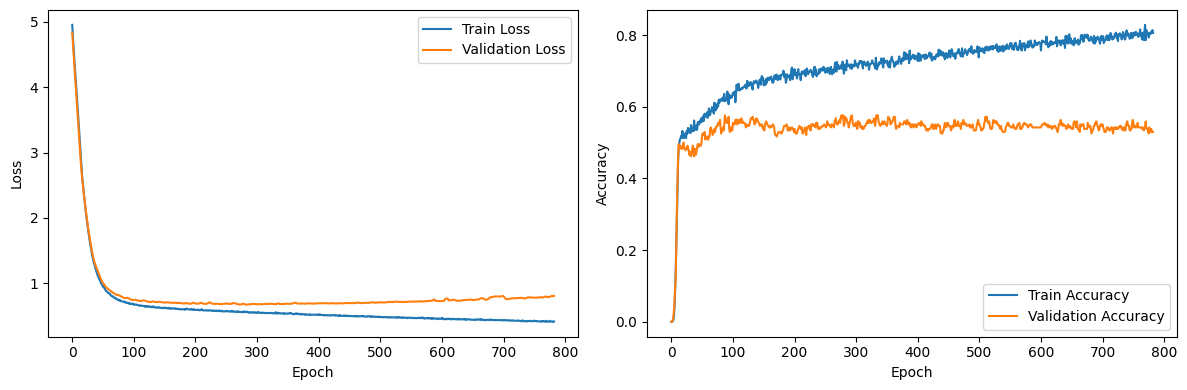


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3313, Val Loss: 3.0481, Train Acc: 0.3760, Val Acc: 0.4220
Epoch: 020, Train Loss: 2.2455, Val Loss: 2.0465, Train Acc: 0.4902, Val Acc: 0.5229
Epoch: 030, Train Loss: 1.5859, Val Loss: 1.4590, Train Acc: 0.5276, Val Acc: 0.5734
Epoch: 040, Train Loss: 1.1944, Val Loss: 1.1471, Train Acc: 0.5512, Val Acc: 0.5367
Epoch: 050, Train Loss: 0.9915, Val Loss: 0.9973, Train Acc: 0.5472, Val Acc: 0.5046
Epoch: 060, Train Loss: 0.8755, Val Loss: 0.9031, Train Acc: 0.5600, Val Acc: 0.5229
Epoch: 070, Train Loss: 0.7858, Val Loss: 0.8327, Train Acc: 0.6004, Val Acc: 0.5596
Epoch: 080, Train Loss: 0.7445, Val Loss: 0.8001, Train Acc: 0.5866, Val Acc: 0.5275
Epoch: 090, Train Loss: 0.6947, Val Loss: 0.7773, Train Acc: 0.6270, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6863, Val Loss: 0.7651, Train Acc: 0.6004, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6557, Val Loss: 0.7576, Tr

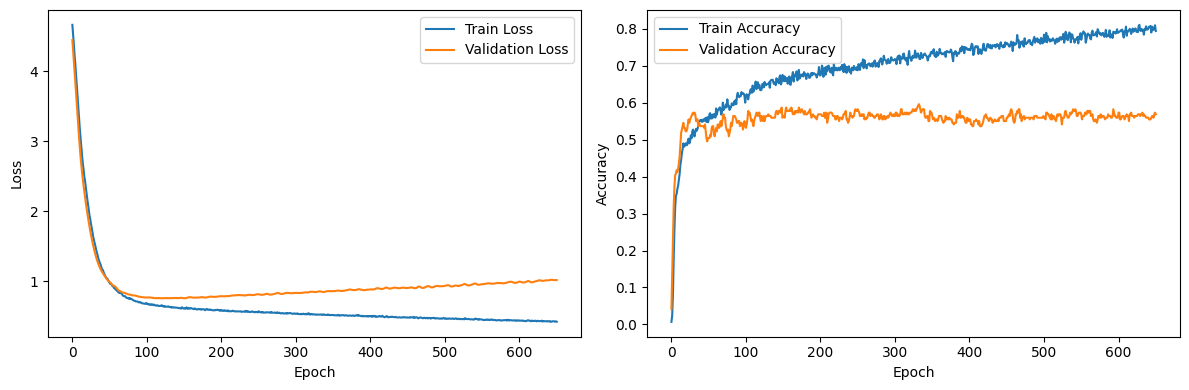


========== Run 12 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3825, Val Loss: 3.1626, Train Acc: 0.4416, Val Acc: 0.4737
Epoch: 020, Train Loss: 2.2475, Val Loss: 2.0542, Train Acc: 0.5520, Val Acc: 0.5301
Epoch: 030, Train Loss: 1.5609, Val Loss: 1.4450, Train Acc: 0.5592, Val Acc: 0.5150
Epoch: 040, Train Loss: 1.1572, Val Loss: 1.1019, Train Acc: 0.5673, Val Acc: 0.5338
Epoch: 050, Train Loss: 0.9423, Val Loss: 0.9330, Train Acc: 0.5963, Val Acc: 0.5602
Epoch: 060, Train Loss: 0.8259, Val Loss: 0.8280, Train Acc: 0.6092, Val Acc: 0.5789
Epoch: 070, Train Loss: 0.7490, Val Loss: 0.7765, Train Acc: 0.6301, Val Acc: 0.5940
Epoch: 080, Train Loss: 0.7059, Val Loss: 0.7509, Train Acc: 0.6350, Val Acc: 0.5940
Epoch: 090, Train Loss: 0.6805, Val Loss: 0.7260, Train Acc: 0.6454, Val Acc: 0.6090
Epoch: 100, Train Loss: 0.6605, Val Loss: 0.7284, Train Acc: 0.6624, Val Acc: 0.6053
Epoch: 110, Train Los

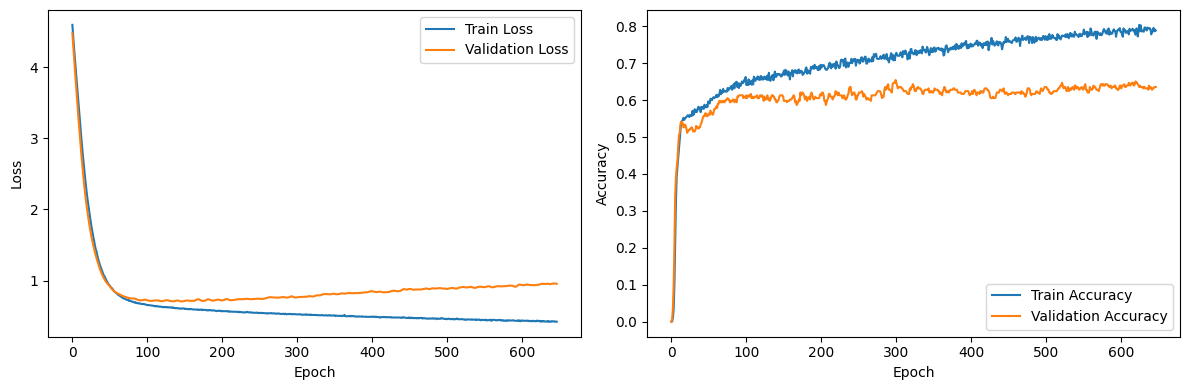


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8107, Val Loss: 2.7201, Train Acc: 0.4975, Val Acc: 0.4824
Epoch: 020, Train Loss: 1.8684, Val Loss: 1.8393, Train Acc: 0.5235, Val Acc: 0.4824
Epoch: 030, Train Loss: 1.3342, Val Loss: 1.3438, Train Acc: 0.5604, Val Acc: 0.4980
Epoch: 040, Train Loss: 1.0537, Val Loss: 1.0819, Train Acc: 0.5814, Val Acc: 0.5176
Epoch: 050, Train Loss: 0.8910, Val Loss: 0.9231, Train Acc: 0.6049, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.7992, Val Loss: 0.8404, Train Acc: 0.6107, Val Acc: 0.5451
Epoch: 070, Train Loss: 0.7315, Val Loss: 0.7889, Train Acc: 0.6174, Val Acc: 0.5490
Epoch: 080, Train Loss: 0.6962, Val Loss: 0.7642, Train Acc: 0.6367, Val Acc: 0.5490
Epoch: 090, Train Loss: 0.6660, Val Loss: 0.7567, Train Acc: 0.6384, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6469, Val Loss: 0.7366, Train Acc: 0.6435, Val Acc: 0.5725
Epoch: 110, Train Loss: 0.6358, Val Loss: 0.7299, Tr

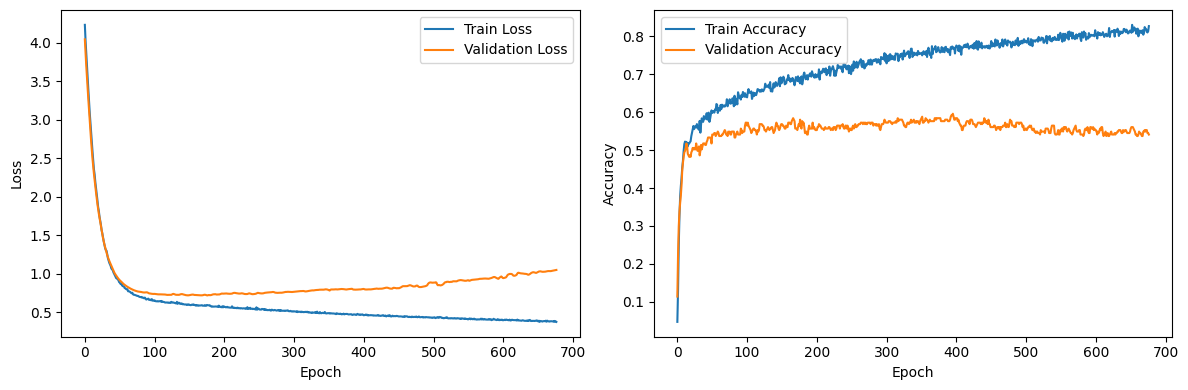


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1576, Val Loss: 3.0603, Train Acc: 0.4946, Val Acc: 0.5127
Epoch: 020, Train Loss: 2.2215, Val Loss: 2.1803, Train Acc: 0.5363, Val Acc: 0.5381
Epoch: 030, Train Loss: 1.5521, Val Loss: 1.5822, Train Acc: 0.5481, Val Acc: 0.5381
Epoch: 040, Train Loss: 1.1642, Val Loss: 1.2081, Train Acc: 0.5508, Val Acc: 0.5339
Epoch: 050, Train Loss: 0.9641, Val Loss: 1.0352, Train Acc: 0.5862, Val Acc: 0.5339
Epoch: 060, Train Loss: 0.8464, Val Loss: 0.9119, Train Acc: 0.6044, Val Acc: 0.5212
Epoch: 070, Train Loss: 0.7834, Val Loss: 0.8346, Train Acc: 0.6025, Val Acc: 0.5466
Epoch: 080, Train Loss: 0.7214, Val Loss: 0.7990, Train Acc: 0.6370, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.6963, Val Loss: 0.7725, Train Acc: 0.6416, Val Acc: 0.5339
Epoch: 100, Train Loss: 0.6713, Val Loss: 0.7436, Train Acc: 0.6525, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6530, Val Loss: 0.7336, Tr

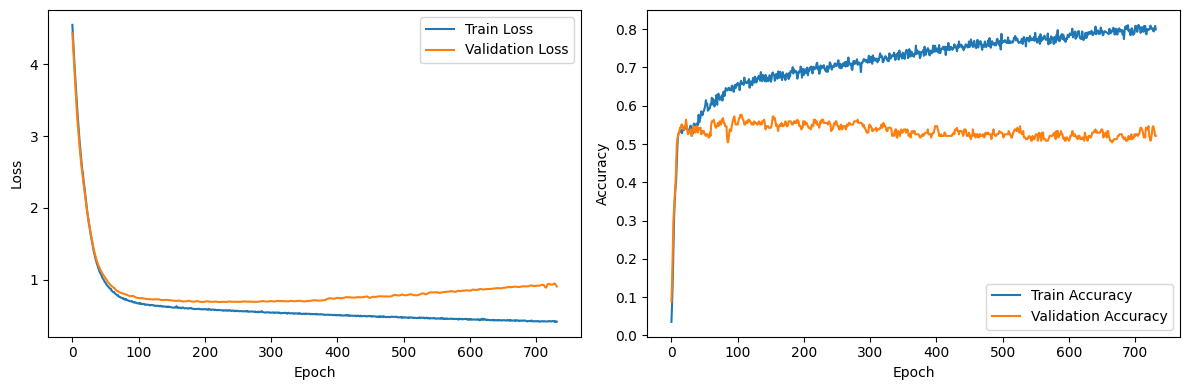


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2402, Val Loss: 3.0079, Train Acc: 0.4272, Val Acc: 0.5550
Epoch: 020, Train Loss: 2.1580, Val Loss: 1.9989, Train Acc: 0.4980, Val Acc: 0.5275
Epoch: 030, Train Loss: 1.5005, Val Loss: 1.4428, Train Acc: 0.5226, Val Acc: 0.5183
Epoch: 040, Train Loss: 1.1664, Val Loss: 1.1280, Train Acc: 0.5344, Val Acc: 0.5000
Epoch: 050, Train Loss: 0.9916, Val Loss: 0.9623, Train Acc: 0.5433, Val Acc: 0.5138
Epoch: 060, Train Loss: 0.8695, Val Loss: 0.8704, Train Acc: 0.5817, Val Acc: 0.5413
Epoch: 070, Train Loss: 0.7846, Val Loss: 0.8108, Train Acc: 0.5945, Val Acc: 0.5596
Epoch: 080, Train Loss: 0.7348, Val Loss: 0.7788, Train Acc: 0.6112, Val Acc: 0.5413
Epoch: 090, Train Loss: 0.7031, Val Loss: 0.7641, Train Acc: 0.6132, Val Acc: 0.5183
Epoch: 100, Train Loss: 0.6769, Val Loss: 0.7406, Train Acc: 0.6319, Val Acc: 0.5229
Epoch: 110, Train Loss: 0.6596, Val Loss: 0.7453, Tr

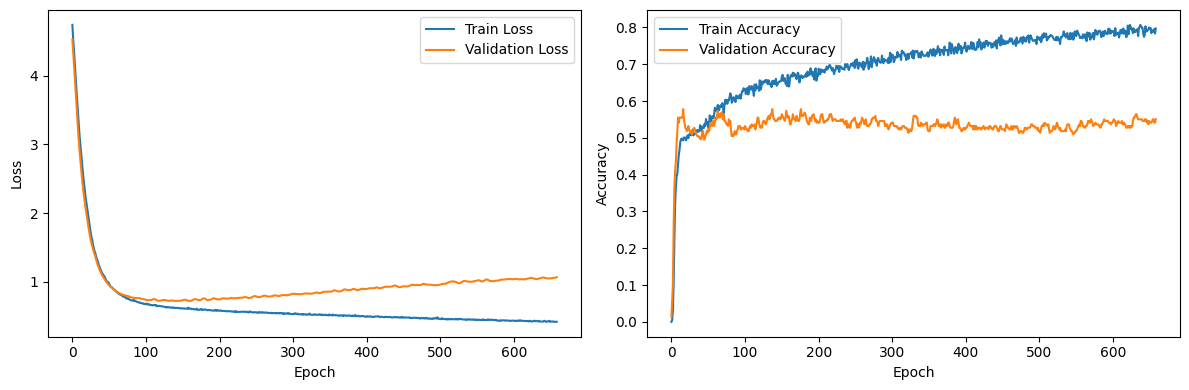


========== Run 13 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3616, Val Loss: 3.1523, Train Acc: 0.4110, Val Acc: 0.4098
Epoch: 020, Train Loss: 2.3040, Val Loss: 2.0894, Train Acc: 0.4827, Val Acc: 0.5113
Epoch: 030, Train Loss: 1.5799, Val Loss: 1.4766, Train Acc: 0.5359, Val Acc: 0.4887
Epoch: 040, Train Loss: 1.1617, Val Loss: 1.1309, Train Acc: 0.5463, Val Acc: 0.5226
Epoch: 050, Train Loss: 0.9402, Val Loss: 0.9646, Train Acc: 0.5850, Val Acc: 0.5226
Epoch: 060, Train Loss: 0.8220, Val Loss: 0.8701, Train Acc: 0.6035, Val Acc: 0.5150
Epoch: 070, Train Loss: 0.7505, Val Loss: 0.8153, Train Acc: 0.6164, Val Acc: 0.5489
Epoch: 080, Train Loss: 0.7098, Val Loss: 0.7845, Train Acc: 0.6309, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.6847, Val Loss: 0.7673, Train Acc: 0.6358, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.6639, Val Loss: 0.7553, Train Acc: 0.6398, Val Acc: 0.6053
Epoch: 110, Train Los

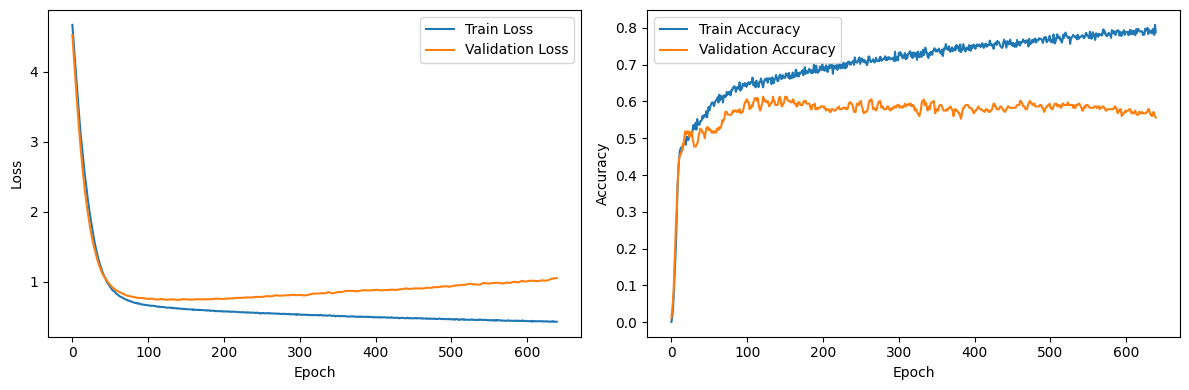


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1160, Val Loss: 3.0408, Train Acc: 0.4279, Val Acc: 0.4588
Epoch: 020, Train Loss: 2.0624, Val Loss: 2.0752, Train Acc: 0.5470, Val Acc: 0.4902
Epoch: 030, Train Loss: 1.4576, Val Loss: 1.5068, Train Acc: 0.5411, Val Acc: 0.4745
Epoch: 040, Train Loss: 1.1099, Val Loss: 1.1671, Train Acc: 0.5822, Val Acc: 0.4745
Epoch: 050, Train Loss: 0.9360, Val Loss: 0.9792, Train Acc: 0.5889, Val Acc: 0.4902
Epoch: 060, Train Loss: 0.8290, Val Loss: 0.8834, Train Acc: 0.6040, Val Acc: 0.5294
Epoch: 070, Train Loss: 0.7457, Val Loss: 0.8256, Train Acc: 0.6225, Val Acc: 0.5059
Epoch: 080, Train Loss: 0.6995, Val Loss: 0.7921, Train Acc: 0.6401, Val Acc: 0.5137
Epoch: 090, Train Loss: 0.6658, Val Loss: 0.7821, Train Acc: 0.6594, Val Acc: 0.5059
Epoch: 100, Train Loss: 0.6489, Val Loss: 0.7601, Train Acc: 0.6569, Val Acc: 0.5059
Epoch: 110, Train Loss: 0.6279, Val Loss: 0.7447, Tr

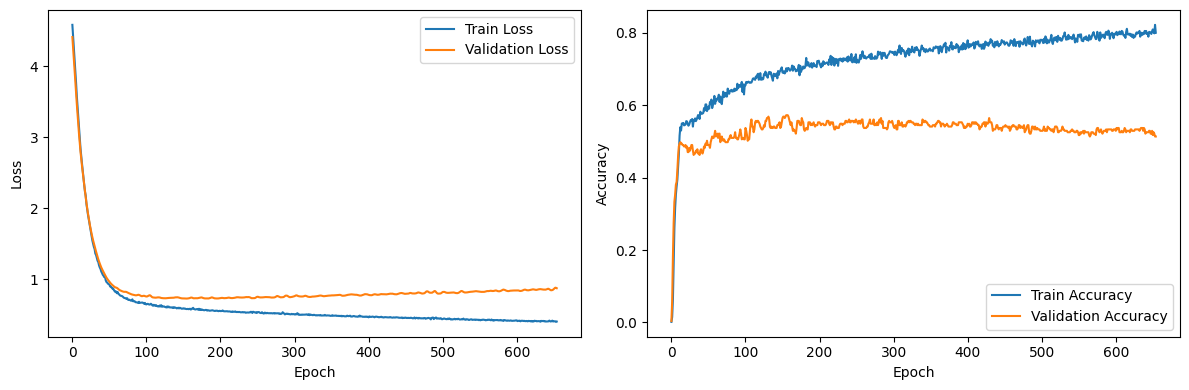


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.7199, Val Loss: 3.6249, Train Acc: 0.3376, Val Acc: 0.4280
Epoch: 020, Train Loss: 2.4109, Val Loss: 2.3955, Train Acc: 0.5372, Val Acc: 0.5085
Epoch: 030, Train Loss: 1.6330, Val Loss: 1.6245, Train Acc: 0.5499, Val Acc: 0.5381
Epoch: 040, Train Loss: 1.1524, Val Loss: 1.2320, Train Acc: 0.5572, Val Acc: 0.4873
Epoch: 050, Train Loss: 0.9309, Val Loss: 1.0220, Train Acc: 0.6034, Val Acc: 0.5297
Epoch: 060, Train Loss: 0.8178, Val Loss: 0.9066, Train Acc: 0.5989, Val Acc: 0.5339
Epoch: 070, Train Loss: 0.7546, Val Loss: 0.8381, Train Acc: 0.6152, Val Acc: 0.5678
Epoch: 080, Train Loss: 0.7168, Val Loss: 0.7936, Train Acc: 0.6289, Val Acc: 0.5763
Epoch: 090, Train Loss: 0.6896, Val Loss: 0.7681, Train Acc: 0.6452, Val Acc: 0.5593
Epoch: 100, Train Loss: 0.6692, Val Loss: 0.7526, Train Acc: 0.6588, Val Acc: 0.5424
Epoch: 110, Train Loss: 0.6548, Val Loss: 0.7406, Tr

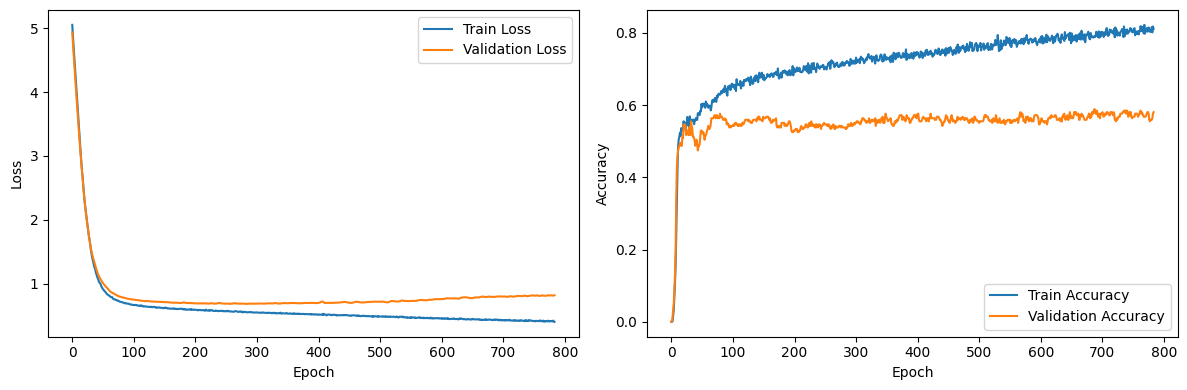


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6398, Val Loss: 3.4483, Train Acc: 0.3917, Val Acc: 0.4541
Epoch: 020, Train Loss: 2.4087, Val Loss: 2.2402, Train Acc: 0.5098, Val Acc: 0.4954
Epoch: 030, Train Loss: 1.6686, Val Loss: 1.5653, Train Acc: 0.5276, Val Acc: 0.4817
Epoch: 040, Train Loss: 1.2312, Val Loss: 1.1751, Train Acc: 0.5472, Val Acc: 0.4817
Epoch: 050, Train Loss: 1.0066, Val Loss: 0.9823, Train Acc: 0.5728, Val Acc: 0.5275
Epoch: 060, Train Loss: 0.8795, Val Loss: 0.8737, Train Acc: 0.5758, Val Acc: 0.5183
Epoch: 070, Train Loss: 0.7893, Val Loss: 0.8176, Train Acc: 0.5955, Val Acc: 0.5229
Epoch: 080, Train Loss: 0.7394, Val Loss: 0.7907, Train Acc: 0.5984, Val Acc: 0.5367
Epoch: 090, Train Loss: 0.6971, Val Loss: 0.7621, Train Acc: 0.6339, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6844, Val Loss: 0.7513, Train Acc: 0.6398, Val Acc: 0.5413
Epoch: 110, Train Loss: 0.6593, Val Loss: 0.7436, Tr

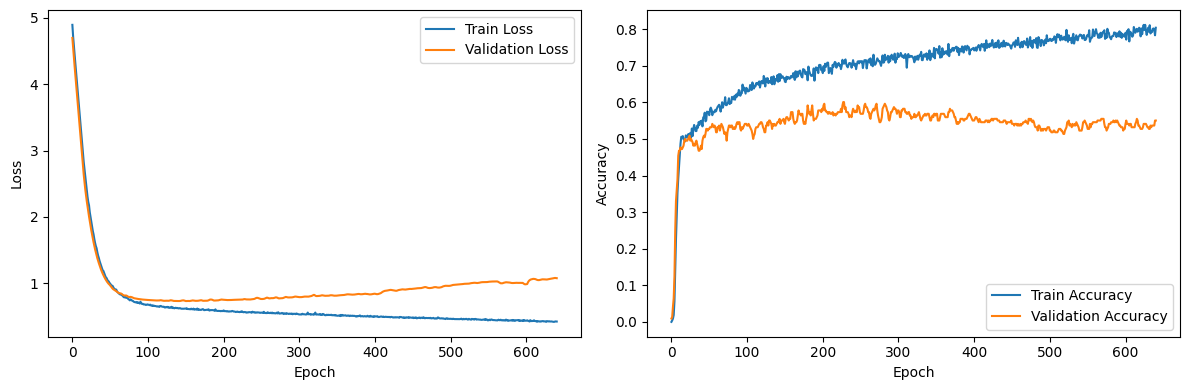


========== Run 14 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2411, Val Loss: 2.9580, Train Acc: 0.4311, Val Acc: 0.5038
Epoch: 020, Train Loss: 2.2120, Val Loss: 2.0108, Train Acc: 0.5238, Val Acc: 0.5150
Epoch: 030, Train Loss: 1.5362, Val Loss: 1.4423, Train Acc: 0.5334, Val Acc: 0.5301
Epoch: 040, Train Loss: 1.1457, Val Loss: 1.1137, Train Acc: 0.5633, Val Acc: 0.4887
Epoch: 050, Train Loss: 0.9373, Val Loss: 0.9594, Train Acc: 0.5874, Val Acc: 0.4624
Epoch: 060, Train Loss: 0.8206, Val Loss: 0.8676, Train Acc: 0.6116, Val Acc: 0.5150
Epoch: 070, Train Loss: 0.7451, Val Loss: 0.8200, Train Acc: 0.6317, Val Acc: 0.5150
Epoch: 080, Train Loss: 0.7053, Val Loss: 0.7819, Train Acc: 0.6350, Val Acc: 0.5338
Epoch: 090, Train Loss: 0.6747, Val Loss: 0.7669, Train Acc: 0.6471, Val Acc: 0.5376
Epoch: 100, Train Loss: 0.6559, Val Loss: 0.7594, Train Acc: 0.6438, Val Acc: 0.5338
Epoch: 110, Train Los

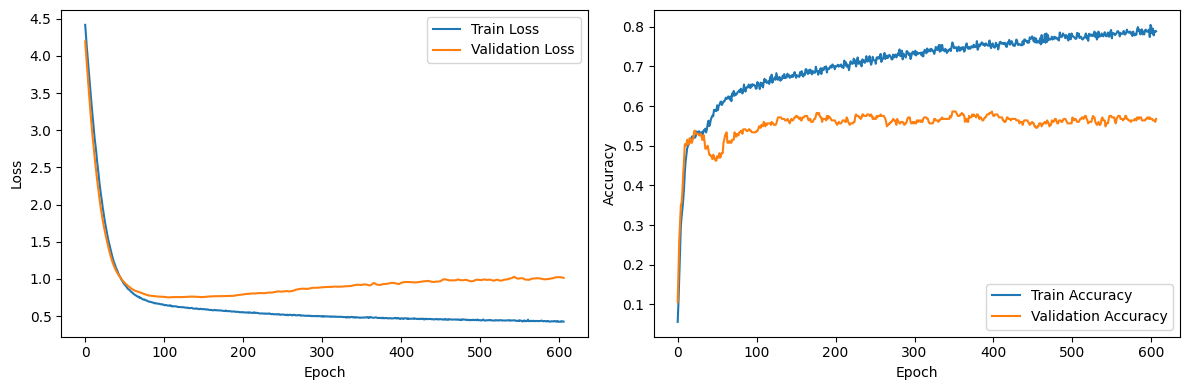


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5396, Val Loss: 3.5166, Train Acc: 0.2844, Val Acc: 0.2980
Epoch: 020, Train Loss: 2.3452, Val Loss: 2.3983, Train Acc: 0.5428, Val Acc: 0.4549
Epoch: 030, Train Loss: 1.6147, Val Loss: 1.6599, Train Acc: 0.5789, Val Acc: 0.4824
Epoch: 040, Train Loss: 1.1711, Val Loss: 1.2250, Train Acc: 0.5822, Val Acc: 0.4784
Epoch: 050, Train Loss: 0.9458, Val Loss: 1.0161, Train Acc: 0.6057, Val Acc: 0.4941
Epoch: 060, Train Loss: 0.8377, Val Loss: 0.9060, Train Acc: 0.6023, Val Acc: 0.4941
Epoch: 070, Train Loss: 0.7655, Val Loss: 0.8457, Train Acc: 0.6116, Val Acc: 0.4824
Epoch: 080, Train Loss: 0.7284, Val Loss: 0.7868, Train Acc: 0.6166, Val Acc: 0.5059
Epoch: 090, Train Loss: 0.6770, Val Loss: 0.7712, Train Acc: 0.6477, Val Acc: 0.5176
Epoch: 100, Train Loss: 0.6565, Val Loss: 0.7548, Train Acc: 0.6661, Val Acc: 0.5216
Epoch: 110, Train Loss: 0.6341, Val Loss: 0.7408, Tr

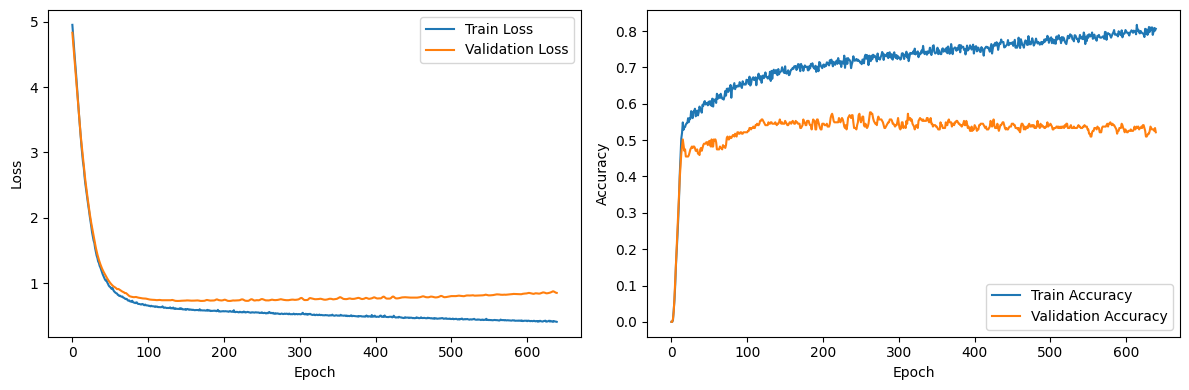


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5699, Val Loss: 3.4230, Train Acc: 0.2350, Val Acc: 0.3008
Epoch: 020, Train Loss: 2.4089, Val Loss: 2.3295, Train Acc: 0.4637, Val Acc: 0.5297
Epoch: 030, Train Loss: 1.7062, Val Loss: 1.6851, Train Acc: 0.5254, Val Acc: 0.5254
Epoch: 040, Train Loss: 1.2619, Val Loss: 1.2756, Train Acc: 0.5136, Val Acc: 0.5254
Epoch: 050, Train Loss: 1.0290, Val Loss: 1.0621, Train Acc: 0.5490, Val Acc: 0.5000
Epoch: 060, Train Loss: 0.9071, Val Loss: 0.9239, Train Acc: 0.5535, Val Acc: 0.5593
Epoch: 070, Train Loss: 0.8214, Val Loss: 0.8468, Train Acc: 0.5926, Val Acc: 0.5551
Epoch: 080, Train Loss: 0.7541, Val Loss: 0.7969, Train Acc: 0.6171, Val Acc: 0.5339
Epoch: 090, Train Loss: 0.7106, Val Loss: 0.7653, Train Acc: 0.6588, Val Acc: 0.5381
Epoch: 100, Train Loss: 0.6988, Val Loss: 0.7511, Train Acc: 0.6397, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.6712, Val Loss: 0.7293, Tr

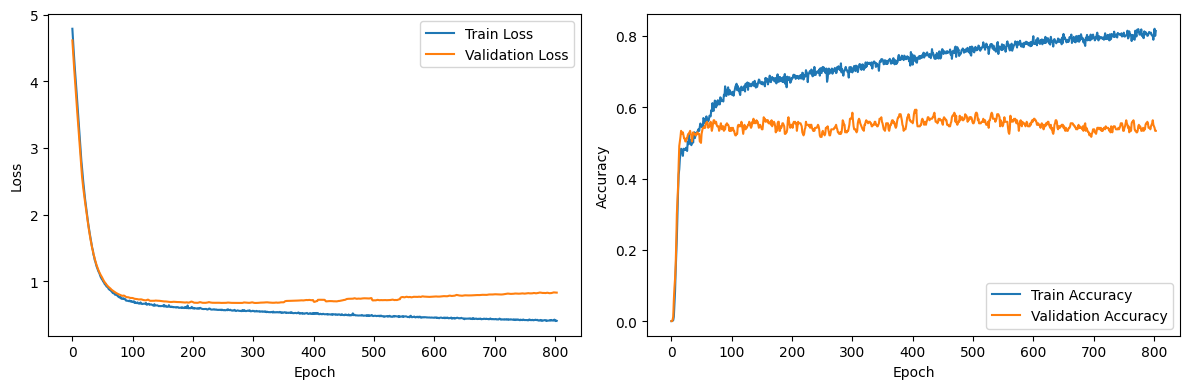


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1921, Val Loss: 2.9381, Train Acc: 0.4163, Val Acc: 0.5367
Epoch: 020, Train Loss: 2.2240, Val Loss: 2.0412, Train Acc: 0.4951, Val Acc: 0.5550
Epoch: 030, Train Loss: 1.5241, Val Loss: 1.4220, Train Acc: 0.5344, Val Acc: 0.5505
Epoch: 040, Train Loss: 1.1787, Val Loss: 1.0963, Train Acc: 0.5305, Val Acc: 0.5505
Epoch: 050, Train Loss: 0.9632, Val Loss: 0.9323, Train Acc: 0.5591, Val Acc: 0.5642
Epoch: 060, Train Loss: 0.8555, Val Loss: 0.8430, Train Acc: 0.5640, Val Acc: 0.5642
Epoch: 070, Train Loss: 0.7820, Val Loss: 0.8100, Train Acc: 0.5965, Val Acc: 0.5688
Epoch: 080, Train Loss: 0.7244, Val Loss: 0.7641, Train Acc: 0.6211, Val Acc: 0.5459
Epoch: 090, Train Loss: 0.7009, Val Loss: 0.7444, Train Acc: 0.6171, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6695, Val Loss: 0.7351, Train Acc: 0.6437, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6579, Val Loss: 0.7318, Tr

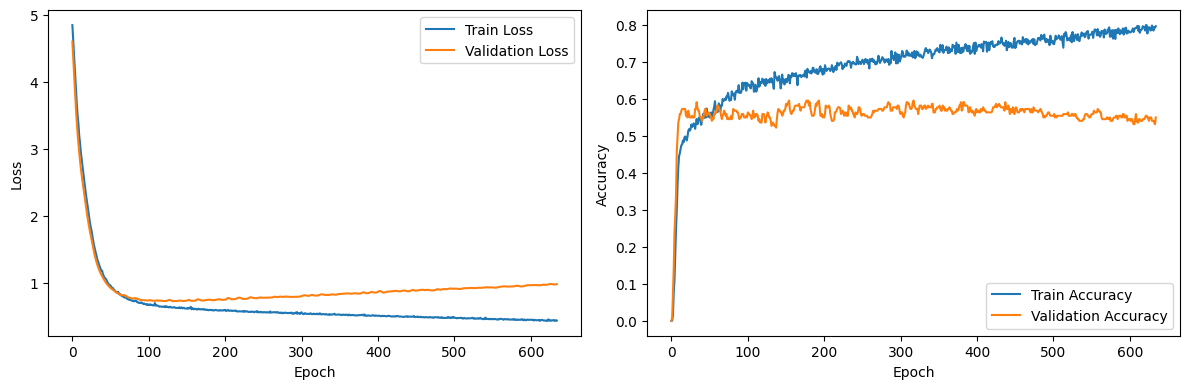


========== Run 15 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5890, Val Loss: 3.3783, Train Acc: 0.3691, Val Acc: 0.4135
Epoch: 020, Train Loss: 2.4682, Val Loss: 2.2853, Train Acc: 0.5044, Val Acc: 0.4887
Epoch: 030, Train Loss: 1.7444, Val Loss: 1.6497, Train Acc: 0.5157, Val Acc: 0.4586
Epoch: 040, Train Loss: 1.2965, Val Loss: 1.2519, Train Acc: 0.5359, Val Acc: 0.4774
Epoch: 050, Train Loss: 1.0429, Val Loss: 1.0449, Train Acc: 0.5528, Val Acc: 0.5038
Epoch: 060, Train Loss: 0.8947, Val Loss: 0.9328, Train Acc: 0.5923, Val Acc: 0.5038
Epoch: 070, Train Loss: 0.8016, Val Loss: 0.8490, Train Acc: 0.6011, Val Acc: 0.5489
Epoch: 080, Train Loss: 0.7405, Val Loss: 0.7903, Train Acc: 0.6189, Val Acc: 0.5902
Epoch: 090, Train Loss: 0.7122, Val Loss: 0.7716, Train Acc: 0.6180, Val Acc: 0.5940
Epoch: 100, Train Loss: 0.6788, Val Loss: 0.7562, Train Acc: 0.6366, Val Acc: 0.6015
Epoch: 110, Train Los

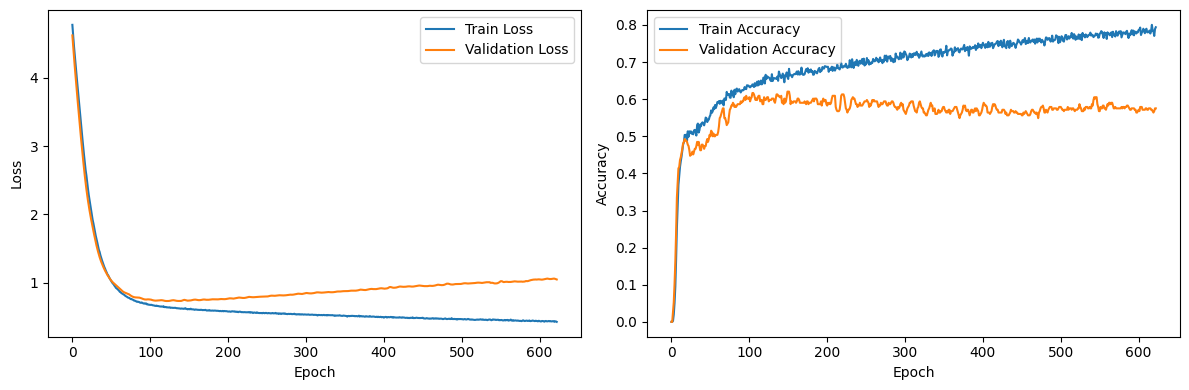


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0644, Val Loss: 2.9505, Train Acc: 0.4446, Val Acc: 0.5020
Epoch: 020, Train Loss: 2.1375, Val Loss: 2.0622, Train Acc: 0.5285, Val Acc: 0.5020
Epoch: 030, Train Loss: 1.4830, Val Loss: 1.4978, Train Acc: 0.5747, Val Acc: 0.4745
Epoch: 040, Train Loss: 1.1385, Val Loss: 1.1713, Train Acc: 0.5780, Val Acc: 0.4824
Epoch: 050, Train Loss: 0.9566, Val Loss: 0.9910, Train Acc: 0.5940, Val Acc: 0.4980
Epoch: 060, Train Loss: 0.8434, Val Loss: 0.8925, Train Acc: 0.6174, Val Acc: 0.5451
Epoch: 070, Train Loss: 0.7654, Val Loss: 0.8444, Train Acc: 0.6200, Val Acc: 0.5529
Epoch: 080, Train Loss: 0.7103, Val Loss: 0.7932, Train Acc: 0.6367, Val Acc: 0.5490
Epoch: 090, Train Loss: 0.6801, Val Loss: 0.7587, Train Acc: 0.6443, Val Acc: 0.5451
Epoch: 100, Train Loss: 0.6679, Val Loss: 0.7547, Train Acc: 0.6653, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.6392, Val Loss: 0.7376, Tr

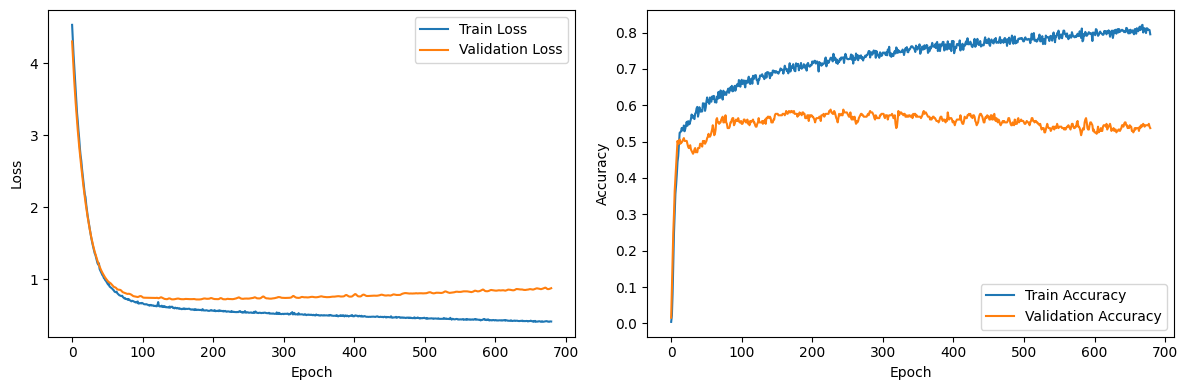


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9903, Val Loss: 2.9078, Train Acc: 0.4428, Val Acc: 0.4576
Epoch: 020, Train Loss: 2.0815, Val Loss: 2.0815, Train Acc: 0.5154, Val Acc: 0.4915
Epoch: 030, Train Loss: 1.4585, Val Loss: 1.5024, Train Acc: 0.5408, Val Acc: 0.4788
Epoch: 040, Train Loss: 1.1057, Val Loss: 1.1622, Train Acc: 0.5662, Val Acc: 0.5127
Epoch: 050, Train Loss: 0.9220, Val Loss: 0.9820, Train Acc: 0.5880, Val Acc: 0.5169
Epoch: 060, Train Loss: 0.8172, Val Loss: 0.8854, Train Acc: 0.5989, Val Acc: 0.5254
Epoch: 070, Train Loss: 0.7512, Val Loss: 0.8251, Train Acc: 0.6162, Val Acc: 0.5466
Epoch: 080, Train Loss: 0.7126, Val Loss: 0.7839, Train Acc: 0.6289, Val Acc: 0.5254
Epoch: 090, Train Loss: 0.6854, Val Loss: 0.7654, Train Acc: 0.6479, Val Acc: 0.5636
Epoch: 100, Train Loss: 0.6711, Val Loss: 0.7476, Train Acc: 0.6425, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6505, Val Loss: 0.7362, Tr

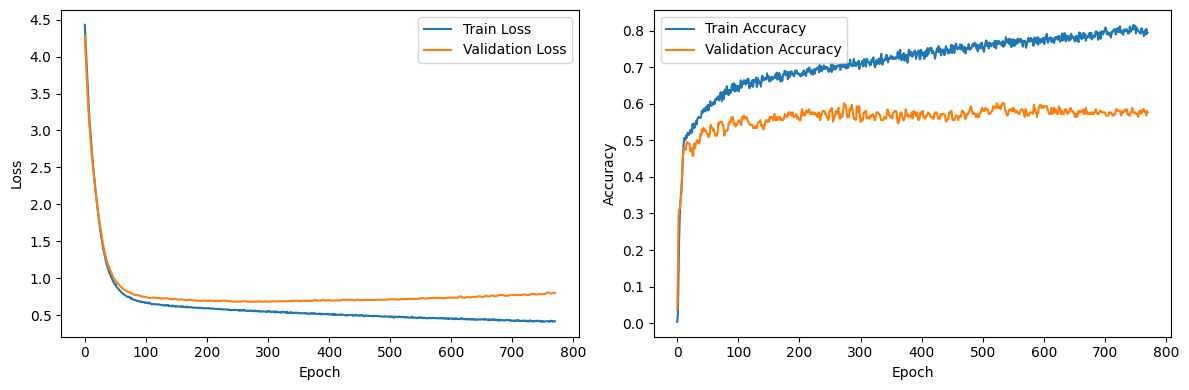


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4209, Val Loss: 3.2788, Train Acc: 0.3189, Val Acc: 0.3486
Epoch: 020, Train Loss: 2.4230, Val Loss: 2.3103, Train Acc: 0.5443, Val Acc: 0.4908
Epoch: 030, Train Loss: 1.6953, Val Loss: 1.6485, Train Acc: 0.5423, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.2714, Val Loss: 1.2155, Train Acc: 0.5561, Val Acc: 0.5046
Epoch: 050, Train Loss: 1.0145, Val Loss: 1.0046, Train Acc: 0.5846, Val Acc: 0.5413
Epoch: 060, Train Loss: 0.8740, Val Loss: 0.8884, Train Acc: 0.6220, Val Acc: 0.5550
Epoch: 070, Train Loss: 0.8031, Val Loss: 0.8365, Train Acc: 0.5974, Val Acc: 0.5229
Epoch: 080, Train Loss: 0.7473, Val Loss: 0.7926, Train Acc: 0.6240, Val Acc: 0.5688
Epoch: 090, Train Loss: 0.7113, Val Loss: 0.7784, Train Acc: 0.6309, Val Acc: 0.5550
Epoch: 100, Train Loss: 0.7043, Val Loss: 0.7613, Train Acc: 0.6211, Val Acc: 0.5734
Epoch: 110, Train Loss: 0.6987, Val Loss: 0.7520, Tr

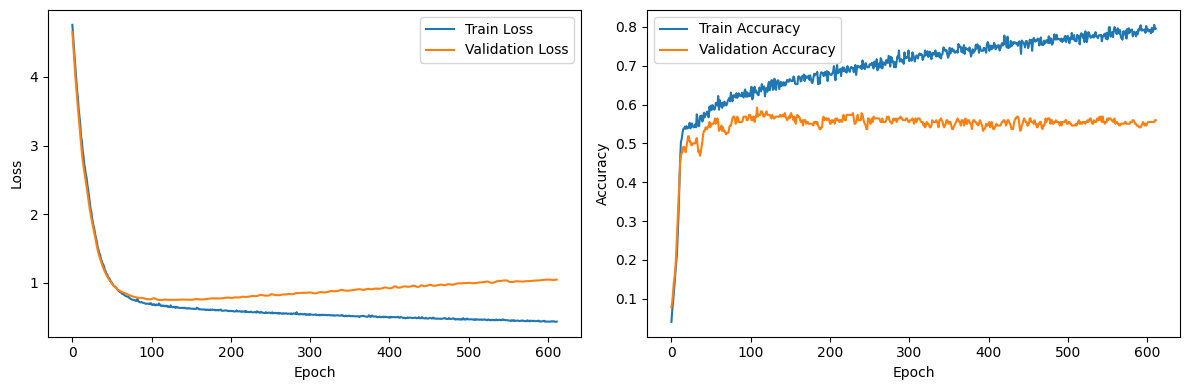


========== Run 16 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2186, Val Loss: 2.9448, Train Acc: 0.5173, Val Acc: 0.5677
Epoch: 020, Train Loss: 2.1001, Val Loss: 1.9067, Train Acc: 0.5270, Val Acc: 0.5263
Epoch: 030, Train Loss: 1.4361, Val Loss: 1.3321, Train Acc: 0.5616, Val Acc: 0.5489
Epoch: 040, Train Loss: 1.0743, Val Loss: 1.0401, Train Acc: 0.5931, Val Acc: 0.5564
Epoch: 050, Train Loss: 0.8894, Val Loss: 0.8968, Train Acc: 0.5866, Val Acc: 0.5752
Epoch: 060, Train Loss: 0.7876, Val Loss: 0.8220, Train Acc: 0.6100, Val Acc: 0.5752
Epoch: 070, Train Loss: 0.7254, Val Loss: 0.7814, Train Acc: 0.6398, Val Acc: 0.5902
Epoch: 080, Train Loss: 0.6875, Val Loss: 0.7562, Train Acc: 0.6406, Val Acc: 0.5865
Epoch: 090, Train Loss: 0.6713, Val Loss: 0.7487, Train Acc: 0.6527, Val Acc: 0.5977
Epoch: 100, Train Loss: 0.6546, Val Loss: 0.7478, Train Acc: 0.6535, Val Acc: 0.5865
Epoch: 110, Train Los

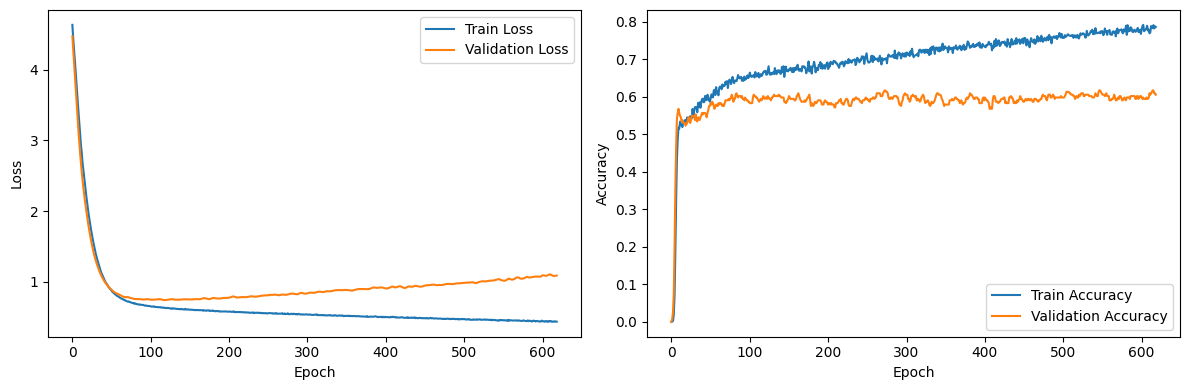


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4248, Val Loss: 3.3659, Train Acc: 0.3784, Val Acc: 0.4039
Epoch: 020, Train Loss: 2.2082, Val Loss: 2.2110, Train Acc: 0.5545, Val Acc: 0.4980
Epoch: 030, Train Loss: 1.4801, Val Loss: 1.5323, Train Acc: 0.5688, Val Acc: 0.5059
Epoch: 040, Train Loss: 1.0979, Val Loss: 1.1340, Train Acc: 0.5755, Val Acc: 0.5098
Epoch: 050, Train Loss: 0.9062, Val Loss: 0.9551, Train Acc: 0.6091, Val Acc: 0.4627
Epoch: 060, Train Loss: 0.8060, Val Loss: 0.8678, Train Acc: 0.6225, Val Acc: 0.4627
Epoch: 070, Train Loss: 0.7349, Val Loss: 0.8043, Train Acc: 0.6309, Val Acc: 0.5098
Epoch: 080, Train Loss: 0.7038, Val Loss: 0.7775, Train Acc: 0.6435, Val Acc: 0.5176
Epoch: 090, Train Loss: 0.6736, Val Loss: 0.7515, Train Acc: 0.6317, Val Acc: 0.5373
Epoch: 100, Train Loss: 0.6548, Val Loss: 0.7404, Train Acc: 0.6401, Val Acc: 0.5373
Epoch: 110, Train Loss: 0.6336, Val Loss: 0.7297, Tr

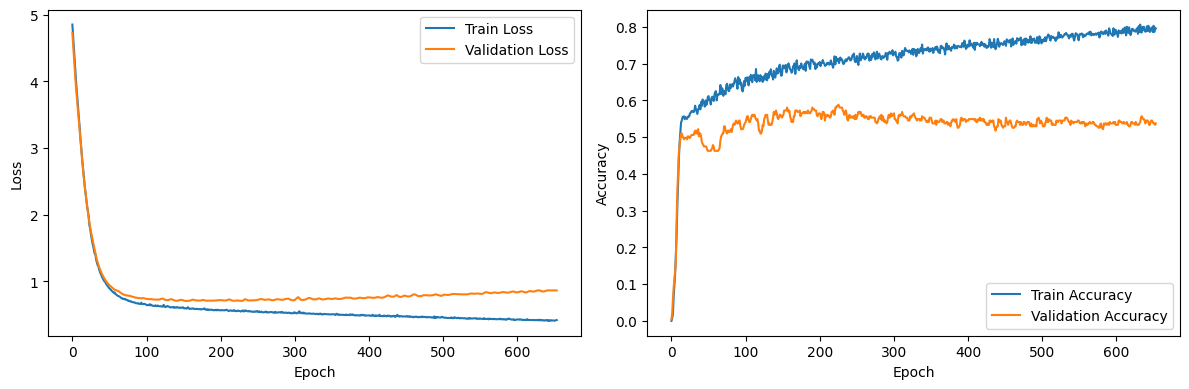


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2642, Val Loss: 3.1276, Train Acc: 0.4628, Val Acc: 0.5042
Epoch: 020, Train Loss: 2.1917, Val Loss: 2.1714, Train Acc: 0.5245, Val Acc: 0.5212
Epoch: 030, Train Loss: 1.5316, Val Loss: 1.5456, Train Acc: 0.5426, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.1300, Val Loss: 1.1786, Train Acc: 0.5662, Val Acc: 0.5339
Epoch: 050, Train Loss: 0.9356, Val Loss: 0.9830, Train Acc: 0.5817, Val Acc: 0.5720
Epoch: 060, Train Loss: 0.8241, Val Loss: 0.8713, Train Acc: 0.6007, Val Acc: 0.5466
Epoch: 070, Train Loss: 0.7553, Val Loss: 0.8156, Train Acc: 0.6252, Val Acc: 0.5636
Epoch: 080, Train Loss: 0.7088, Val Loss: 0.7829, Train Acc: 0.6343, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.6827, Val Loss: 0.7686, Train Acc: 0.6497, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.6723, Val Loss: 0.7561, Train Acc: 0.6352, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6524, Val Loss: 0.7362, Tr

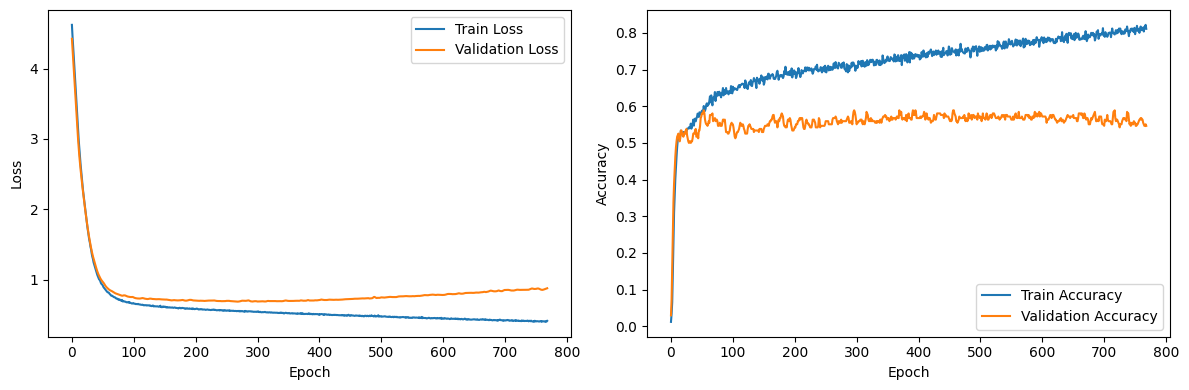


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3040, Val Loss: 3.1078, Train Acc: 0.3868, Val Acc: 0.4220
Epoch: 020, Train Loss: 2.1825, Val Loss: 2.0676, Train Acc: 0.5305, Val Acc: 0.4908
Epoch: 030, Train Loss: 1.5060, Val Loss: 1.4547, Train Acc: 0.5591, Val Acc: 0.4817
Epoch: 040, Train Loss: 1.1296, Val Loss: 1.1193, Train Acc: 0.5787, Val Acc: 0.5183
Epoch: 050, Train Loss: 0.9498, Val Loss: 0.9596, Train Acc: 0.5787, Val Acc: 0.5321
Epoch: 060, Train Loss: 0.8254, Val Loss: 0.8943, Train Acc: 0.5965, Val Acc: 0.5550
Epoch: 070, Train Loss: 0.7579, Val Loss: 0.8139, Train Acc: 0.6043, Val Acc: 0.5459
Epoch: 080, Train Loss: 0.7230, Val Loss: 0.7869, Train Acc: 0.6083, Val Acc: 0.5550
Epoch: 090, Train Loss: 0.6829, Val Loss: 0.7734, Train Acc: 0.6417, Val Acc: 0.5917
Epoch: 100, Train Loss: 0.6702, Val Loss: 0.7610, Train Acc: 0.6250, Val Acc: 0.5963
Epoch: 110, Train Loss: 0.6463, Val Loss: 0.7764, Tr

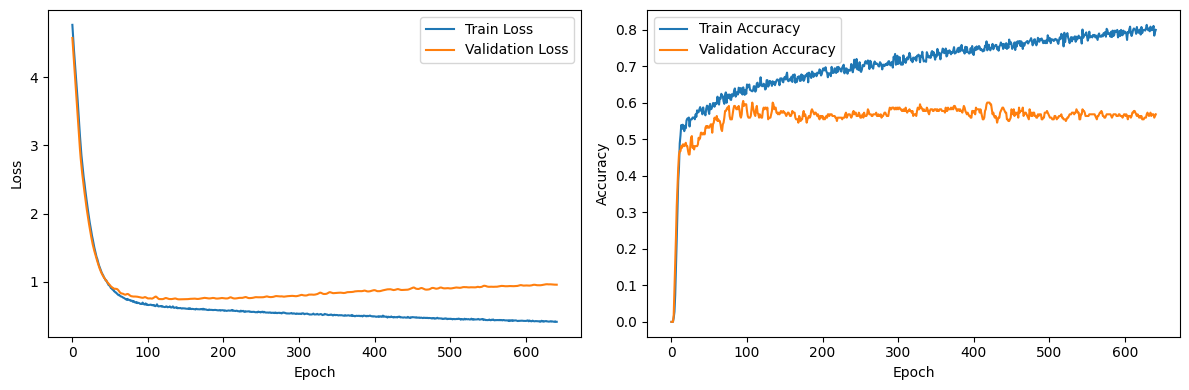


========== Run 17 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2730, Val Loss: 3.0600, Train Acc: 0.4867, Val Acc: 0.4737
Epoch: 020, Train Loss: 2.2528, Val Loss: 2.0510, Train Acc: 0.5189, Val Acc: 0.5150
Epoch: 030, Train Loss: 1.5827, Val Loss: 1.4764, Train Acc: 0.5294, Val Acc: 0.5188
Epoch: 040, Train Loss: 1.1816, Val Loss: 1.1353, Train Acc: 0.5512, Val Acc: 0.5113
Epoch: 050, Train Loss: 0.9542, Val Loss: 0.9618, Train Acc: 0.5729, Val Acc: 0.5451
Epoch: 060, Train Loss: 0.8338, Val Loss: 0.8609, Train Acc: 0.6035, Val Acc: 0.5526
Epoch: 070, Train Loss: 0.7591, Val Loss: 0.8094, Train Acc: 0.6035, Val Acc: 0.5677
Epoch: 080, Train Loss: 0.7150, Val Loss: 0.7633, Train Acc: 0.6180, Val Acc: 0.5977
Epoch: 090, Train Loss: 0.6842, Val Loss: 0.7456, Train Acc: 0.6189, Val Acc: 0.5977
Epoch: 100, Train Loss: 0.6664, Val Loss: 0.7272, Train Acc: 0.6269, Val Acc: 0.6090
Epoch: 110, Train Los

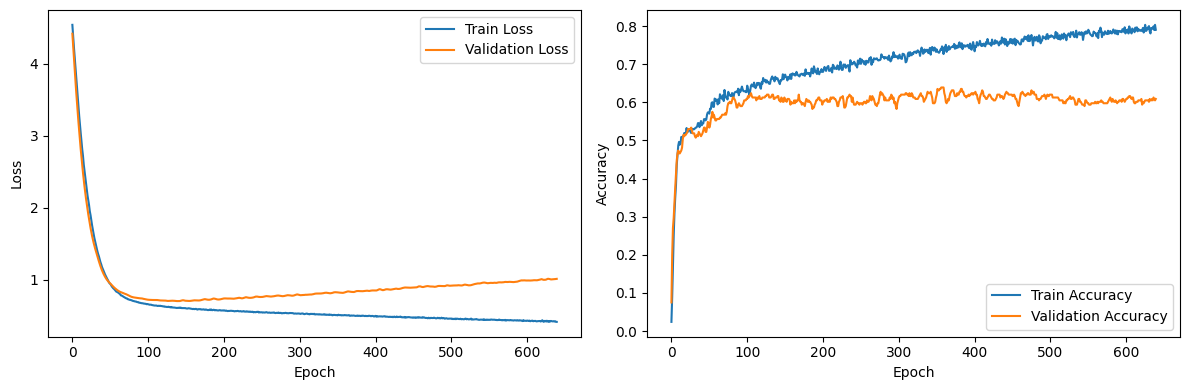


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3124, Val Loss: 3.2366, Train Acc: 0.4513, Val Acc: 0.4235
Epoch: 020, Train Loss: 2.1501, Val Loss: 2.1219, Train Acc: 0.5621, Val Acc: 0.4627
Epoch: 030, Train Loss: 1.4789, Val Loss: 1.5144, Train Acc: 0.5705, Val Acc: 0.4863
Epoch: 040, Train Loss: 1.1186, Val Loss: 1.1566, Train Acc: 0.5780, Val Acc: 0.4941
Epoch: 050, Train Loss: 0.9408, Val Loss: 0.9805, Train Acc: 0.5990, Val Acc: 0.5020
Epoch: 060, Train Loss: 0.8243, Val Loss: 0.8871, Train Acc: 0.6242, Val Acc: 0.5333
Epoch: 070, Train Loss: 0.7528, Val Loss: 0.8183, Train Acc: 0.6409, Val Acc: 0.5765
Epoch: 080, Train Loss: 0.7152, Val Loss: 0.7821, Train Acc: 0.6535, Val Acc: 0.5686
Epoch: 090, Train Loss: 0.6695, Val Loss: 0.7620, Train Acc: 0.6569, Val Acc: 0.5804
Epoch: 100, Train Loss: 0.6605, Val Loss: 0.7414, Train Acc: 0.6485, Val Acc: 0.5765
Epoch: 110, Train Loss: 0.6278, Val Loss: 0.7282, Tr

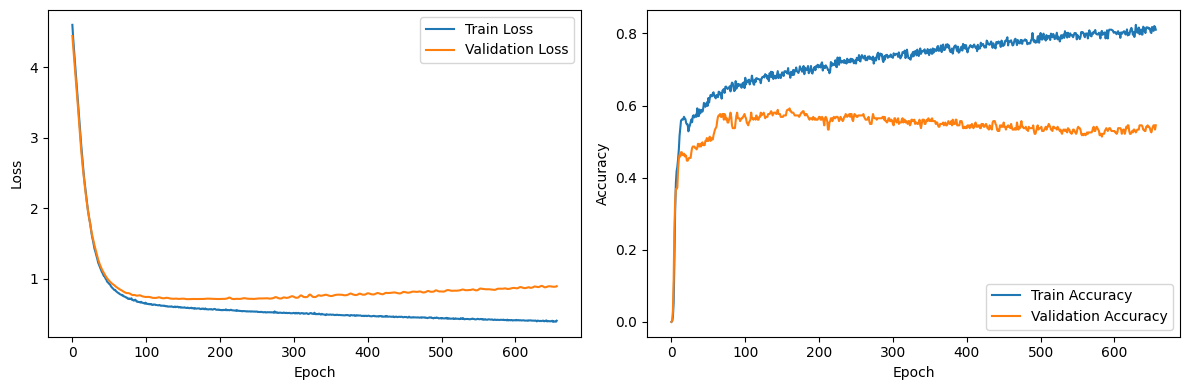


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5714, Val Loss: 3.4586, Train Acc: 0.4229, Val Acc: 0.3856
Epoch: 020, Train Loss: 2.4519, Val Loss: 2.4059, Train Acc: 0.5753, Val Acc: 0.4831
Epoch: 030, Train Loss: 1.5927, Val Loss: 1.5918, Train Acc: 0.5862, Val Acc: 0.5127
Epoch: 040, Train Loss: 1.1890, Val Loss: 1.2271, Train Acc: 0.5953, Val Acc: 0.5169
Epoch: 050, Train Loss: 0.9961, Val Loss: 1.0331, Train Acc: 0.5880, Val Acc: 0.5212
Epoch: 060, Train Loss: 0.8785, Val Loss: 0.9200, Train Acc: 0.6125, Val Acc: 0.5381
Epoch: 070, Train Loss: 0.8004, Val Loss: 0.8586, Train Acc: 0.6152, Val Acc: 0.5636
Epoch: 080, Train Loss: 0.7520, Val Loss: 0.8055, Train Acc: 0.6171, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.7148, Val Loss: 0.7648, Train Acc: 0.6207, Val Acc: 0.5593
Epoch: 100, Train Loss: 0.6851, Val Loss: 0.7440, Train Acc: 0.6370, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6711, Val Loss: 0.7267, Tr

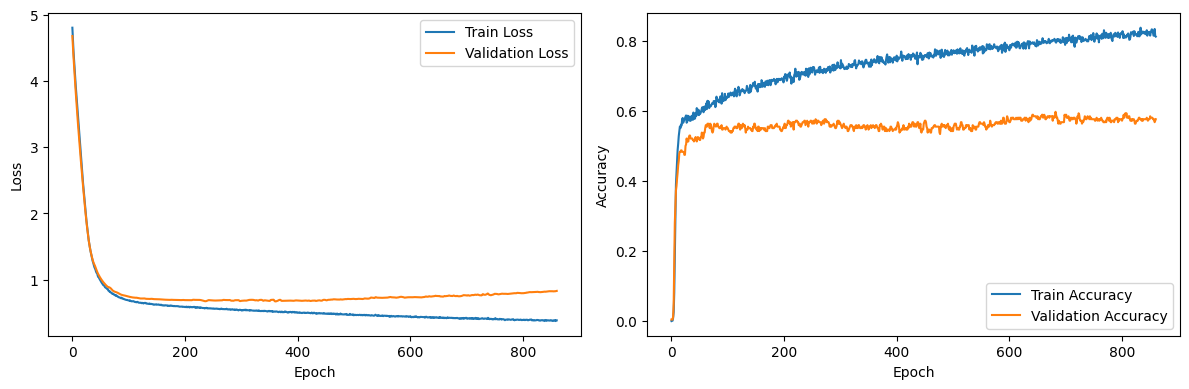


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2853, Val Loss: 3.1365, Train Acc: 0.5118, Val Acc: 0.4633
Epoch: 020, Train Loss: 2.1007, Val Loss: 2.0448, Train Acc: 0.5246, Val Acc: 0.4771
Epoch: 030, Train Loss: 1.4187, Val Loss: 1.3996, Train Acc: 0.5433, Val Acc: 0.4771
Epoch: 040, Train Loss: 1.0863, Val Loss: 1.0963, Train Acc: 0.5600, Val Acc: 0.4771
Epoch: 050, Train Loss: 0.9192, Val Loss: 0.9361, Train Acc: 0.5915, Val Acc: 0.4908
Epoch: 060, Train Loss: 0.8022, Val Loss: 0.8598, Train Acc: 0.6063, Val Acc: 0.4771
Epoch: 070, Train Loss: 0.7484, Val Loss: 0.8210, Train Acc: 0.6033, Val Acc: 0.5367
Epoch: 080, Train Loss: 0.7144, Val Loss: 0.7874, Train Acc: 0.5994, Val Acc: 0.5229
Epoch: 090, Train Loss: 0.6821, Val Loss: 0.7782, Train Acc: 0.6161, Val Acc: 0.5413
Epoch: 100, Train Loss: 0.6630, Val Loss: 0.7643, Train Acc: 0.6398, Val Acc: 0.5367
Epoch: 110, Train Loss: 0.6452, Val Loss: 0.7668, Tr

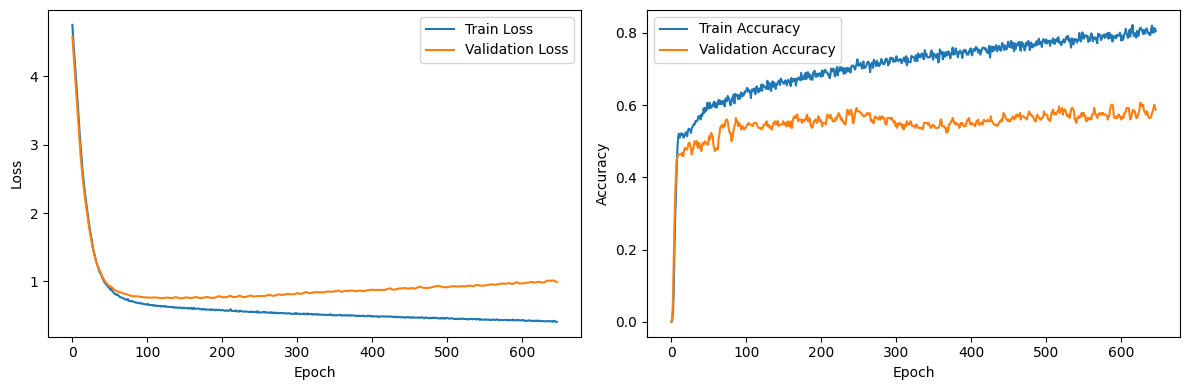


========== Run 18 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4570, Val Loss: 3.2353, Train Acc: 0.4891, Val Acc: 0.5000
Epoch: 020, Train Loss: 2.3632, Val Loss: 2.1931, Train Acc: 0.5657, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.6104, Val Loss: 1.4896, Train Acc: 0.5794, Val Acc: 0.5526
Epoch: 040, Train Loss: 1.1910, Val Loss: 1.1549, Train Acc: 0.5770, Val Acc: 0.5376
Epoch: 050, Train Loss: 0.9594, Val Loss: 0.9601, Train Acc: 0.5923, Val Acc: 0.5414
Epoch: 060, Train Loss: 0.8345, Val Loss: 0.8728, Train Acc: 0.6180, Val Acc: 0.5376
Epoch: 070, Train Loss: 0.7461, Val Loss: 0.8252, Train Acc: 0.6503, Val Acc: 0.5338
Epoch: 080, Train Loss: 0.7053, Val Loss: 0.7900, Train Acc: 0.6463, Val Acc: 0.5489
Epoch: 090, Train Loss: 0.6696, Val Loss: 0.7643, Train Acc: 0.6519, Val Acc: 0.5639
Epoch: 100, Train Loss: 0.6519, Val Loss: 0.7717, Train Acc: 0.6543, Val Acc: 0.5489
Epoch: 110, Train Los

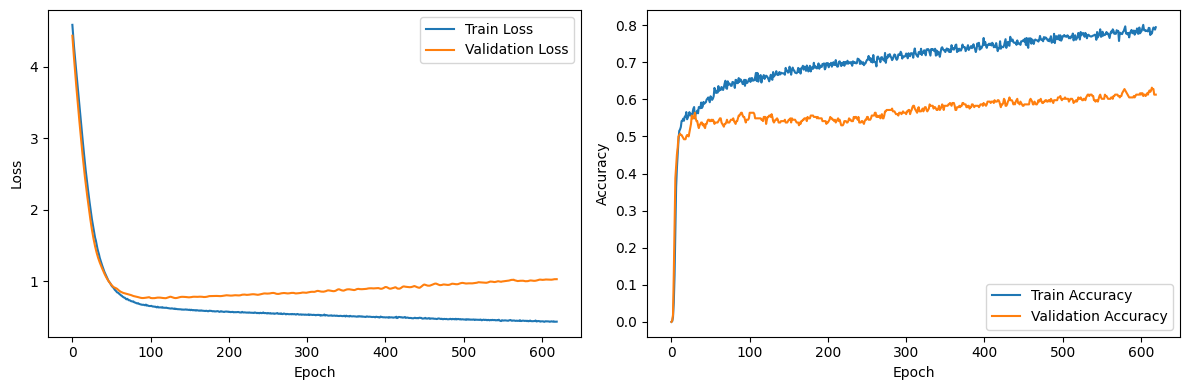


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2539, Val Loss: 3.1890, Train Acc: 0.4690, Val Acc: 0.4824
Epoch: 020, Train Loss: 2.2218, Val Loss: 2.2321, Train Acc: 0.5453, Val Acc: 0.4824
Epoch: 030, Train Loss: 1.5478, Val Loss: 1.5647, Train Acc: 0.5587, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.1622, Val Loss: 1.1803, Train Acc: 0.5663, Val Acc: 0.5137
Epoch: 050, Train Loss: 0.9522, Val Loss: 0.9866, Train Acc: 0.5973, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.8321, Val Loss: 0.8663, Train Acc: 0.6091, Val Acc: 0.5373
Epoch: 070, Train Loss: 0.7568, Val Loss: 0.7969, Train Acc: 0.6284, Val Acc: 0.5686
Epoch: 080, Train Loss: 0.7204, Val Loss: 0.7602, Train Acc: 0.6502, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6832, Val Loss: 0.7523, Train Acc: 0.6602, Val Acc: 0.5608
Epoch: 100, Train Loss: 0.6683, Val Loss: 0.7185, Train Acc: 0.6577, Val Acc: 0.5922
Epoch: 110, Train Loss: 0.6387, Val Loss: 0.7144, Tr

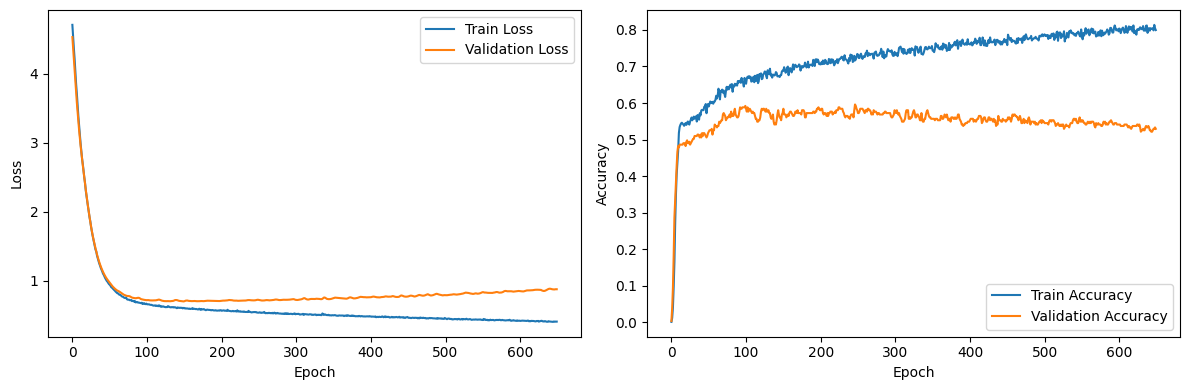


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3702, Val Loss: 3.2479, Train Acc: 0.4229, Val Acc: 0.4195
Epoch: 020, Train Loss: 2.2878, Val Loss: 2.2786, Train Acc: 0.5136, Val Acc: 0.4831
Epoch: 030, Train Loss: 1.6183, Val Loss: 1.6450, Train Acc: 0.5236, Val Acc: 0.5254
Epoch: 040, Train Loss: 1.1871, Val Loss: 1.2082, Train Acc: 0.5436, Val Acc: 0.5339
Epoch: 050, Train Loss: 0.9768, Val Loss: 1.0101, Train Acc: 0.5708, Val Acc: 0.5297
Epoch: 060, Train Loss: 0.8472, Val Loss: 0.8845, Train Acc: 0.5880, Val Acc: 0.5169
Epoch: 070, Train Loss: 0.7726, Val Loss: 0.8274, Train Acc: 0.6116, Val Acc: 0.5508
Epoch: 080, Train Loss: 0.7207, Val Loss: 0.7815, Train Acc: 0.6261, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.7039, Val Loss: 0.7545, Train Acc: 0.6116, Val Acc: 0.5508
Epoch: 100, Train Loss: 0.6830, Val Loss: 0.7427, Train Acc: 0.6307, Val Acc: 0.5720
Epoch: 110, Train Loss: 0.6578, Val Loss: 0.7181, Tr

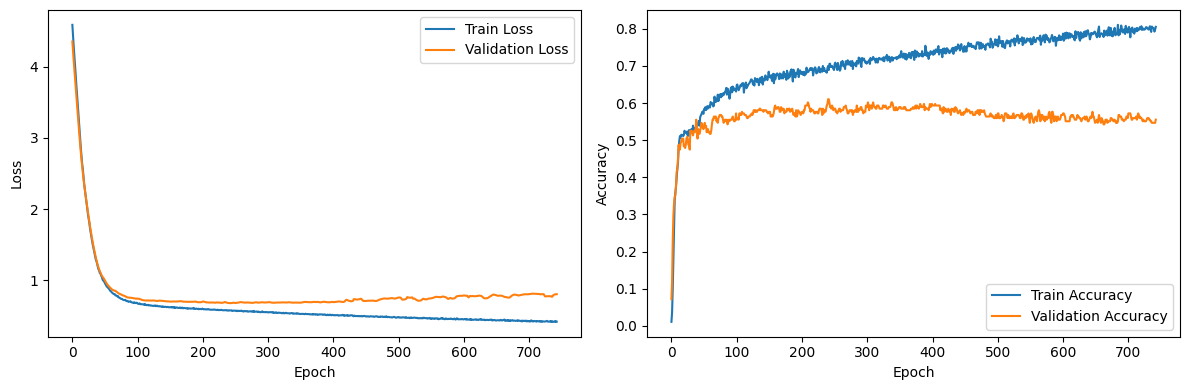


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3493, Val Loss: 3.1860, Train Acc: 0.4055, Val Acc: 0.4450
Epoch: 020, Train Loss: 2.2321, Val Loss: 2.1374, Train Acc: 0.5089, Val Acc: 0.4725
Epoch: 030, Train Loss: 1.5338, Val Loss: 1.4751, Train Acc: 0.5394, Val Acc: 0.4404
Epoch: 040, Train Loss: 1.1528, Val Loss: 1.1211, Train Acc: 0.5492, Val Acc: 0.4908
Epoch: 050, Train Loss: 0.9542, Val Loss: 0.9557, Train Acc: 0.5886, Val Acc: 0.4862
Epoch: 060, Train Loss: 0.8404, Val Loss: 0.8770, Train Acc: 0.5896, Val Acc: 0.4817
Epoch: 070, Train Loss: 0.7665, Val Loss: 0.8177, Train Acc: 0.6043, Val Acc: 0.5138
Epoch: 080, Train Loss: 0.7220, Val Loss: 0.7958, Train Acc: 0.6240, Val Acc: 0.5275
Epoch: 090, Train Loss: 0.6951, Val Loss: 0.7710, Train Acc: 0.6152, Val Acc: 0.5275
Epoch: 100, Train Loss: 0.6674, Val Loss: 0.7486, Train Acc: 0.6339, Val Acc: 0.5183
Epoch: 110, Train Loss: 0.6538, Val Loss: 0.7732, Tr

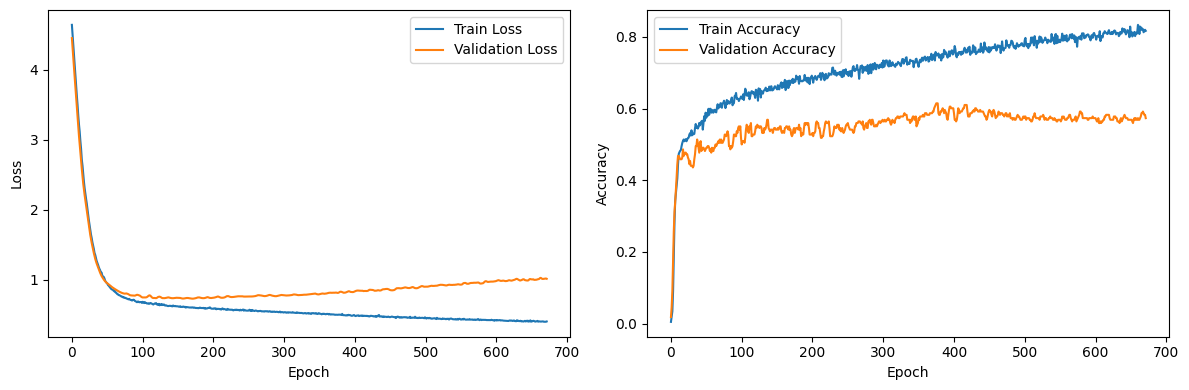


========== Run 19 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.7345, Val Loss: 3.4734, Train Acc: 0.2965, Val Acc: 0.3910
Epoch: 020, Train Loss: 2.5294, Val Loss: 2.2983, Train Acc: 0.5133, Val Acc: 0.5188
Epoch: 030, Train Loss: 1.7719, Val Loss: 1.6125, Train Acc: 0.5262, Val Acc: 0.5451
Epoch: 040, Train Loss: 1.3007, Val Loss: 1.2196, Train Acc: 0.5576, Val Acc: 0.5263
Epoch: 050, Train Loss: 1.0402, Val Loss: 1.0046, Train Acc: 0.5649, Val Acc: 0.5301
Epoch: 060, Train Loss: 0.8815, Val Loss: 0.8771, Train Acc: 0.6068, Val Acc: 0.5789
Epoch: 070, Train Loss: 0.7889, Val Loss: 0.8205, Train Acc: 0.6156, Val Acc: 0.5789
Epoch: 080, Train Loss: 0.7386, Val Loss: 0.7744, Train Acc: 0.6197, Val Acc: 0.5940
Epoch: 090, Train Loss: 0.6976, Val Loss: 0.7535, Train Acc: 0.6350, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6723, Val Loss: 0.7390, Train Acc: 0.6334, Val Acc: 0.5902
Epoch: 110, Train Los

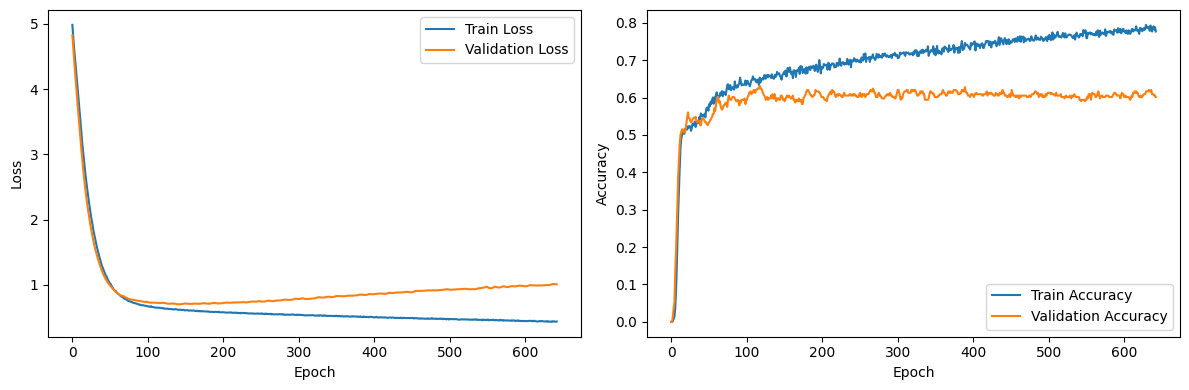


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4214, Val Loss: 3.3079, Train Acc: 0.3322, Val Acc: 0.3647
Epoch: 020, Train Loss: 2.2286, Val Loss: 2.1954, Train Acc: 0.5814, Val Acc: 0.5137
Epoch: 030, Train Loss: 1.5048, Val Loss: 1.5127, Train Acc: 0.5898, Val Acc: 0.5294
Epoch: 040, Train Loss: 1.1213, Val Loss: 1.1512, Train Acc: 0.6191, Val Acc: 0.5098
Epoch: 050, Train Loss: 0.9286, Val Loss: 0.9594, Train Acc: 0.6275, Val Acc: 0.5294
Epoch: 060, Train Loss: 0.8142, Val Loss: 0.8646, Train Acc: 0.6342, Val Acc: 0.5255
Epoch: 070, Train Loss: 0.7462, Val Loss: 0.8065, Train Acc: 0.6485, Val Acc: 0.5333
Epoch: 080, Train Loss: 0.7058, Val Loss: 0.7746, Train Acc: 0.6477, Val Acc: 0.5451
Epoch: 090, Train Loss: 0.6754, Val Loss: 0.7590, Train Acc: 0.6653, Val Acc: 0.5490
Epoch: 100, Train Loss: 0.6500, Val Loss: 0.7586, Train Acc: 0.6686, Val Acc: 0.5373
Epoch: 110, Train Loss: 0.6279, Val Loss: 0.7393, Tr

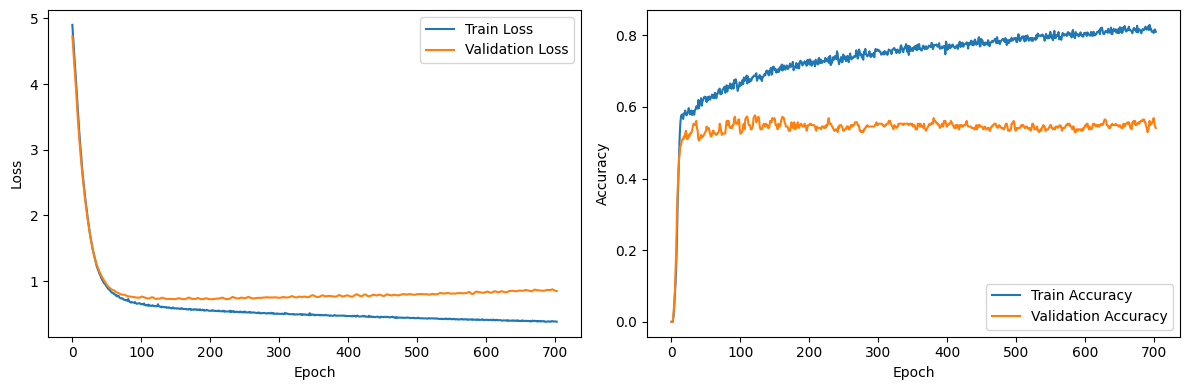


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1944, Val Loss: 3.0912, Train Acc: 0.3947, Val Acc: 0.4237
Epoch: 020, Train Loss: 2.1574, Val Loss: 2.2070, Train Acc: 0.4936, Val Acc: 0.4492
Epoch: 030, Train Loss: 1.5012, Val Loss: 1.5717, Train Acc: 0.5091, Val Acc: 0.4703
Epoch: 040, Train Loss: 1.1327, Val Loss: 1.2108, Train Acc: 0.5472, Val Acc: 0.4915
Epoch: 050, Train Loss: 0.9519, Val Loss: 1.0177, Train Acc: 0.5844, Val Acc: 0.5212
Epoch: 060, Train Loss: 0.8389, Val Loss: 0.8879, Train Acc: 0.6180, Val Acc: 0.5466
Epoch: 070, Train Loss: 0.7688, Val Loss: 0.8279, Train Acc: 0.6261, Val Acc: 0.5466
Epoch: 080, Train Loss: 0.7233, Val Loss: 0.7833, Train Acc: 0.6397, Val Acc: 0.5424
Epoch: 090, Train Loss: 0.6924, Val Loss: 0.7505, Train Acc: 0.6407, Val Acc: 0.5551
Epoch: 100, Train Loss: 0.6712, Val Loss: 0.7487, Train Acc: 0.6352, Val Acc: 0.5508
Epoch: 110, Train Loss: 0.6530, Val Loss: 0.7303, Tr

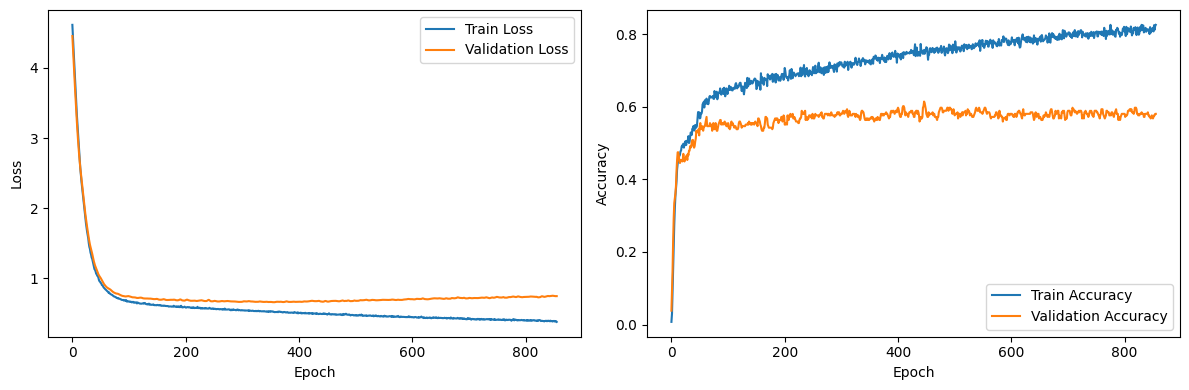


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5663, Val Loss: 3.3308, Train Acc: 0.3553, Val Acc: 0.3945
Epoch: 020, Train Loss: 2.3903, Val Loss: 2.2163, Train Acc: 0.5079, Val Acc: 0.5092
Epoch: 030, Train Loss: 1.7236, Val Loss: 1.6074, Train Acc: 0.5246, Val Acc: 0.5183
Epoch: 040, Train Loss: 1.3203, Val Loss: 1.2656, Train Acc: 0.5413, Val Acc: 0.5046
Epoch: 050, Train Loss: 1.0979, Val Loss: 1.0760, Train Acc: 0.5541, Val Acc: 0.4908
Epoch: 060, Train Loss: 0.9312, Val Loss: 0.9570, Train Acc: 0.5866, Val Acc: 0.4954
Epoch: 070, Train Loss: 0.8339, Val Loss: 0.8701, Train Acc: 0.5787, Val Acc: 0.5183
Epoch: 080, Train Loss: 0.7646, Val Loss: 0.8121, Train Acc: 0.5984, Val Acc: 0.5413
Epoch: 090, Train Loss: 0.7160, Val Loss: 0.7870, Train Acc: 0.6250, Val Acc: 0.5138
Epoch: 100, Train Loss: 0.6873, Val Loss: 0.7645, Train Acc: 0.6211, Val Acc: 0.5275
Epoch: 110, Train Loss: 0.6632, Val Loss: 0.7473, Tr

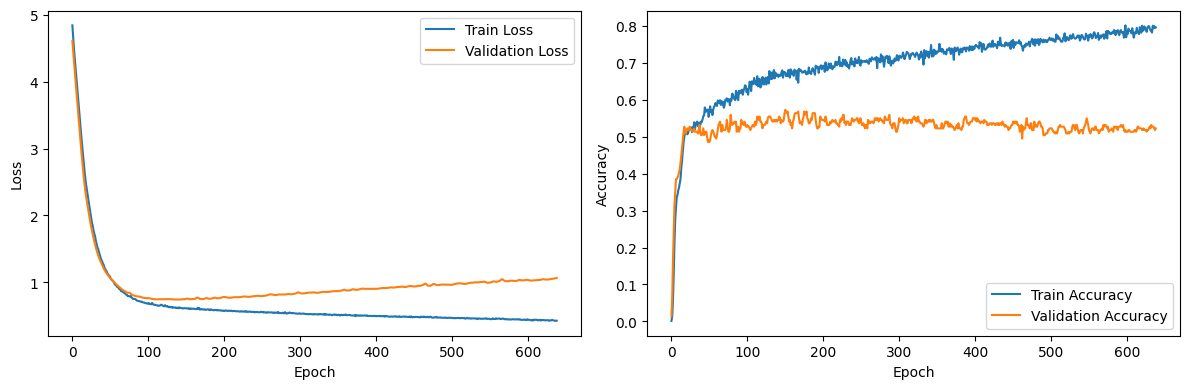


========== Run 20 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.8515, Val Loss: 2.5968, Train Acc: 0.5157, Val Acc: 0.5940
Epoch: 020, Train Loss: 1.9112, Val Loss: 1.7381, Train Acc: 0.5367, Val Acc: 0.5714
Epoch: 030, Train Loss: 1.3325, Val Loss: 1.2512, Train Acc: 0.5673, Val Acc: 0.5789
Epoch: 040, Train Loss: 1.0237, Val Loss: 1.0165, Train Acc: 0.5810, Val Acc: 0.5865
Epoch: 050, Train Loss: 0.8662, Val Loss: 0.9030, Train Acc: 0.5907, Val Acc: 0.5526
Epoch: 060, Train Loss: 0.7752, Val Loss: 0.8298, Train Acc: 0.6229, Val Acc: 0.5940
Epoch: 070, Train Loss: 0.7220, Val Loss: 0.8041, Train Acc: 0.6092, Val Acc: 0.5602
Epoch: 080, Train Loss: 0.6909, Val Loss: 0.7832, Train Acc: 0.6406, Val Acc: 0.5602
Epoch: 090, Train Loss: 0.6640, Val Loss: 0.7712, Train Acc: 0.6438, Val Acc: 0.5639
Epoch: 100, Train Loss: 0.6542, Val Loss: 0.7646, Train Acc: 0.6454, Val Acc: 0.5789
Epoch: 110, Train Los

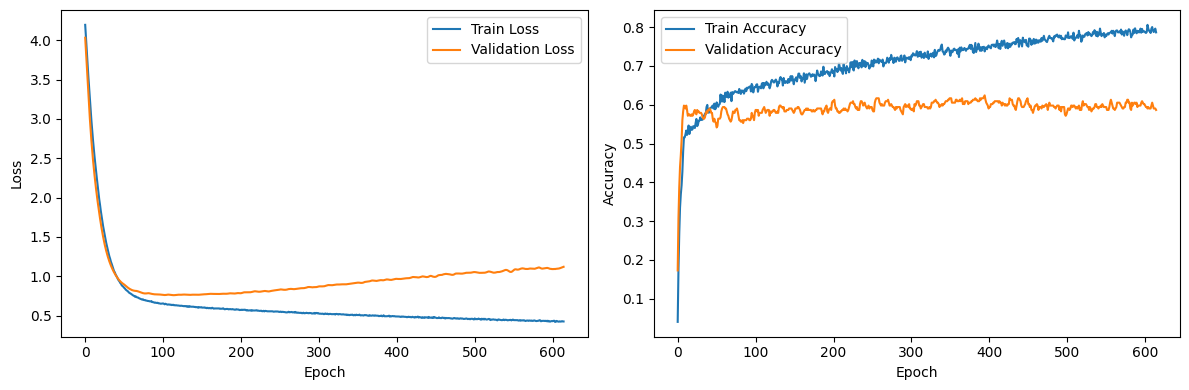


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1804, Val Loss: 3.1098, Train Acc: 0.5143, Val Acc: 0.4745
Epoch: 020, Train Loss: 2.0851, Val Loss: 2.0405, Train Acc: 0.5227, Val Acc: 0.4863
Epoch: 030, Train Loss: 1.4184, Val Loss: 1.4276, Train Acc: 0.5327, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.0760, Val Loss: 1.0998, Train Acc: 0.5587, Val Acc: 0.5059
Epoch: 050, Train Loss: 0.9031, Val Loss: 0.9578, Train Acc: 0.5814, Val Acc: 0.5098
Epoch: 060, Train Loss: 0.8115, Val Loss: 0.8560, Train Acc: 0.5990, Val Acc: 0.5137
Epoch: 070, Train Loss: 0.7437, Val Loss: 0.8157, Train Acc: 0.6191, Val Acc: 0.5098
Epoch: 080, Train Loss: 0.6997, Val Loss: 0.7815, Train Acc: 0.6409, Val Acc: 0.5412
Epoch: 090, Train Loss: 0.6744, Val Loss: 0.7596, Train Acc: 0.6300, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6520, Val Loss: 0.7525, Train Acc: 0.6527, Val Acc: 0.5294
Epoch: 110, Train Loss: 0.6380, Val Loss: 0.7383, Tr

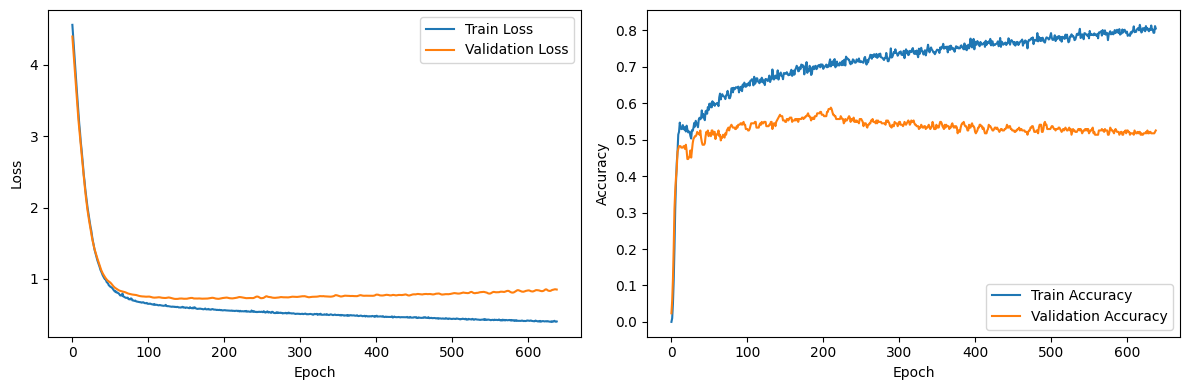


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1893, Val Loss: 3.0771, Train Acc: 0.4338, Val Acc: 0.4958
Epoch: 020, Train Loss: 2.2812, Val Loss: 2.2485, Train Acc: 0.5372, Val Acc: 0.5551
Epoch: 030, Train Loss: 1.6056, Val Loss: 1.6416, Train Acc: 0.5481, Val Acc: 0.5085
Epoch: 040, Train Loss: 1.2150, Val Loss: 1.2753, Train Acc: 0.5608, Val Acc: 0.5000
Epoch: 050, Train Loss: 1.0009, Val Loss: 1.0652, Train Acc: 0.5862, Val Acc: 0.4915
Epoch: 060, Train Loss: 0.8696, Val Loss: 0.9495, Train Acc: 0.6062, Val Acc: 0.5339
Epoch: 070, Train Loss: 0.8061, Val Loss: 0.8673, Train Acc: 0.6089, Val Acc: 0.5297
Epoch: 080, Train Loss: 0.7457, Val Loss: 0.8222, Train Acc: 0.6207, Val Acc: 0.5508
Epoch: 090, Train Loss: 0.7024, Val Loss: 0.7789, Train Acc: 0.6316, Val Acc: 0.5551
Epoch: 100, Train Loss: 0.6829, Val Loss: 0.7642, Train Acc: 0.6316, Val Acc: 0.5551
Epoch: 110, Train Loss: 0.6607, Val Loss: 0.7507, Tr

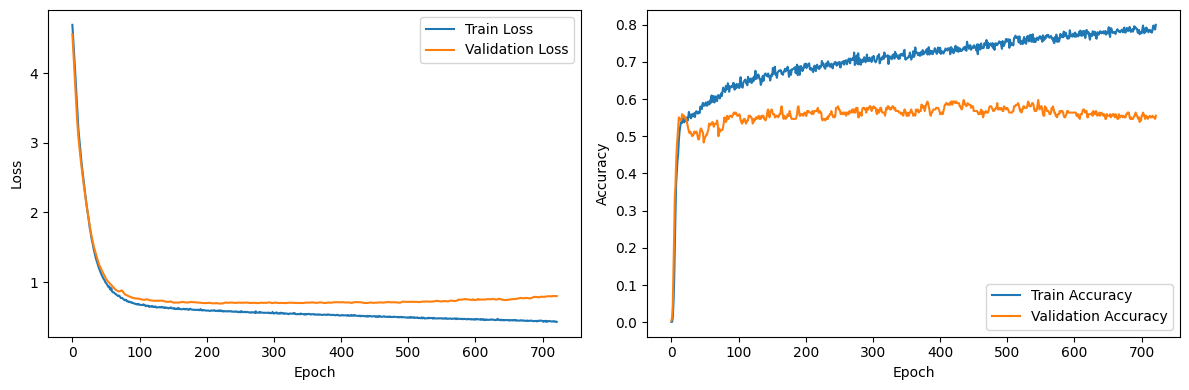


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5668, Val Loss: 3.3590, Train Acc: 0.4232, Val Acc: 0.5367
Epoch: 020, Train Loss: 2.2441, Val Loss: 2.1092, Train Acc: 0.5344, Val Acc: 0.5963
Epoch: 030, Train Loss: 1.5091, Val Loss: 1.4414, Train Acc: 0.5551, Val Acc: 0.5596
Epoch: 040, Train Loss: 1.1313, Val Loss: 1.1134, Train Acc: 0.5748, Val Acc: 0.5596
Epoch: 050, Train Loss: 0.9353, Val Loss: 0.9459, Train Acc: 0.6024, Val Acc: 0.5275
Epoch: 060, Train Loss: 0.8283, Val Loss: 0.8601, Train Acc: 0.6093, Val Acc: 0.5505
Epoch: 070, Train Loss: 0.7628, Val Loss: 0.8197, Train Acc: 0.6132, Val Acc: 0.5459
Epoch: 080, Train Loss: 0.7117, Val Loss: 0.7924, Train Acc: 0.6211, Val Acc: 0.5505
Epoch: 090, Train Loss: 0.6852, Val Loss: 0.7719, Train Acc: 0.6289, Val Acc: 0.5550
Epoch: 100, Train Loss: 0.6652, Val Loss: 0.7637, Train Acc: 0.6319, Val Acc: 0.5688
Epoch: 110, Train Loss: 0.6533, Val Loss: 0.7565, Tr

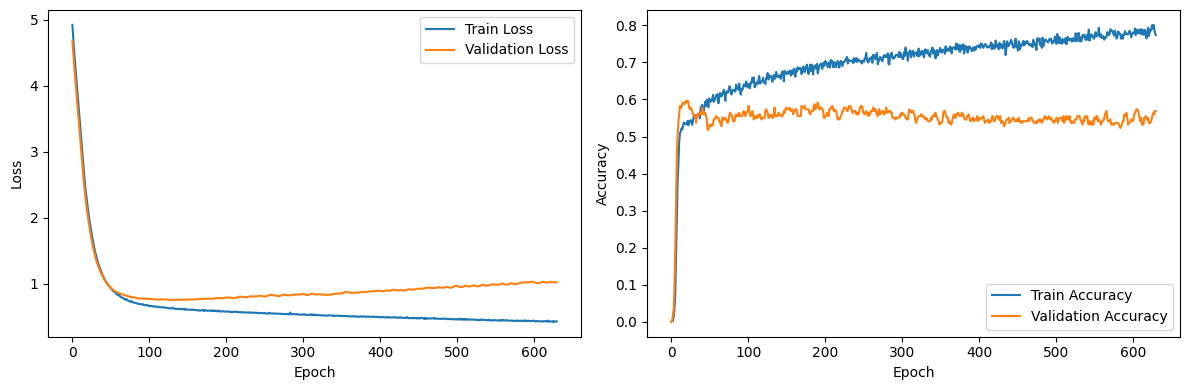


========== Run 21 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3689, Val Loss: 3.0781, Train Acc: 0.2595, Val Acc: 0.3421
Epoch: 020, Train Loss: 2.3185, Val Loss: 2.1210, Train Acc: 0.5479, Val Acc: 0.5188
Epoch: 030, Train Loss: 1.6024, Val Loss: 1.4987, Train Acc: 0.5681, Val Acc: 0.5038
Epoch: 040, Train Loss: 1.1724, Val Loss: 1.1190, Train Acc: 0.5753, Val Acc: 0.5564
Epoch: 050, Train Loss: 0.9338, Val Loss: 0.9379, Train Acc: 0.6060, Val Acc: 0.5639
Epoch: 060, Train Loss: 0.8107, Val Loss: 0.8395, Train Acc: 0.6205, Val Acc: 0.6015
Epoch: 070, Train Loss: 0.7460, Val Loss: 0.7876, Train Acc: 0.6148, Val Acc: 0.6090
Epoch: 080, Train Loss: 0.7021, Val Loss: 0.7639, Train Acc: 0.6326, Val Acc: 0.5940
Epoch: 090, Train Loss: 0.6786, Val Loss: 0.7470, Train Acc: 0.6414, Val Acc: 0.6053
Epoch: 100, Train Loss: 0.6615, Val Loss: 0.7350, Train Acc: 0.6358, Val Acc: 0.6053
Epoch: 110, Train Los

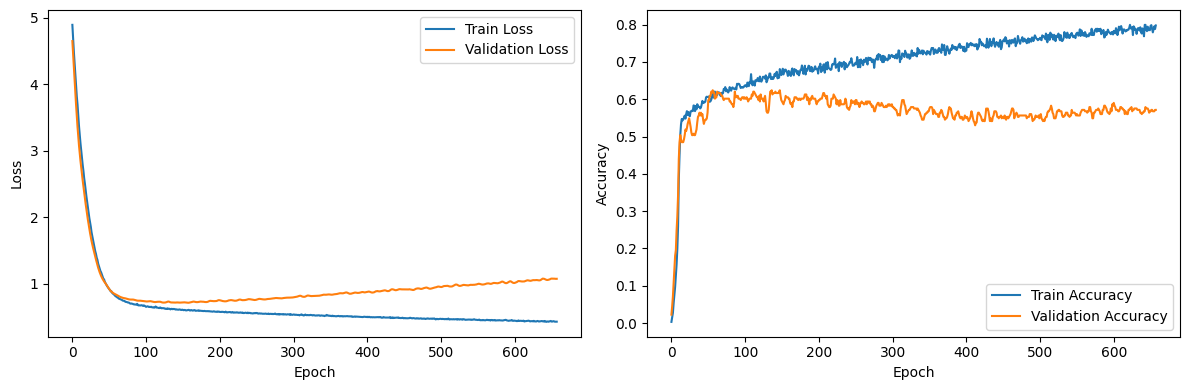


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2925, Val Loss: 3.2042, Train Acc: 0.3817, Val Acc: 0.4235
Epoch: 020, Train Loss: 2.2014, Val Loss: 2.1840, Train Acc: 0.5059, Val Acc: 0.5020
Epoch: 030, Train Loss: 1.5448, Val Loss: 1.5305, Train Acc: 0.5134, Val Acc: 0.5020
Epoch: 040, Train Loss: 1.1650, Val Loss: 1.1817, Train Acc: 0.5587, Val Acc: 0.4706
Epoch: 050, Train Loss: 0.9721, Val Loss: 1.0055, Train Acc: 0.5864, Val Acc: 0.5176
Epoch: 060, Train Loss: 0.8462, Val Loss: 0.8868, Train Acc: 0.6183, Val Acc: 0.5059
Epoch: 070, Train Loss: 0.7669, Val Loss: 0.8238, Train Acc: 0.6216, Val Acc: 0.5412
Epoch: 080, Train Loss: 0.7220, Val Loss: 0.7852, Train Acc: 0.6426, Val Acc: 0.5569
Epoch: 090, Train Loss: 0.6809, Val Loss: 0.7583, Train Acc: 0.6485, Val Acc: 0.5451
Epoch: 100, Train Loss: 0.6581, Val Loss: 0.7474, Train Acc: 0.6485, Val Acc: 0.5608
Epoch: 110, Train Loss: 0.6345, Val Loss: 0.7361, Tr

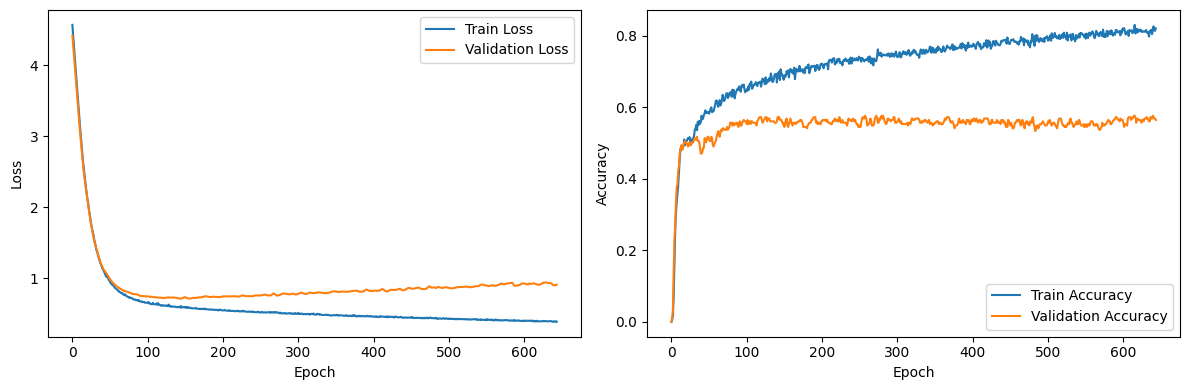


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4666, Val Loss: 3.2868, Train Acc: 0.3648, Val Acc: 0.3644
Epoch: 020, Train Loss: 2.4879, Val Loss: 2.4533, Train Acc: 0.4955, Val Acc: 0.4788
Epoch: 030, Train Loss: 1.7581, Val Loss: 1.7594, Train Acc: 0.5082, Val Acc: 0.4915
Epoch: 040, Train Loss: 1.2717, Val Loss: 1.3133, Train Acc: 0.5327, Val Acc: 0.4915
Epoch: 050, Train Loss: 1.0257, Val Loss: 1.0650, Train Acc: 0.5454, Val Acc: 0.5339
Epoch: 060, Train Loss: 0.8803, Val Loss: 0.9349, Train Acc: 0.5690, Val Acc: 0.5424
Epoch: 070, Train Loss: 0.7990, Val Loss: 0.8612, Train Acc: 0.5935, Val Acc: 0.5424
Epoch: 080, Train Loss: 0.7412, Val Loss: 0.8088, Train Acc: 0.6053, Val Acc: 0.5466
Epoch: 090, Train Loss: 0.7082, Val Loss: 0.7674, Train Acc: 0.6298, Val Acc: 0.5254
Epoch: 100, Train Loss: 0.6829, Val Loss: 0.7520, Train Acc: 0.6316, Val Acc: 0.5254
Epoch: 110, Train Loss: 0.6641, Val Loss: 0.7458, Tr

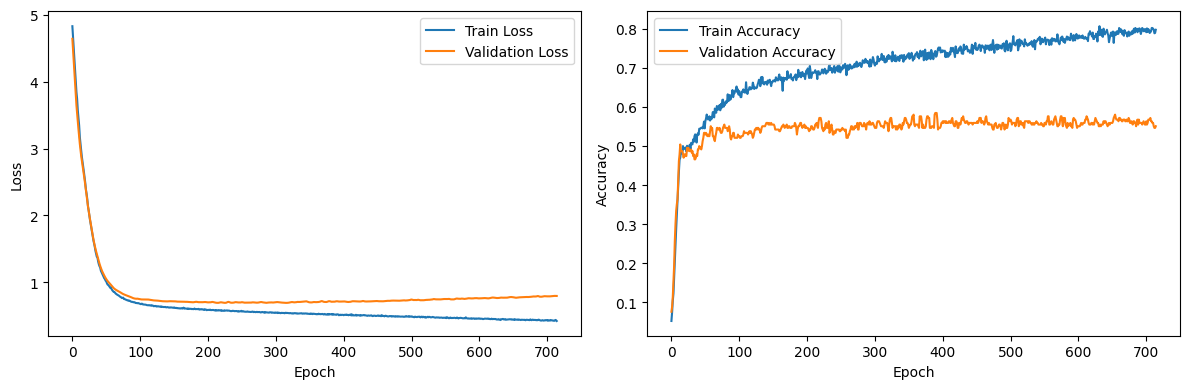


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4961, Val Loss: 3.2970, Train Acc: 0.4262, Val Acc: 0.4679
Epoch: 020, Train Loss: 2.2698, Val Loss: 2.1567, Train Acc: 0.4931, Val Acc: 0.4679
Epoch: 030, Train Loss: 1.5922, Val Loss: 1.5312, Train Acc: 0.5059, Val Acc: 0.5046
Epoch: 040, Train Loss: 1.1999, Val Loss: 1.1637, Train Acc: 0.5197, Val Acc: 0.5275
Epoch: 050, Train Loss: 0.9802, Val Loss: 0.9685, Train Acc: 0.5600, Val Acc: 0.5505
Epoch: 060, Train Loss: 0.8658, Val Loss: 0.8688, Train Acc: 0.5935, Val Acc: 0.5046
Epoch: 070, Train Loss: 0.7912, Val Loss: 0.8191, Train Acc: 0.5876, Val Acc: 0.4862
Epoch: 080, Train Loss: 0.7305, Val Loss: 0.7835, Train Acc: 0.6083, Val Acc: 0.5183
Epoch: 090, Train Loss: 0.6972, Val Loss: 0.7750, Train Acc: 0.6329, Val Acc: 0.5138
Epoch: 100, Train Loss: 0.6898, Val Loss: 0.7574, Train Acc: 0.6240, Val Acc: 0.5138
Epoch: 110, Train Loss: 0.6572, Val Loss: 0.7578, Tr

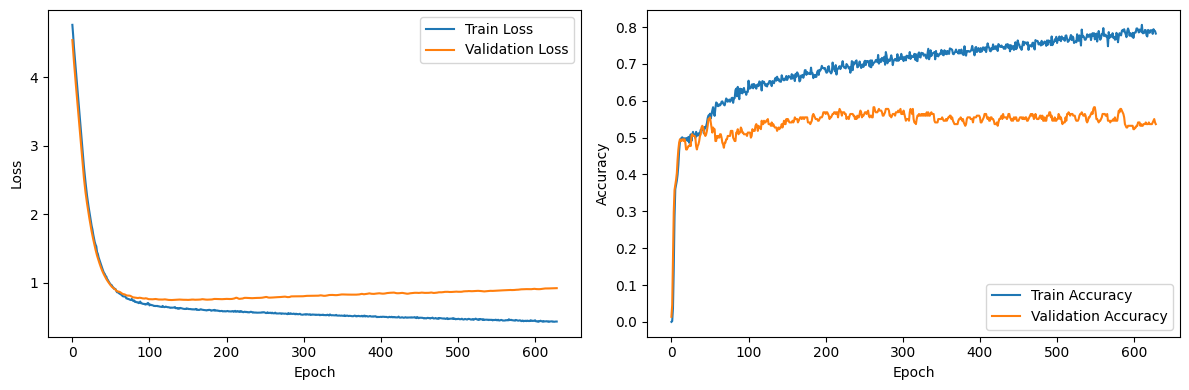


========== Run 22 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.7045, Val Loss: 3.4551, Train Acc: 0.4343, Val Acc: 0.4850
Epoch: 020, Train Loss: 2.4422, Val Loss: 2.2011, Train Acc: 0.5657, Val Acc: 0.5188
Epoch: 030, Train Loss: 1.6166, Val Loss: 1.4861, Train Acc: 0.5681, Val Acc: 0.4925
Epoch: 040, Train Loss: 1.1806, Val Loss: 1.1160, Train Acc: 0.5657, Val Acc: 0.5526
Epoch: 050, Train Loss: 0.9456, Val Loss: 0.9243, Train Acc: 0.5786, Val Acc: 0.5902
Epoch: 060, Train Loss: 0.8144, Val Loss: 0.8270, Train Acc: 0.5995, Val Acc: 0.5752
Epoch: 070, Train Loss: 0.7522, Val Loss: 0.7774, Train Acc: 0.6205, Val Acc: 0.5977
Epoch: 080, Train Loss: 0.7122, Val Loss: 0.7550, Train Acc: 0.6277, Val Acc: 0.5789
Epoch: 090, Train Loss: 0.6810, Val Loss: 0.7445, Train Acc: 0.6479, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6677, Val Loss: 0.7366, Train Acc: 0.6406, Val Acc: 0.6090
Epoch: 110, Train Los

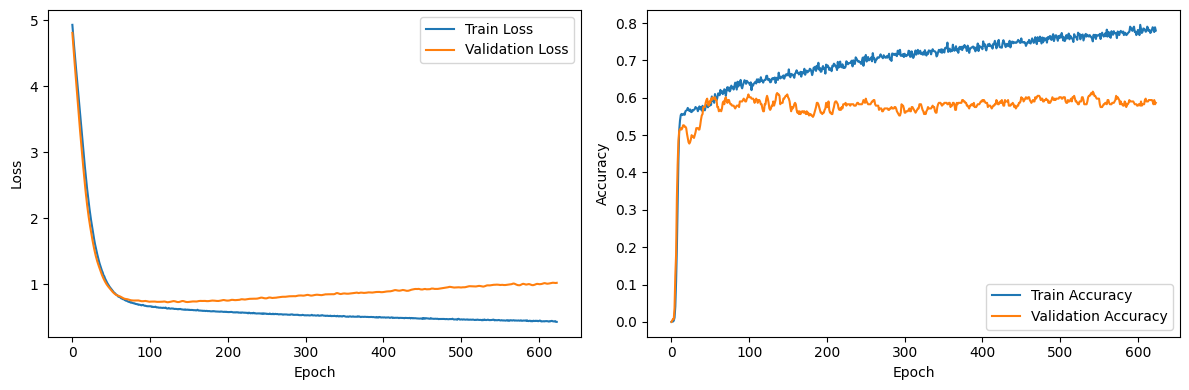


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.8335, Val Loss: 3.7349, Train Acc: 0.1552, Val Acc: 0.2118
Epoch: 020, Train Loss: 2.4340, Val Loss: 2.3517, Train Acc: 0.5436, Val Acc: 0.5373
Epoch: 030, Train Loss: 1.5929, Val Loss: 1.5931, Train Acc: 0.5864, Val Acc: 0.5176
Epoch: 040, Train Loss: 1.1564, Val Loss: 1.1914, Train Acc: 0.6057, Val Acc: 0.5176
Epoch: 050, Train Loss: 0.9469, Val Loss: 0.9761, Train Acc: 0.6158, Val Acc: 0.5373
Epoch: 060, Train Loss: 0.8274, Val Loss: 0.8640, Train Acc: 0.6300, Val Acc: 0.5373
Epoch: 070, Train Loss: 0.7525, Val Loss: 0.8110, Train Acc: 0.6367, Val Acc: 0.5451
Epoch: 080, Train Loss: 0.7083, Val Loss: 0.7797, Train Acc: 0.6527, Val Acc: 0.5529
Epoch: 090, Train Loss: 0.6770, Val Loss: 0.7543, Train Acc: 0.6577, Val Acc: 0.5569
Epoch: 100, Train Loss: 0.6612, Val Loss: 0.7445, Train Acc: 0.6560, Val Acc: 0.5569
Epoch: 110, Train Loss: 0.6380, Val Loss: 0.7330, Tr

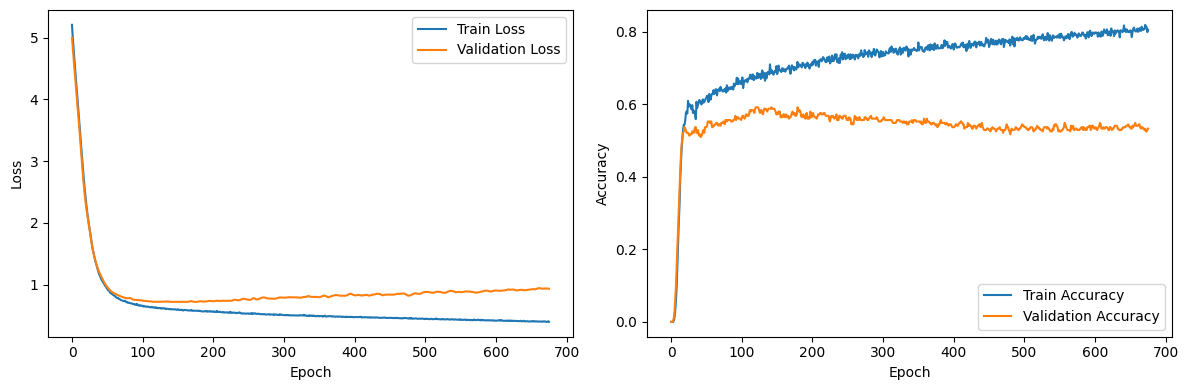


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9475, Val Loss: 2.8577, Train Acc: 0.3857, Val Acc: 0.4068
Epoch: 020, Train Loss: 2.0511, Val Loss: 2.0691, Train Acc: 0.5154, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.4593, Val Loss: 1.5047, Train Acc: 0.5499, Val Acc: 0.4534
Epoch: 040, Train Loss: 1.1178, Val Loss: 1.1884, Train Acc: 0.5808, Val Acc: 0.4915
Epoch: 050, Train Loss: 0.9405, Val Loss: 1.0229, Train Acc: 0.5971, Val Acc: 0.4703
Epoch: 060, Train Loss: 0.8283, Val Loss: 0.9112, Train Acc: 0.6216, Val Acc: 0.5042
Epoch: 070, Train Loss: 0.7654, Val Loss: 0.8438, Train Acc: 0.6216, Val Acc: 0.5551
Epoch: 080, Train Loss: 0.7174, Val Loss: 0.8062, Train Acc: 0.6298, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.6845, Val Loss: 0.7646, Train Acc: 0.6425, Val Acc: 0.5212
Epoch: 100, Train Loss: 0.6660, Val Loss: 0.7476, Train Acc: 0.6443, Val Acc: 0.5466
Epoch: 110, Train Loss: 0.6537, Val Loss: 0.7501, Tr

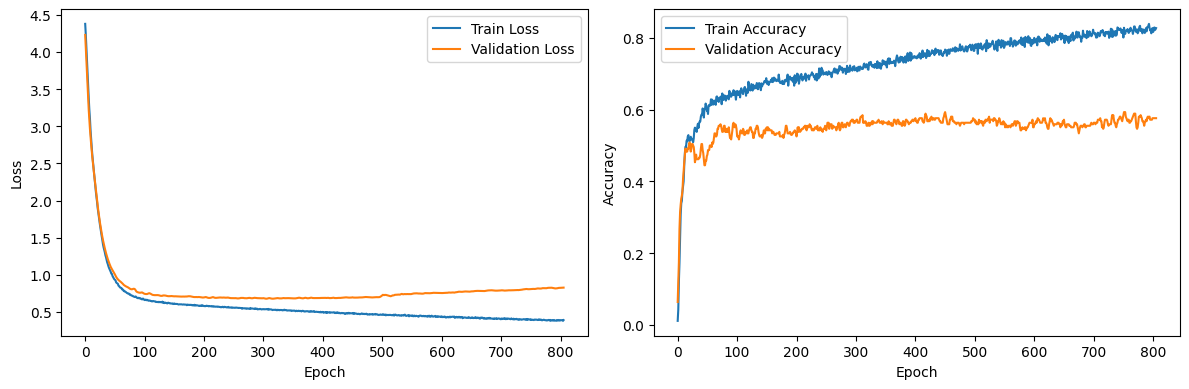


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1863, Val Loss: 2.9556, Train Acc: 0.4173, Val Acc: 0.4817
Epoch: 020, Train Loss: 2.2191, Val Loss: 2.0984, Train Acc: 0.5276, Val Acc: 0.5550
Epoch: 030, Train Loss: 1.5251, Val Loss: 1.4926, Train Acc: 0.5699, Val Acc: 0.5734
Epoch: 040, Train Loss: 1.1328, Val Loss: 1.1211, Train Acc: 0.5748, Val Acc: 0.5826
Epoch: 050, Train Loss: 0.9258, Val Loss: 0.9559, Train Acc: 0.5935, Val Acc: 0.5367
Epoch: 060, Train Loss: 0.8152, Val Loss: 0.8677, Train Acc: 0.6053, Val Acc: 0.5275
Epoch: 070, Train Loss: 0.7488, Val Loss: 0.8259, Train Acc: 0.6270, Val Acc: 0.5321
Epoch: 080, Train Loss: 0.7063, Val Loss: 0.8104, Train Acc: 0.6427, Val Acc: 0.5413
Epoch: 090, Train Loss: 0.6839, Val Loss: 0.7862, Train Acc: 0.6368, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6549, Val Loss: 0.7846, Train Acc: 0.6575, Val Acc: 0.5688
Epoch: 110, Train Loss: 0.6465, Val Loss: 0.7780, Tr

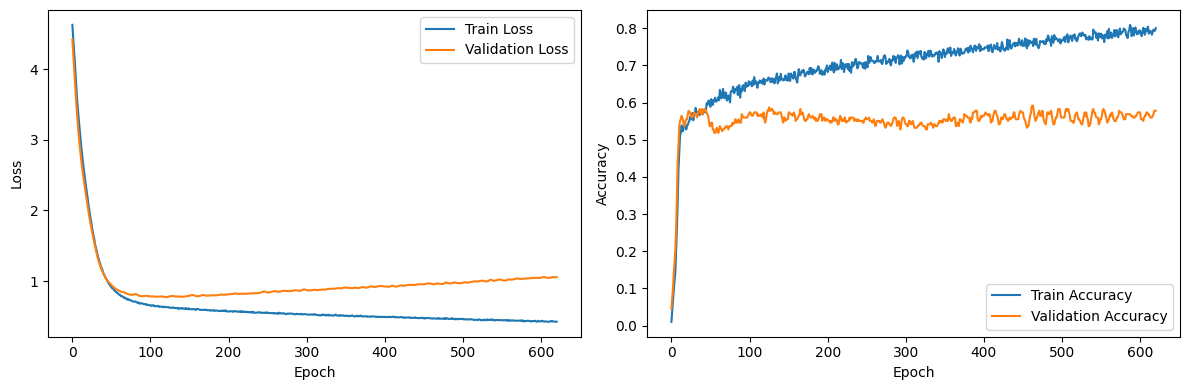


========== Run 23 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4527, Val Loss: 3.2403, Train Acc: 0.4077, Val Acc: 0.4586
Epoch: 020, Train Loss: 2.2904, Val Loss: 2.0951, Train Acc: 0.5471, Val Acc: 0.5188
Epoch: 030, Train Loss: 1.5451, Val Loss: 1.4609, Train Acc: 0.5778, Val Acc: 0.5301
Epoch: 040, Train Loss: 1.1486, Val Loss: 1.1297, Train Acc: 0.5858, Val Acc: 0.5714
Epoch: 050, Train Loss: 0.9448, Val Loss: 0.9539, Train Acc: 0.6116, Val Acc: 0.5902
Epoch: 060, Train Loss: 0.8284, Val Loss: 0.8621, Train Acc: 0.6180, Val Acc: 0.5977
Epoch: 070, Train Loss: 0.7599, Val Loss: 0.8163, Train Acc: 0.6221, Val Acc: 0.5752
Epoch: 080, Train Loss: 0.7220, Val Loss: 0.7841, Train Acc: 0.6213, Val Acc: 0.5677
Epoch: 090, Train Loss: 0.6871, Val Loss: 0.7694, Train Acc: 0.6277, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.6622, Val Loss: 0.7655, Train Acc: 0.6583, Val Acc: 0.5602
Epoch: 110, Train Los

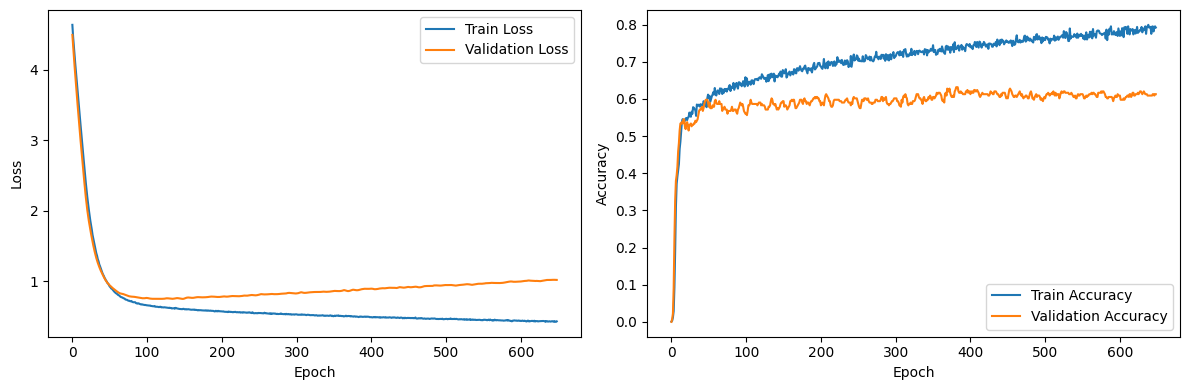


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0667, Val Loss: 2.9602, Train Acc: 0.4958, Val Acc: 0.4902
Epoch: 020, Train Loss: 2.0704, Val Loss: 2.0541, Train Acc: 0.5470, Val Acc: 0.5098
Epoch: 030, Train Loss: 1.4491, Val Loss: 1.4717, Train Acc: 0.5570, Val Acc: 0.5137
Epoch: 040, Train Loss: 1.1144, Val Loss: 1.1644, Train Acc: 0.5721, Val Acc: 0.5216
Epoch: 050, Train Loss: 0.9426, Val Loss: 0.9662, Train Acc: 0.5705, Val Acc: 0.5608
Epoch: 060, Train Loss: 0.8507, Val Loss: 0.8795, Train Acc: 0.5990, Val Acc: 0.5412
Epoch: 070, Train Loss: 0.7564, Val Loss: 0.8353, Train Acc: 0.6258, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.7101, Val Loss: 0.7766, Train Acc: 0.6367, Val Acc: 0.5686
Epoch: 090, Train Loss: 0.6767, Val Loss: 0.7608, Train Acc: 0.6485, Val Acc: 0.5569
Epoch: 100, Train Loss: 0.6570, Val Loss: 0.7485, Train Acc: 0.6535, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.6389, Val Loss: 0.7407, Tr

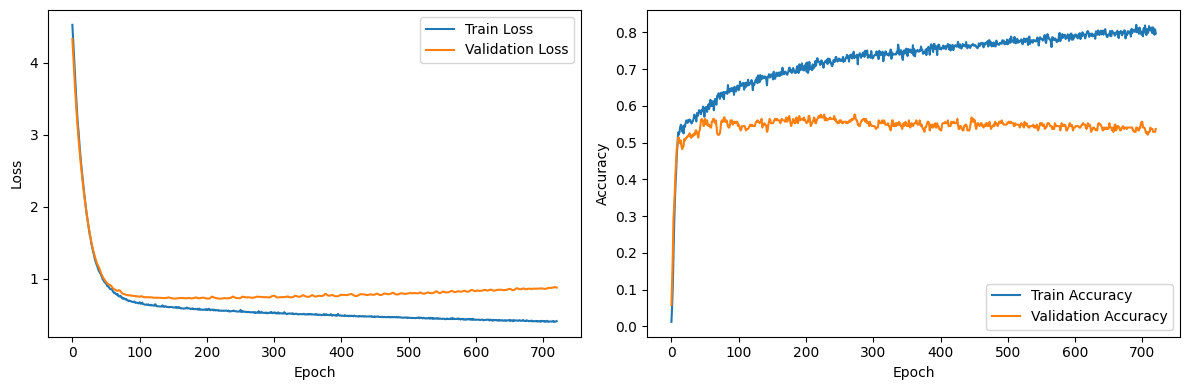


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4839, Val Loss: 3.3778, Train Acc: 0.2940, Val Acc: 0.3517
Epoch: 020, Train Loss: 2.4768, Val Loss: 2.5458, Train Acc: 0.4746, Val Acc: 0.4873
Epoch: 030, Train Loss: 1.7602, Val Loss: 1.8134, Train Acc: 0.5018, Val Acc: 0.4958
Epoch: 040, Train Loss: 1.3008, Val Loss: 1.3609, Train Acc: 0.5127, Val Acc: 0.5466
Epoch: 050, Train Loss: 1.0478, Val Loss: 1.1061, Train Acc: 0.5426, Val Acc: 0.5466
Epoch: 060, Train Loss: 0.9031, Val Loss: 0.9484, Train Acc: 0.5835, Val Acc: 0.5847
Epoch: 070, Train Loss: 0.8217, Val Loss: 0.8721, Train Acc: 0.6152, Val Acc: 0.5593
Epoch: 080, Train Loss: 0.7472, Val Loss: 0.8075, Train Acc: 0.6289, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.7108, Val Loss: 0.7694, Train Acc: 0.6343, Val Acc: 0.5424
Epoch: 100, Train Loss: 0.6869, Val Loss: 0.7505, Train Acc: 0.6407, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.6640, Val Loss: 0.7375, Tr

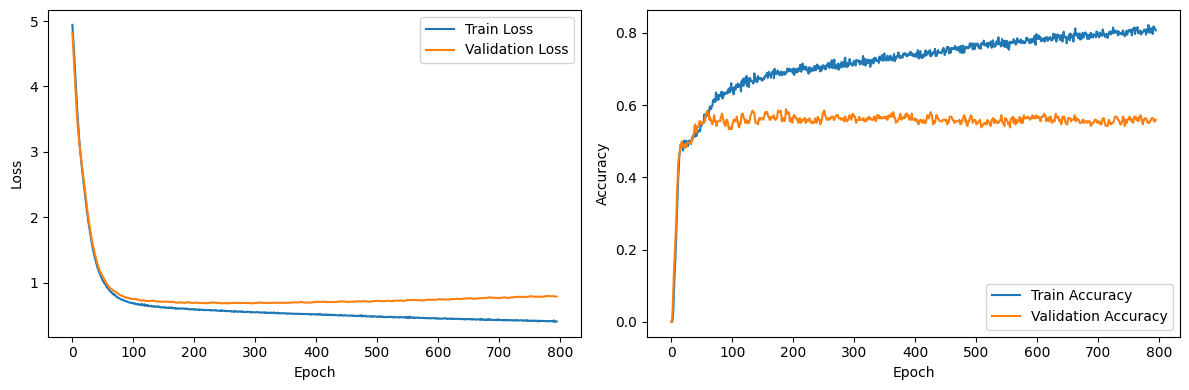


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5139, Val Loss: 3.3236, Train Acc: 0.4154, Val Acc: 0.4404
Epoch: 020, Train Loss: 2.3482, Val Loss: 2.2530, Train Acc: 0.5433, Val Acc: 0.5138
Epoch: 030, Train Loss: 1.6390, Val Loss: 1.5638, Train Acc: 0.5482, Val Acc: 0.5092
Epoch: 040, Train Loss: 1.1934, Val Loss: 1.1584, Train Acc: 0.5758, Val Acc: 0.5321
Epoch: 050, Train Loss: 0.9854, Val Loss: 0.9641, Train Acc: 0.5935, Val Acc: 0.5321
Epoch: 060, Train Loss: 0.8502, Val Loss: 0.8587, Train Acc: 0.6102, Val Acc: 0.5321
Epoch: 070, Train Loss: 0.7704, Val Loss: 0.8022, Train Acc: 0.6083, Val Acc: 0.5459
Epoch: 080, Train Loss: 0.7225, Val Loss: 0.7701, Train Acc: 0.6250, Val Acc: 0.5459
Epoch: 090, Train Loss: 0.6937, Val Loss: 0.7502, Train Acc: 0.6270, Val Acc: 0.5734
Epoch: 100, Train Loss: 0.6706, Val Loss: 0.7476, Train Acc: 0.6339, Val Acc: 0.5688
Epoch: 110, Train Loss: 0.6549, Val Loss: 0.7418, Tr

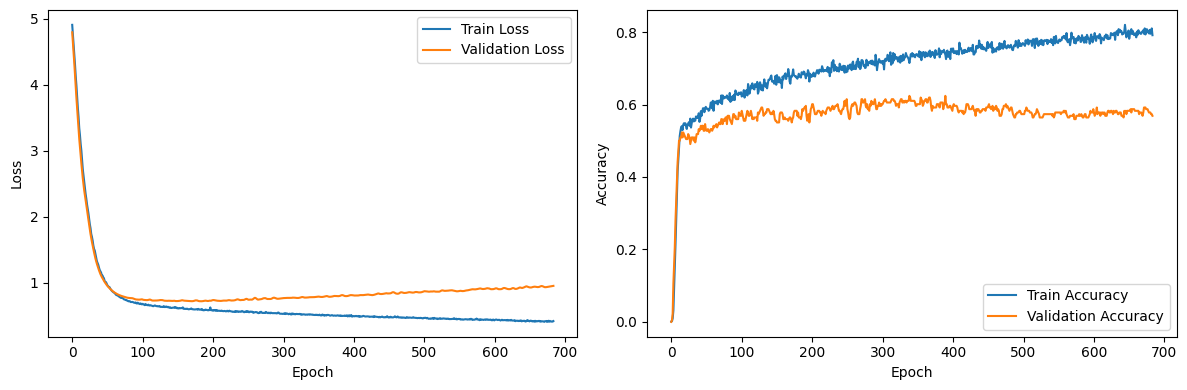


========== Run 24 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.5229, Val Loss: 3.2839, Train Acc: 0.4674, Val Acc: 0.5602
Epoch: 020, Train Loss: 2.3592, Val Loss: 2.1474, Train Acc: 0.5536, Val Acc: 0.5489
Epoch: 030, Train Loss: 1.5997, Val Loss: 1.4657, Train Acc: 0.5641, Val Acc: 0.5752
Epoch: 040, Train Loss: 1.1650, Val Loss: 1.1108, Train Acc: 0.5737, Val Acc: 0.5752
Epoch: 050, Train Loss: 0.9499, Val Loss: 0.9309, Train Acc: 0.5915, Val Acc: 0.5752
Epoch: 060, Train Loss: 0.8233, Val Loss: 0.8426, Train Acc: 0.6108, Val Acc: 0.6015
Epoch: 070, Train Loss: 0.7505, Val Loss: 0.7973, Train Acc: 0.6229, Val Acc: 0.5977
Epoch: 080, Train Loss: 0.7078, Val Loss: 0.7686, Train Acc: 0.6406, Val Acc: 0.6128
Epoch: 090, Train Loss: 0.6766, Val Loss: 0.7486, Train Acc: 0.6575, Val Acc: 0.6165
Epoch: 100, Train Loss: 0.6601, Val Loss: 0.7382, Train Acc: 0.6567, Val Acc: 0.6053
Epoch: 110, Train Los

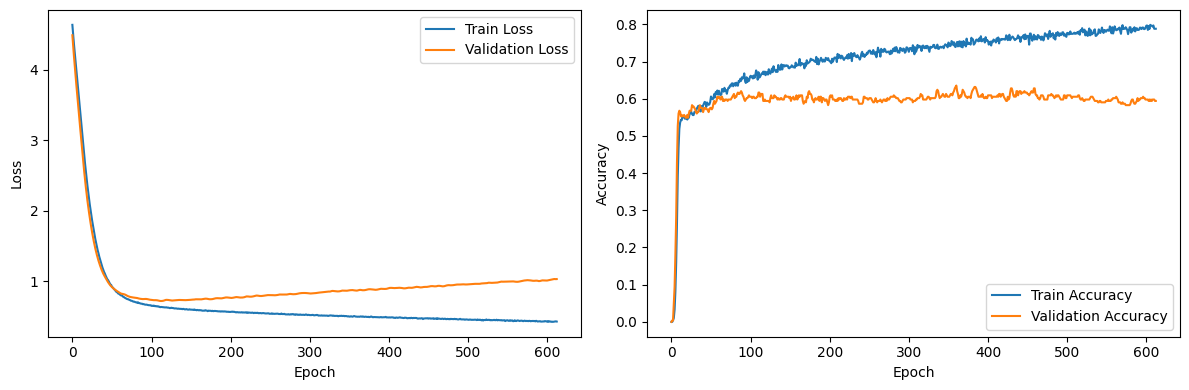


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6400, Val Loss: 3.5602, Train Acc: 0.4421, Val Acc: 0.4588
Epoch: 020, Train Loss: 2.4012, Val Loss: 2.3445, Train Acc: 0.5688, Val Acc: 0.4824
Epoch: 030, Train Loss: 1.5531, Val Loss: 1.5596, Train Acc: 0.5898, Val Acc: 0.4941
Epoch: 040, Train Loss: 1.1518, Val Loss: 1.1764, Train Acc: 0.6015, Val Acc: 0.5098
Epoch: 050, Train Loss: 0.9588, Val Loss: 0.9813, Train Acc: 0.6040, Val Acc: 0.5059
Epoch: 060, Train Loss: 0.8311, Val Loss: 0.8831, Train Acc: 0.6300, Val Acc: 0.5490
Epoch: 070, Train Loss: 0.7590, Val Loss: 0.8274, Train Acc: 0.6359, Val Acc: 0.5373
Epoch: 080, Train Loss: 0.7053, Val Loss: 0.7829, Train Acc: 0.6661, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6737, Val Loss: 0.7574, Train Acc: 0.6586, Val Acc: 0.5529
Epoch: 100, Train Loss: 0.6496, Val Loss: 0.7415, Train Acc: 0.6644, Val Acc: 0.5490
Epoch: 110, Train Loss: 0.6388, Val Loss: 0.7445, Tr

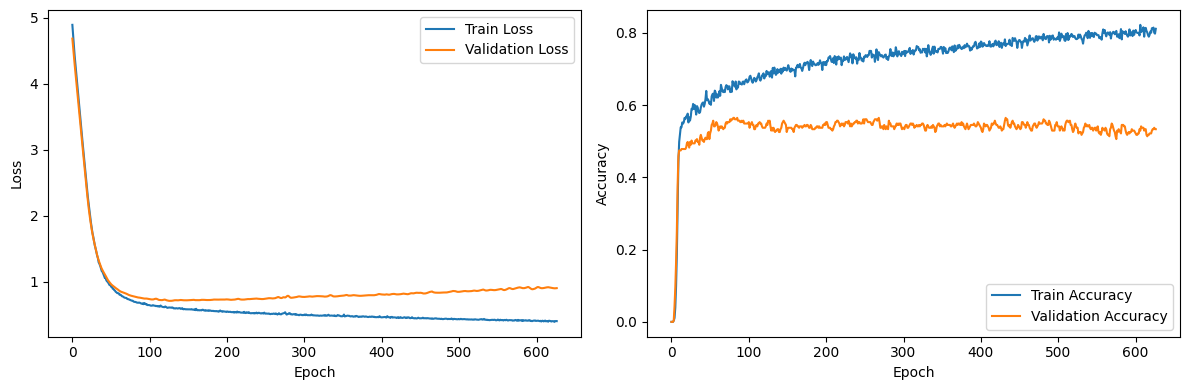


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1492, Val Loss: 3.0608, Train Acc: 0.4574, Val Acc: 0.5339
Epoch: 020, Train Loss: 2.0419, Val Loss: 2.0163, Train Acc: 0.5263, Val Acc: 0.5678
Epoch: 030, Train Loss: 1.4342, Val Loss: 1.4543, Train Acc: 0.5662, Val Acc: 0.5339
Epoch: 040, Train Loss: 1.0952, Val Loss: 1.1576, Train Acc: 0.5944, Val Acc: 0.5169
Epoch: 050, Train Loss: 0.9238, Val Loss: 0.9887, Train Acc: 0.5771, Val Acc: 0.4873
Epoch: 060, Train Loss: 0.8367, Val Loss: 0.8992, Train Acc: 0.5871, Val Acc: 0.5042
Epoch: 070, Train Loss: 0.7585, Val Loss: 0.8406, Train Acc: 0.6134, Val Acc: 0.5297
Epoch: 080, Train Loss: 0.7198, Val Loss: 0.7952, Train Acc: 0.6361, Val Acc: 0.5466
Epoch: 090, Train Loss: 0.6872, Val Loss: 0.7728, Train Acc: 0.6416, Val Acc: 0.5424
Epoch: 100, Train Loss: 0.6680, Val Loss: 0.7574, Train Acc: 0.6552, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.6484, Val Loss: 0.7465, Tr

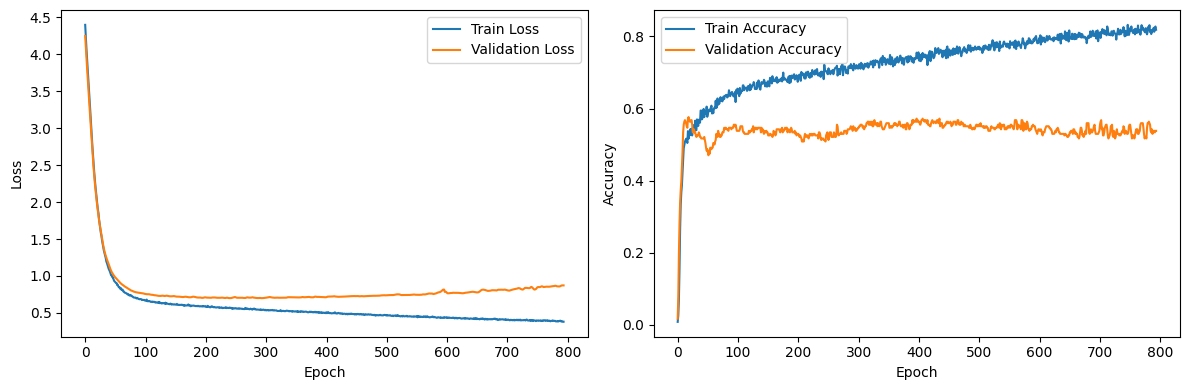


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2749, Val Loss: 3.0871, Train Acc: 0.3907, Val Acc: 0.4679
Epoch: 020, Train Loss: 2.1297, Val Loss: 2.0073, Train Acc: 0.5256, Val Acc: 0.5183
Epoch: 030, Train Loss: 1.5009, Val Loss: 1.4093, Train Acc: 0.5335, Val Acc: 0.5642
Epoch: 040, Train Loss: 1.1457, Val Loss: 1.0869, Train Acc: 0.5620, Val Acc: 0.5642
Epoch: 050, Train Loss: 0.9467, Val Loss: 0.9206, Train Acc: 0.5876, Val Acc: 0.5550
Epoch: 060, Train Loss: 0.8305, Val Loss: 0.8370, Train Acc: 0.5994, Val Acc: 0.5459
Epoch: 070, Train Loss: 0.7581, Val Loss: 0.7900, Train Acc: 0.6220, Val Acc: 0.5734
Epoch: 080, Train Loss: 0.7145, Val Loss: 0.7676, Train Acc: 0.6112, Val Acc: 0.5596
Epoch: 090, Train Loss: 0.6817, Val Loss: 0.7573, Train Acc: 0.6348, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6656, Val Loss: 0.7362, Train Acc: 0.6289, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6456, Val Loss: 0.7366, Tr

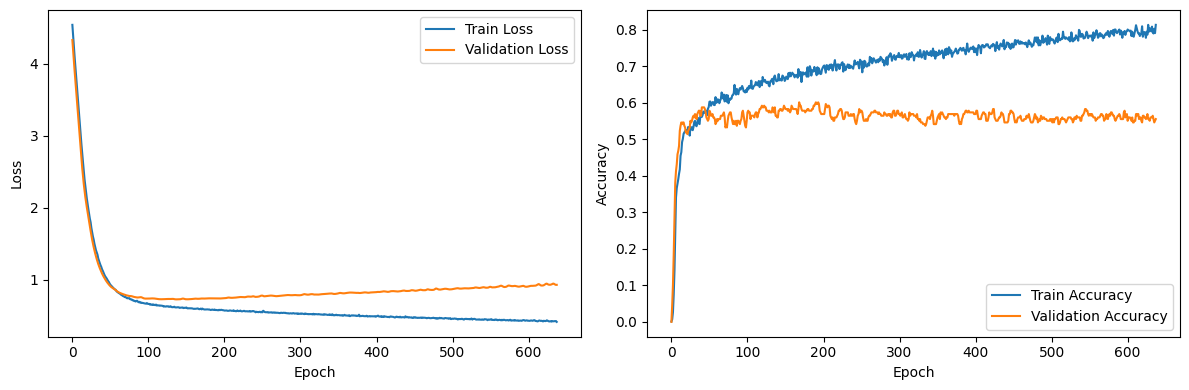


========== Run 25 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4291, Val Loss: 3.2376, Train Acc: 0.4295, Val Acc: 0.4474
Epoch: 020, Train Loss: 2.3130, Val Loss: 2.1666, Train Acc: 0.4988, Val Acc: 0.5038
Epoch: 030, Train Loss: 1.6087, Val Loss: 1.5347, Train Acc: 0.5020, Val Acc: 0.5075
Epoch: 040, Train Loss: 1.1840, Val Loss: 1.1805, Train Acc: 0.5391, Val Acc: 0.5075
Epoch: 050, Train Loss: 0.9563, Val Loss: 1.0030, Train Acc: 0.5633, Val Acc: 0.4962
Epoch: 060, Train Loss: 0.8266, Val Loss: 0.8966, Train Acc: 0.5947, Val Acc: 0.5188
Epoch: 070, Train Loss: 0.7565, Val Loss: 0.8469, Train Acc: 0.5939, Val Acc: 0.5226
Epoch: 080, Train Loss: 0.7093, Val Loss: 0.8051, Train Acc: 0.6172, Val Acc: 0.5489
Epoch: 090, Train Loss: 0.6772, Val Loss: 0.7841, Train Acc: 0.6350, Val Acc: 0.5602
Epoch: 100, Train Loss: 0.6583, Val Loss: 0.7822, Train Acc: 0.6430, Val Acc: 0.5526
Epoch: 110, Train Los

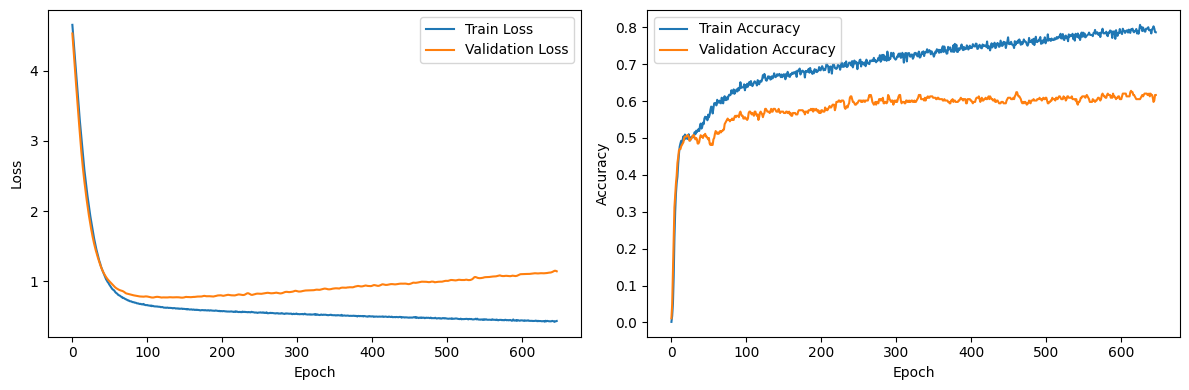


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1736, Val Loss: 3.0919, Train Acc: 0.4161, Val Acc: 0.4118
Epoch: 020, Train Loss: 2.1012, Val Loss: 2.0734, Train Acc: 0.5419, Val Acc: 0.5294
Epoch: 030, Train Loss: 1.4444, Val Loss: 1.4580, Train Acc: 0.5797, Val Acc: 0.5176
Epoch: 040, Train Loss: 1.1120, Val Loss: 1.1397, Train Acc: 0.5663, Val Acc: 0.5059
Epoch: 050, Train Loss: 0.9344, Val Loss: 0.9551, Train Acc: 0.5856, Val Acc: 0.5137
Epoch: 060, Train Loss: 0.8166, Val Loss: 0.8554, Train Acc: 0.6091, Val Acc: 0.5373
Epoch: 070, Train Loss: 0.7476, Val Loss: 0.7982, Train Acc: 0.6166, Val Acc: 0.5333
Epoch: 080, Train Loss: 0.7152, Val Loss: 0.7667, Train Acc: 0.6485, Val Acc: 0.5529
Epoch: 090, Train Loss: 0.6812, Val Loss: 0.7439, Train Acc: 0.6359, Val Acc: 0.5373
Epoch: 100, Train Loss: 0.6699, Val Loss: 0.7201, Train Acc: 0.6485, Val Acc: 0.5529
Epoch: 110, Train Loss: 0.6383, Val Loss: 0.7195, Tr

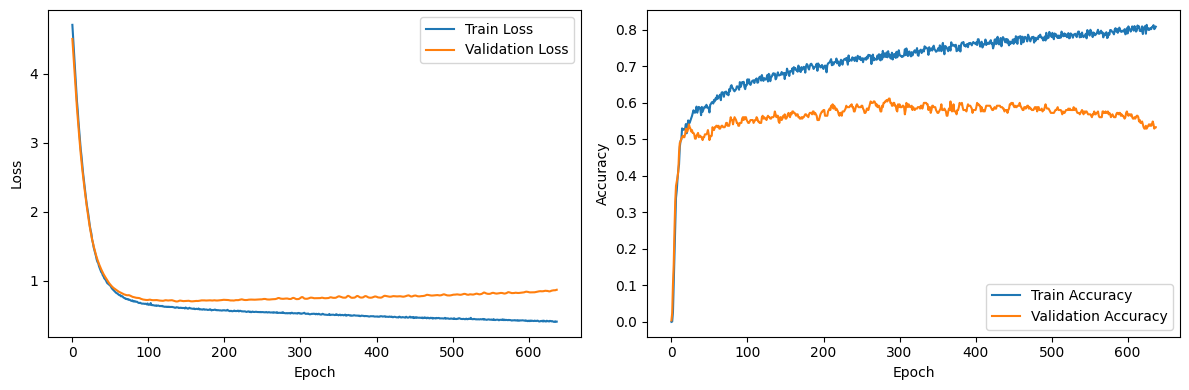


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.0442, Val Loss: 2.9584, Train Acc: 0.4011, Val Acc: 0.4153
Epoch: 020, Train Loss: 2.1413, Val Loss: 2.1364, Train Acc: 0.5181, Val Acc: 0.5127
Epoch: 030, Train Loss: 1.5232, Val Loss: 1.5644, Train Acc: 0.5472, Val Acc: 0.5127
Epoch: 040, Train Loss: 1.1659, Val Loss: 1.2153, Train Acc: 0.5554, Val Acc: 0.5508
Epoch: 050, Train Loss: 0.9680, Val Loss: 1.0207, Train Acc: 0.5907, Val Acc: 0.5551
Epoch: 060, Train Loss: 0.8612, Val Loss: 0.9180, Train Acc: 0.6025, Val Acc: 0.5508
Epoch: 070, Train Loss: 0.7709, Val Loss: 0.8335, Train Acc: 0.6388, Val Acc: 0.5424
Epoch: 080, Train Loss: 0.7241, Val Loss: 0.7871, Train Acc: 0.6270, Val Acc: 0.5339
Epoch: 090, Train Loss: 0.6903, Val Loss: 0.7597, Train Acc: 0.6452, Val Acc: 0.5381
Epoch: 100, Train Loss: 0.6711, Val Loss: 0.7409, Train Acc: 0.6479, Val Acc: 0.5339
Epoch: 110, Train Loss: 0.6502, Val Loss: 0.7255, Tr

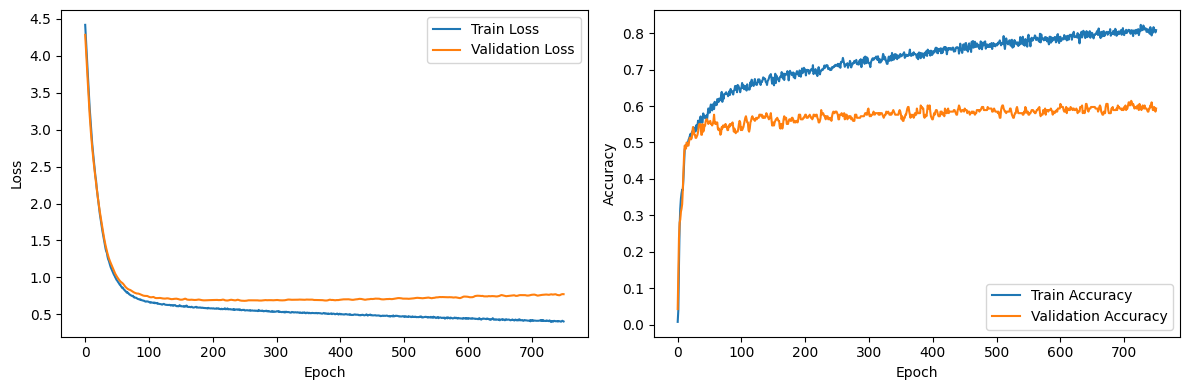


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9907, Val Loss: 2.7778, Train Acc: 0.4429, Val Acc: 0.4954
Epoch: 020, Train Loss: 2.0198, Val Loss: 1.9155, Train Acc: 0.5069, Val Acc: 0.4725
Epoch: 030, Train Loss: 1.4270, Val Loss: 1.3440, Train Acc: 0.5354, Val Acc: 0.4817
Epoch: 040, Train Loss: 1.1121, Val Loss: 1.0819, Train Acc: 0.5600, Val Acc: 0.4725
Epoch: 050, Train Loss: 0.9438, Val Loss: 0.9304, Train Acc: 0.5709, Val Acc: 0.5046
Epoch: 060, Train Loss: 0.8374, Val Loss: 0.8462, Train Acc: 0.5994, Val Acc: 0.5229
Epoch: 070, Train Loss: 0.7680, Val Loss: 0.7966, Train Acc: 0.6102, Val Acc: 0.5505
Epoch: 080, Train Loss: 0.7191, Val Loss: 0.7620, Train Acc: 0.6339, Val Acc: 0.5642
Epoch: 090, Train Loss: 0.6901, Val Loss: 0.7423, Train Acc: 0.6230, Val Acc: 0.5459
Epoch: 100, Train Loss: 0.6698, Val Loss: 0.7339, Train Acc: 0.6299, Val Acc: 0.5872
Epoch: 110, Train Loss: 0.6519, Val Loss: 0.7268, Tr

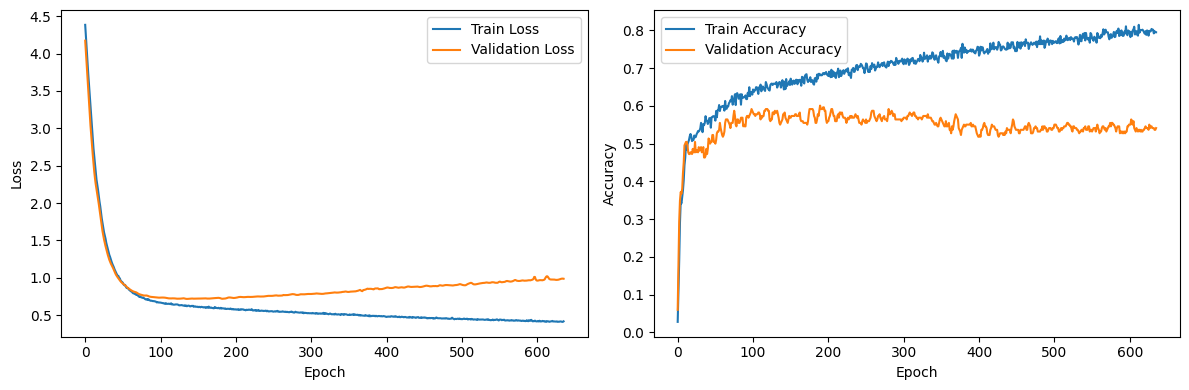


========== Run 26 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2421, Val Loss: 3.1244, Train Acc: 0.3820, Val Acc: 0.4173
Epoch: 020, Train Loss: 2.2452, Val Loss: 2.1178, Train Acc: 0.5004, Val Acc: 0.5489
Epoch: 030, Train Loss: 1.5808, Val Loss: 1.5287, Train Acc: 0.5230, Val Acc: 0.5376
Epoch: 040, Train Loss: 1.1773, Val Loss: 1.1693, Train Acc: 0.5520, Val Acc: 0.5263
Epoch: 050, Train Loss: 0.9587, Val Loss: 0.9963, Train Acc: 0.5761, Val Acc: 0.5226
Epoch: 060, Train Loss: 0.8233, Val Loss: 0.8866, Train Acc: 0.6068, Val Acc: 0.5489
Epoch: 070, Train Loss: 0.7513, Val Loss: 0.8295, Train Acc: 0.6148, Val Acc: 0.5714
Epoch: 080, Train Loss: 0.7054, Val Loss: 0.7939, Train Acc: 0.6342, Val Acc: 0.5827
Epoch: 090, Train Loss: 0.6793, Val Loss: 0.7754, Train Acc: 0.6237, Val Acc: 0.5902
Epoch: 100, Train Loss: 0.6679, Val Loss: 0.7611, Train Acc: 0.6317, Val Acc: 0.6203
Epoch: 110, Train Los

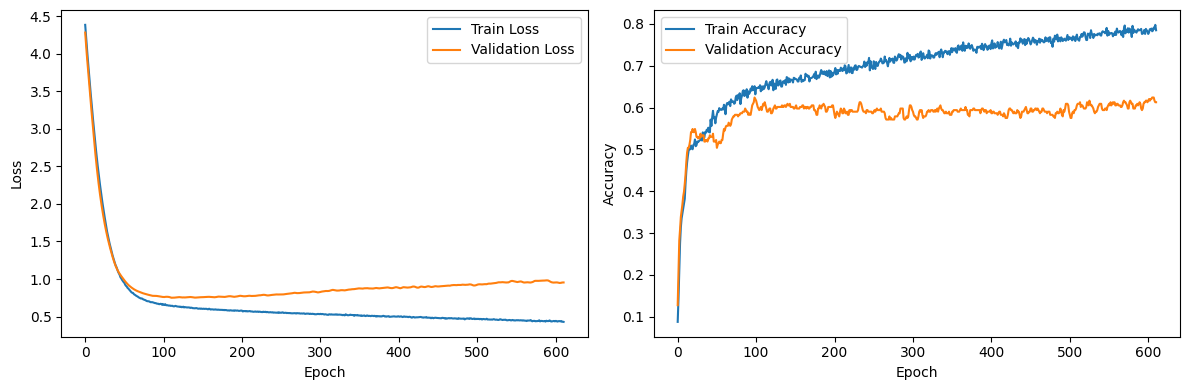


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.1958, Val Loss: 3.1060, Train Acc: 0.4656, Val Acc: 0.4980
Epoch: 020, Train Loss: 2.0543, Val Loss: 1.9926, Train Acc: 0.4958, Val Acc: 0.5020
Epoch: 030, Train Loss: 1.3691, Val Loss: 1.3459, Train Acc: 0.5117, Val Acc: 0.5176
Epoch: 040, Train Loss: 1.0547, Val Loss: 1.0493, Train Acc: 0.5579, Val Acc: 0.5255
Epoch: 050, Train Loss: 0.8870, Val Loss: 0.9076, Train Acc: 0.5864, Val Acc: 0.5333
Epoch: 060, Train Loss: 0.7850, Val Loss: 0.8243, Train Acc: 0.6300, Val Acc: 0.5647
Epoch: 070, Train Loss: 0.7322, Val Loss: 0.7777, Train Acc: 0.6225, Val Acc: 0.5647
Epoch: 080, Train Loss: 0.6890, Val Loss: 0.7567, Train Acc: 0.6250, Val Acc: 0.5569
Epoch: 090, Train Loss: 0.6567, Val Loss: 0.7452, Train Acc: 0.6619, Val Acc: 0.5451
Epoch: 100, Train Loss: 0.6432, Val Loss: 0.7321, Train Acc: 0.6477, Val Acc: 0.5490
Epoch: 110, Train Loss: 0.6237, Val Loss: 0.7302, Tr

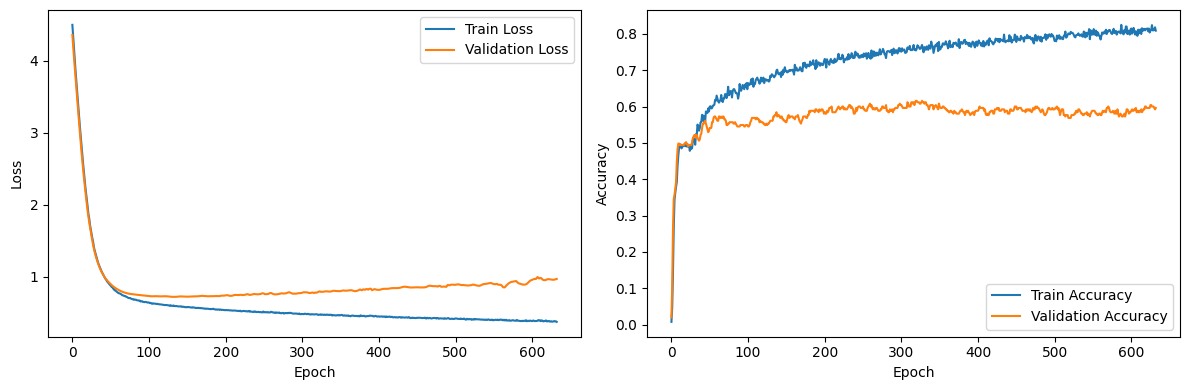


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2501, Val Loss: 3.2071, Train Acc: 0.3947, Val Acc: 0.3771
Epoch: 020, Train Loss: 2.2010, Val Loss: 2.1901, Train Acc: 0.5073, Val Acc: 0.5085
Epoch: 030, Train Loss: 1.5174, Val Loss: 1.5516, Train Acc: 0.5181, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.1318, Val Loss: 1.1548, Train Acc: 0.5191, Val Acc: 0.5042
Epoch: 050, Train Loss: 0.9379, Val Loss: 0.9816, Train Acc: 0.5681, Val Acc: 0.5169
Epoch: 060, Train Loss: 0.8277, Val Loss: 0.8857, Train Acc: 0.5935, Val Acc: 0.5212
Epoch: 070, Train Loss: 0.7583, Val Loss: 0.8289, Train Acc: 0.6034, Val Acc: 0.5127
Epoch: 080, Train Loss: 0.7158, Val Loss: 0.7854, Train Acc: 0.6225, Val Acc: 0.5297
Epoch: 090, Train Loss: 0.6858, Val Loss: 0.7629, Train Acc: 0.6479, Val Acc: 0.5297
Epoch: 100, Train Loss: 0.6705, Val Loss: 0.7530, Train Acc: 0.6488, Val Acc: 0.5381
Epoch: 110, Train Loss: 0.6610, Val Loss: 0.7438, Tr

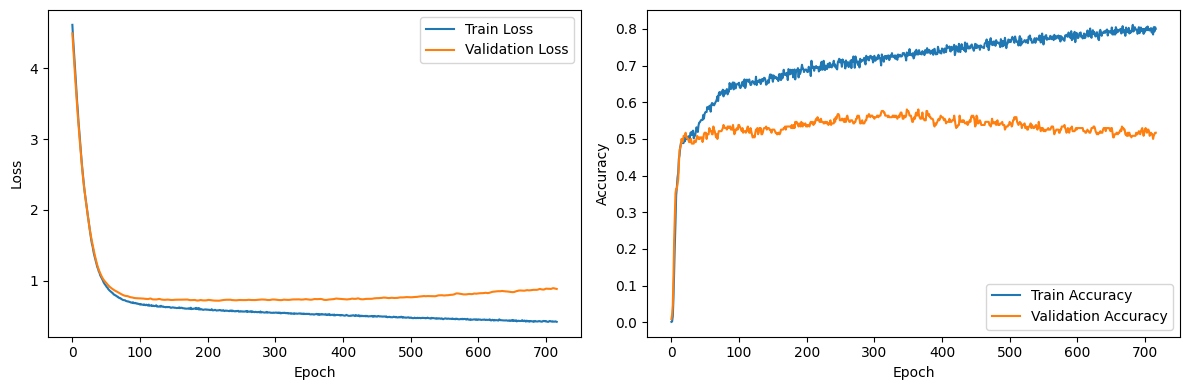


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9617, Val Loss: 2.7601, Train Acc: 0.4774, Val Acc: 0.5138
Epoch: 020, Train Loss: 2.0670, Val Loss: 1.9471, Train Acc: 0.5315, Val Acc: 0.5092
Epoch: 030, Train Loss: 1.4612, Val Loss: 1.4022, Train Acc: 0.5541, Val Acc: 0.5092
Epoch: 040, Train Loss: 1.1295, Val Loss: 1.0977, Train Acc: 0.5581, Val Acc: 0.5046
Epoch: 050, Train Loss: 0.9568, Val Loss: 0.9430, Train Acc: 0.5886, Val Acc: 0.5275
Epoch: 060, Train Loss: 0.8377, Val Loss: 0.8552, Train Acc: 0.5945, Val Acc: 0.5505
Epoch: 070, Train Loss: 0.7566, Val Loss: 0.7981, Train Acc: 0.6191, Val Acc: 0.5505
Epoch: 080, Train Loss: 0.7226, Val Loss: 0.7746, Train Acc: 0.6319, Val Acc: 0.5321
Epoch: 090, Train Loss: 0.6877, Val Loss: 0.7688, Train Acc: 0.6220, Val Acc: 0.5826
Epoch: 100, Train Loss: 0.6724, Val Loss: 0.7331, Train Acc: 0.6407, Val Acc: 0.5505
Epoch: 110, Train Loss: 0.6494, Val Loss: 0.7249, Tr

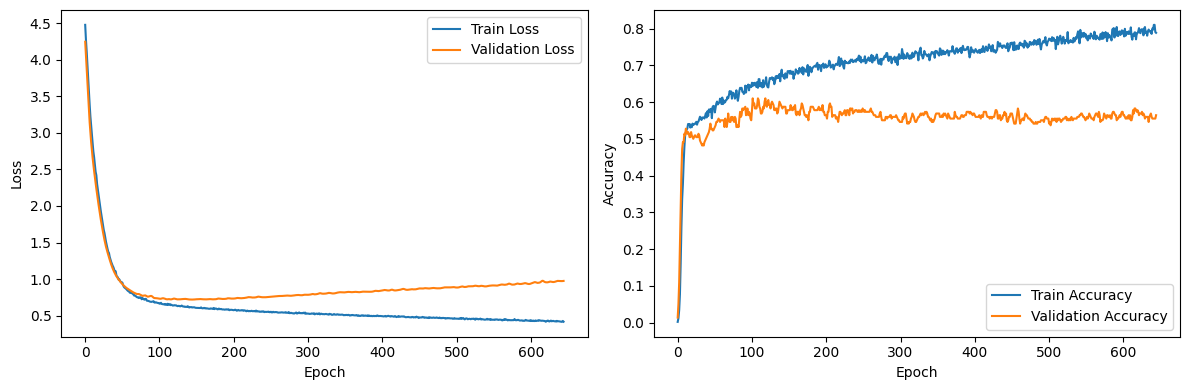


========== Run 27 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.7962, Val Loss: 3.5751, Train Acc: 0.2732, Val Acc: 0.4060
Epoch: 020, Train Loss: 2.5042, Val Loss: 2.3112, Train Acc: 0.5149, Val Acc: 0.5188
Epoch: 030, Train Loss: 1.6453, Val Loss: 1.4831, Train Acc: 0.5447, Val Acc: 0.5677
Epoch: 040, Train Loss: 1.1763, Val Loss: 1.1244, Train Acc: 0.5689, Val Acc: 0.5414
Epoch: 050, Train Loss: 0.9514, Val Loss: 0.9355, Train Acc: 0.5931, Val Acc: 0.5940
Epoch: 060, Train Loss: 0.8341, Val Loss: 0.8535, Train Acc: 0.6035, Val Acc: 0.5752
Epoch: 070, Train Loss: 0.7638, Val Loss: 0.8080, Train Acc: 0.6124, Val Acc: 0.5752
Epoch: 080, Train Loss: 0.7187, Val Loss: 0.7718, Train Acc: 0.6245, Val Acc: 0.6015
Epoch: 090, Train Loss: 0.6918, Val Loss: 0.7528, Train Acc: 0.6334, Val Acc: 0.6090
Epoch: 100, Train Loss: 0.6669, Val Loss: 0.7425, Train Acc: 0.6511, Val Acc: 0.6053
Epoch: 110, Train Los

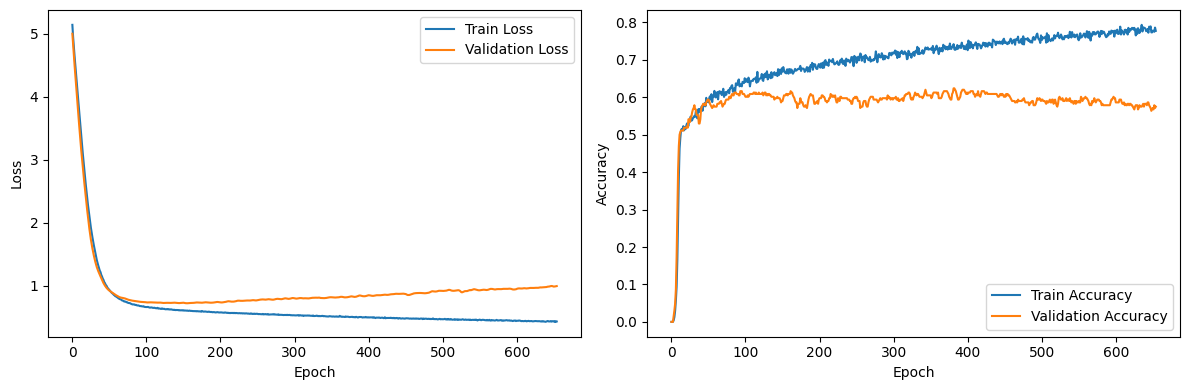


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3704, Val Loss: 3.2699, Train Acc: 0.4161, Val Acc: 0.4941
Epoch: 020, Train Loss: 2.1886, Val Loss: 2.1661, Train Acc: 0.5411, Val Acc: 0.5686
Epoch: 030, Train Loss: 1.4482, Val Loss: 1.4463, Train Acc: 0.5629, Val Acc: 0.5255
Epoch: 040, Train Loss: 1.0797, Val Loss: 1.1232, Train Acc: 0.5881, Val Acc: 0.5529
Epoch: 050, Train Loss: 0.9074, Val Loss: 0.9414, Train Acc: 0.5931, Val Acc: 0.5451
Epoch: 060, Train Loss: 0.8033, Val Loss: 0.8418, Train Acc: 0.6065, Val Acc: 0.5765
Epoch: 070, Train Loss: 0.7476, Val Loss: 0.7928, Train Acc: 0.6242, Val Acc: 0.5569
Epoch: 080, Train Loss: 0.6983, Val Loss: 0.7631, Train Acc: 0.6326, Val Acc: 0.5608
Epoch: 090, Train Loss: 0.6682, Val Loss: 0.7493, Train Acc: 0.6426, Val Acc: 0.5569
Epoch: 100, Train Loss: 0.6570, Val Loss: 0.7290, Train Acc: 0.6443, Val Acc: 0.5725
Epoch: 110, Train Loss: 0.6400, Val Loss: 0.7217, Tr

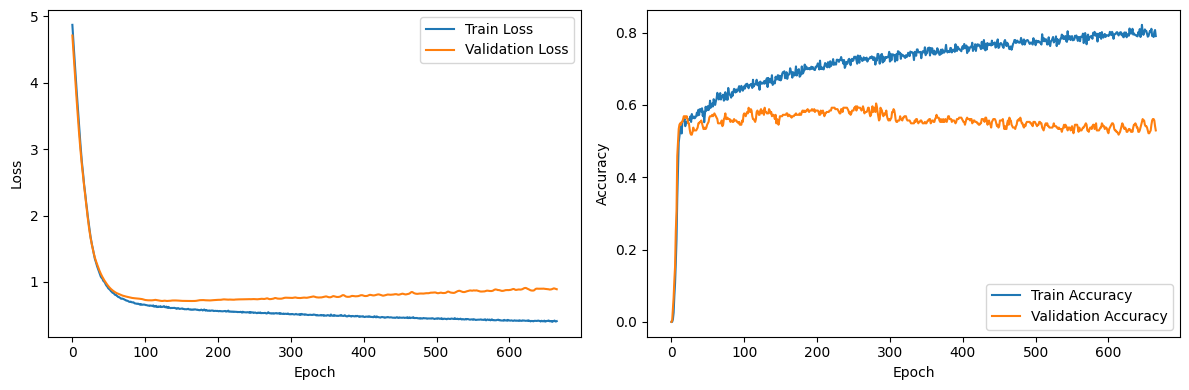


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2351, Val Loss: 3.0842, Train Acc: 0.4755, Val Acc: 0.5085
Epoch: 020, Train Loss: 2.2251, Val Loss: 2.1830, Train Acc: 0.5309, Val Acc: 0.5466
Epoch: 030, Train Loss: 1.5531, Val Loss: 1.5784, Train Acc: 0.5481, Val Acc: 0.5636
Epoch: 040, Train Loss: 1.1752, Val Loss: 1.2042, Train Acc: 0.5617, Val Acc: 0.5593
Epoch: 050, Train Loss: 0.9652, Val Loss: 1.0229, Train Acc: 0.5871, Val Acc: 0.5212
Epoch: 060, Train Loss: 0.8436, Val Loss: 0.9128, Train Acc: 0.5953, Val Acc: 0.5169
Epoch: 070, Train Loss: 0.7651, Val Loss: 0.8411, Train Acc: 0.6279, Val Acc: 0.5424
Epoch: 080, Train Loss: 0.7277, Val Loss: 0.8031, Train Acc: 0.6252, Val Acc: 0.5551
Epoch: 090, Train Loss: 0.6950, Val Loss: 0.7663, Train Acc: 0.6388, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6706, Val Loss: 0.7518, Train Acc: 0.6470, Val Acc: 0.5466
Epoch: 110, Train Loss: 0.6517, Val Loss: 0.7397, Tr

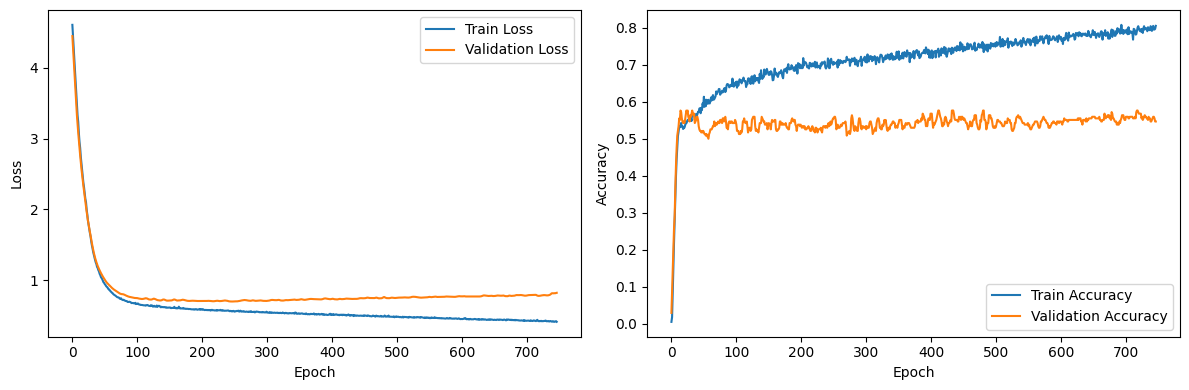


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.2549, Val Loss: 3.0614, Train Acc: 0.3947, Val Acc: 0.3945
Epoch: 020, Train Loss: 2.1355, Val Loss: 2.0300, Train Acc: 0.5167, Val Acc: 0.4495
Epoch: 030, Train Loss: 1.5333, Val Loss: 1.4777, Train Acc: 0.5453, Val Acc: 0.4725
Epoch: 040, Train Loss: 1.1841, Val Loss: 1.1476, Train Acc: 0.5650, Val Acc: 0.5321
Epoch: 050, Train Loss: 0.9823, Val Loss: 0.9729, Train Acc: 0.5915, Val Acc: 0.4954
Epoch: 060, Train Loss: 0.8614, Val Loss: 0.8855, Train Acc: 0.6083, Val Acc: 0.4954
Epoch: 070, Train Loss: 0.8075, Val Loss: 0.8250, Train Acc: 0.5994, Val Acc: 0.5092
Epoch: 080, Train Loss: 0.7488, Val Loss: 0.7899, Train Acc: 0.6024, Val Acc: 0.4908
Epoch: 090, Train Loss: 0.6968, Val Loss: 0.7708, Train Acc: 0.6230, Val Acc: 0.5092
Epoch: 100, Train Loss: 0.6789, Val Loss: 0.7755, Train Acc: 0.6260, Val Acc: 0.5229
Epoch: 110, Train Loss: 0.6508, Val Loss: 0.7557, Tr

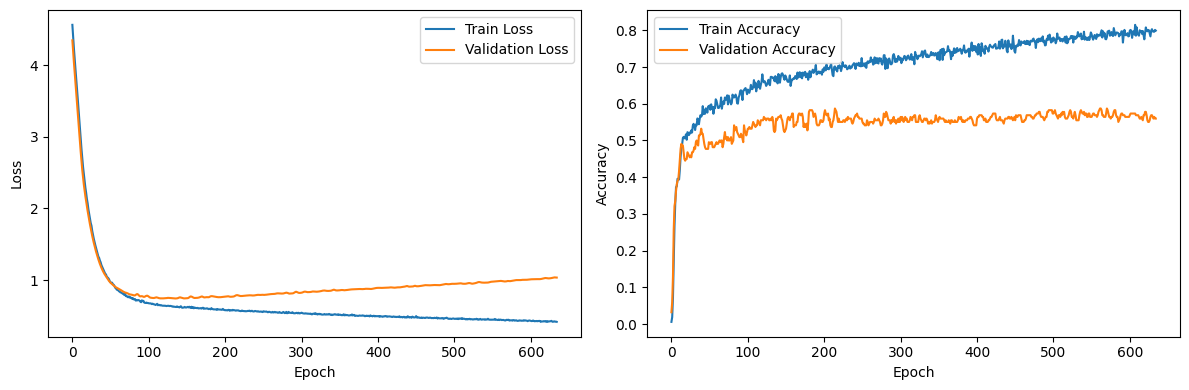


========== Run 28 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3743, Val Loss: 3.1857, Train Acc: 0.4126, Val Acc: 0.4323
Epoch: 020, Train Loss: 2.2553, Val Loss: 2.0842, Train Acc: 0.5254, Val Acc: 0.5226
Epoch: 030, Train Loss: 1.5667, Val Loss: 1.4872, Train Acc: 0.5439, Val Acc: 0.4887
Epoch: 040, Train Loss: 1.1657, Val Loss: 1.1336, Train Acc: 0.5802, Val Acc: 0.5564
Epoch: 050, Train Loss: 0.9527, Val Loss: 0.9632, Train Acc: 0.5931, Val Acc: 0.5564
Epoch: 060, Train Loss: 0.8327, Val Loss: 0.8703, Train Acc: 0.6092, Val Acc: 0.5677
Epoch: 070, Train Loss: 0.7575, Val Loss: 0.8127, Train Acc: 0.6132, Val Acc: 0.5752
Epoch: 080, Train Loss: 0.7132, Val Loss: 0.7825, Train Acc: 0.6326, Val Acc: 0.5789
Epoch: 090, Train Loss: 0.6811, Val Loss: 0.7673, Train Acc: 0.6438, Val Acc: 0.5714
Epoch: 100, Train Loss: 0.6620, Val Loss: 0.7506, Train Acc: 0.6551, Val Acc: 0.5789
Epoch: 110, Train Los

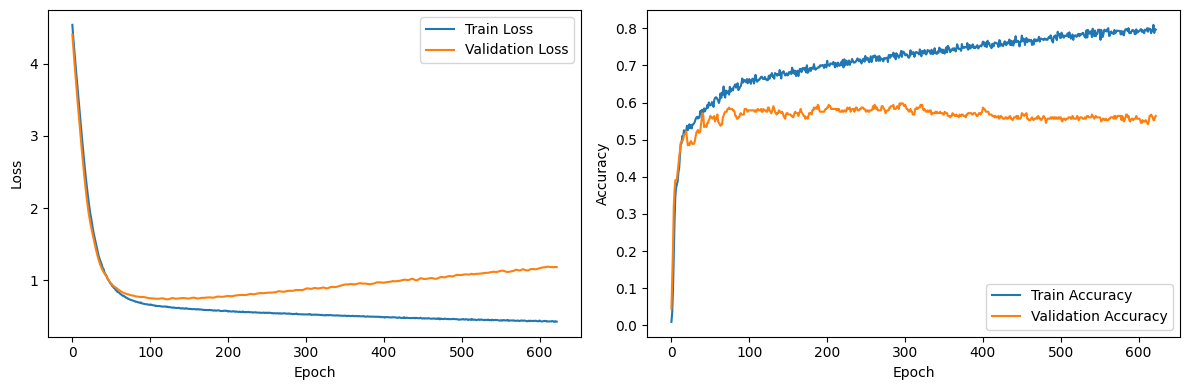


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.6615, Val Loss: 3.5878, Train Acc: 0.1955, Val Acc: 0.1961
Epoch: 020, Train Loss: 2.3944, Val Loss: 2.4003, Train Acc: 0.5654, Val Acc: 0.4784
Epoch: 030, Train Loss: 1.6475, Val Loss: 1.6860, Train Acc: 0.5671, Val Acc: 0.4745
Epoch: 040, Train Loss: 1.1941, Val Loss: 1.2313, Train Acc: 0.5923, Val Acc: 0.4784
Epoch: 050, Train Loss: 0.9574, Val Loss: 1.0128, Train Acc: 0.6032, Val Acc: 0.4941
Epoch: 060, Train Loss: 0.8327, Val Loss: 0.8931, Train Acc: 0.6258, Val Acc: 0.5098
Epoch: 070, Train Loss: 0.7534, Val Loss: 0.8239, Train Acc: 0.6334, Val Acc: 0.5059
Epoch: 080, Train Loss: 0.7009, Val Loss: 0.7822, Train Acc: 0.6510, Val Acc: 0.5216
Epoch: 090, Train Loss: 0.6917, Val Loss: 0.7598, Train Acc: 0.6493, Val Acc: 0.5412
Epoch: 100, Train Loss: 0.6498, Val Loss: 0.7526, Train Acc: 0.6678, Val Acc: 0.5451
Epoch: 110, Train Loss: 0.6453, Val Loss: 0.7309, Tr

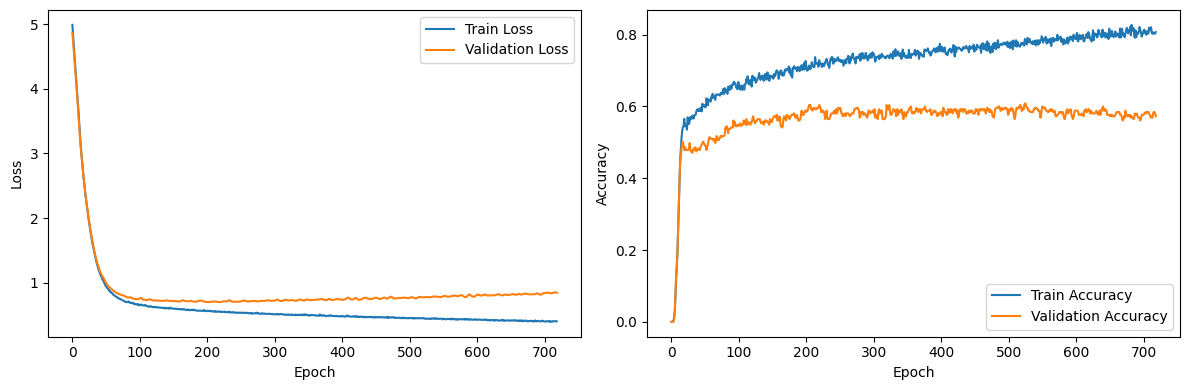


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3938, Val Loss: 3.2499, Train Acc: 0.3947, Val Acc: 0.4025
Epoch: 020, Train Loss: 2.3553, Val Loss: 2.3593, Train Acc: 0.5399, Val Acc: 0.4703
Epoch: 030, Train Loss: 1.6324, Val Loss: 1.6755, Train Acc: 0.5318, Val Acc: 0.4746
Epoch: 040, Train Loss: 1.2027, Val Loss: 1.2837, Train Acc: 0.5626, Val Acc: 0.4873
Epoch: 050, Train Loss: 0.9723, Val Loss: 1.0397, Train Acc: 0.5808, Val Acc: 0.4958
Epoch: 060, Train Loss: 0.8538, Val Loss: 0.9113, Train Acc: 0.5907, Val Acc: 0.5000
Epoch: 070, Train Loss: 0.7788, Val Loss: 0.8425, Train Acc: 0.6062, Val Acc: 0.5551
Epoch: 080, Train Loss: 0.7287, Val Loss: 0.7923, Train Acc: 0.6198, Val Acc: 0.5169
Epoch: 090, Train Loss: 0.7181, Val Loss: 0.7703, Train Acc: 0.6207, Val Acc: 0.5466
Epoch: 100, Train Loss: 0.6786, Val Loss: 0.7562, Train Acc: 0.6307, Val Acc: 0.5593
Epoch: 110, Train Loss: 0.6595, Val Loss: 0.7333, Tr

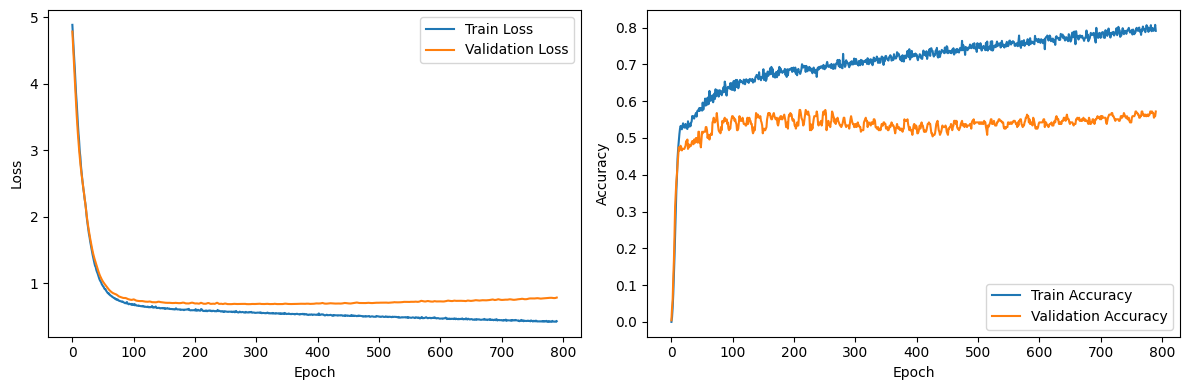


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 2.9816, Val Loss: 2.7602, Train Acc: 0.4094, Val Acc: 0.4358
Epoch: 020, Train Loss: 2.0420, Val Loss: 1.9319, Train Acc: 0.5226, Val Acc: 0.5000
Epoch: 030, Train Loss: 1.4267, Val Loss: 1.3771, Train Acc: 0.5344, Val Acc: 0.5138
Epoch: 040, Train Loss: 1.1228, Val Loss: 1.0999, Train Acc: 0.5561, Val Acc: 0.5000
Epoch: 050, Train Loss: 0.9653, Val Loss: 0.9534, Train Acc: 0.5610, Val Acc: 0.5367
Epoch: 060, Train Loss: 0.8156, Val Loss: 0.8651, Train Acc: 0.6073, Val Acc: 0.5321
Epoch: 070, Train Loss: 0.7786, Val Loss: 0.8004, Train Acc: 0.5955, Val Acc: 0.5229
Epoch: 080, Train Loss: 0.7154, Val Loss: 0.7753, Train Acc: 0.6102, Val Acc: 0.4954
Epoch: 090, Train Loss: 0.6916, Val Loss: 0.7585, Train Acc: 0.6102, Val Acc: 0.5183
Epoch: 100, Train Loss: 0.6680, Val Loss: 0.7527, Train Acc: 0.6250, Val Acc: 0.5275
Epoch: 110, Train Loss: 0.6481, Val Loss: 0.7416, Tr

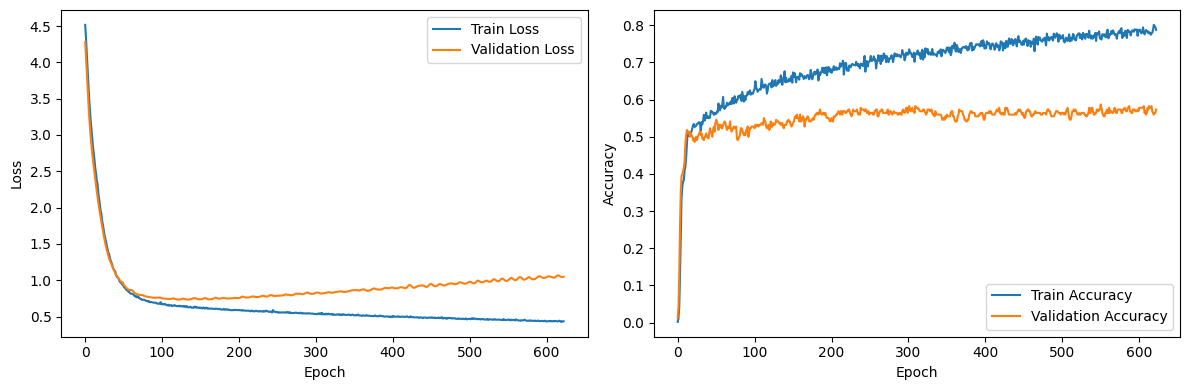


========== Run 29 ==========


Running experiment for year 2019...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3060, Val Loss: 3.1017, Train Acc: 0.4295, Val Acc: 0.4361
Epoch: 020, Train Loss: 2.2732, Val Loss: 2.0989, Train Acc: 0.5181, Val Acc: 0.5113
Epoch: 030, Train Loss: 1.5971, Val Loss: 1.5335, Train Acc: 0.5302, Val Acc: 0.5000
Epoch: 040, Train Loss: 1.1871, Val Loss: 1.1797, Train Acc: 0.5681, Val Acc: 0.5301
Epoch: 050, Train Loss: 0.9593, Val Loss: 0.9982, Train Acc: 0.5923, Val Acc: 0.5414
Epoch: 060, Train Loss: 0.8303, Val Loss: 0.9008, Train Acc: 0.6060, Val Acc: 0.5489
Epoch: 070, Train Loss: 0.7652, Val Loss: 0.8542, Train Acc: 0.6068, Val Acc: 0.5526
Epoch: 080, Train Loss: 0.7124, Val Loss: 0.8191, Train Acc: 0.6342, Val Acc: 0.5639
Epoch: 090, Train Loss: 0.6835, Val Loss: 0.7967, Train Acc: 0.6309, Val Acc: 0.5827
Epoch: 100, Train Loss: 0.6597, Val Loss: 0.7872, Train Acc: 0.6422, Val Acc: 0.5827
Epoch: 110, Train Los

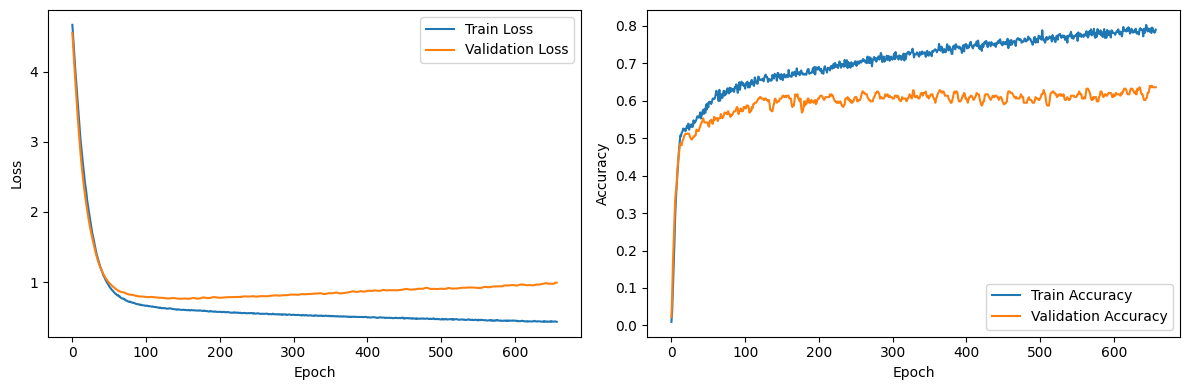


Running experiment for year 2020...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3806, Val Loss: 3.2735, Train Acc: 0.4228, Val Acc: 0.4863
Epoch: 020, Train Loss: 2.1621, Val Loss: 2.0960, Train Acc: 0.5554, Val Acc: 0.5373
Epoch: 030, Train Loss: 1.4983, Val Loss: 1.4791, Train Acc: 0.5763, Val Acc: 0.4980
Epoch: 040, Train Loss: 1.1368, Val Loss: 1.1641, Train Acc: 0.6007, Val Acc: 0.4980
Epoch: 050, Train Loss: 0.9635, Val Loss: 1.0046, Train Acc: 0.6116, Val Acc: 0.5020
Epoch: 060, Train Loss: 0.8423, Val Loss: 0.8989, Train Acc: 0.6267, Val Acc: 0.5176
Epoch: 070, Train Loss: 0.7770, Val Loss: 0.8404, Train Acc: 0.6200, Val Acc: 0.5216
Epoch: 080, Train Loss: 0.7193, Val Loss: 0.8031, Train Acc: 0.6384, Val Acc: 0.5294
Epoch: 090, Train Loss: 0.6915, Val Loss: 0.7880, Train Acc: 0.6527, Val Acc: 0.5333
Epoch: 100, Train Loss: 0.6568, Val Loss: 0.7633, Train Acc: 0.6518, Val Acc: 0.5333
Epoch: 110, Train Loss: 0.6636, Val Loss: 0.7453, Tr

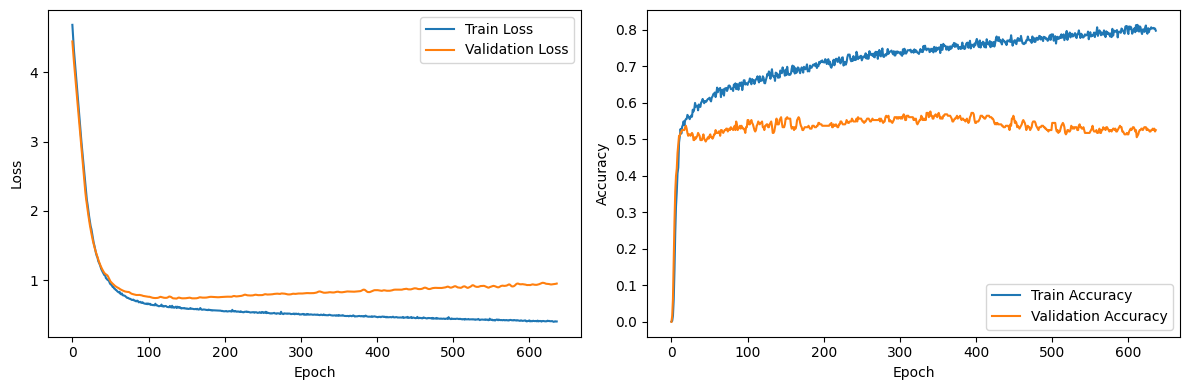


Running experiment for year 2021...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.3050, Val Loss: 3.1740, Train Acc: 0.3947, Val Acc: 0.3771
Epoch: 020, Train Loss: 2.2019, Val Loss: 2.1649, Train Acc: 0.5381, Val Acc: 0.5127
Epoch: 030, Train Loss: 1.5263, Val Loss: 1.5833, Train Acc: 0.5535, Val Acc: 0.4534
Epoch: 040, Train Loss: 1.1693, Val Loss: 1.2410, Train Acc: 0.5662, Val Acc: 0.5042
Epoch: 050, Train Loss: 0.9689, Val Loss: 1.0455, Train Acc: 0.5871, Val Acc: 0.4788
Epoch: 060, Train Loss: 0.8578, Val Loss: 0.9212, Train Acc: 0.6107, Val Acc: 0.5212
Epoch: 070, Train Loss: 0.7823, Val Loss: 0.8458, Train Acc: 0.6407, Val Acc: 0.5085
Epoch: 080, Train Loss: 0.7262, Val Loss: 0.7951, Train Acc: 0.6543, Val Acc: 0.5254
Epoch: 090, Train Loss: 0.7043, Val Loss: 0.7692, Train Acc: 0.6407, Val Acc: 0.5593
Epoch: 100, Train Loss: 0.6773, Val Loss: 0.7544, Train Acc: 0.6588, Val Acc: 0.5254
Epoch: 110, Train Loss: 0.6652, Val Loss: 0.7377, Tr

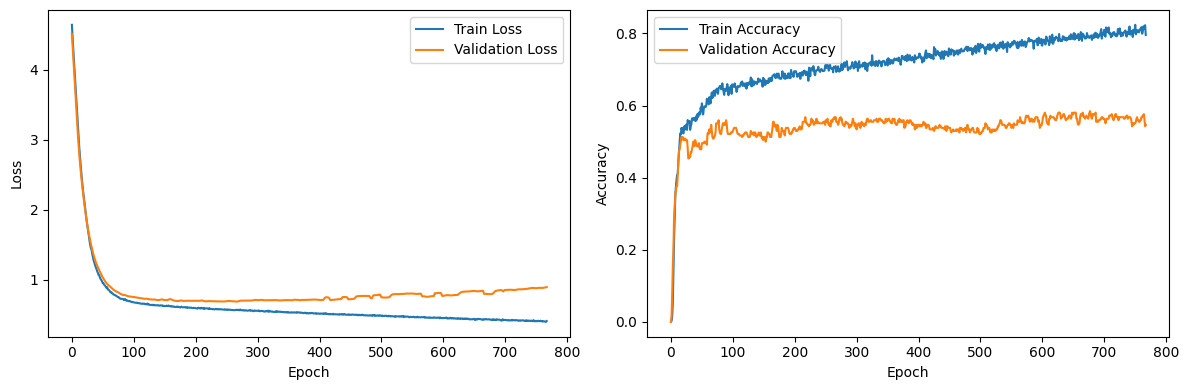


Running experiment for year 2022...

Using device: cuda
Input channels: 11, Number of classes: 2
Epoch: 010, Train Loss: 3.4718, Val Loss: 3.3330, Train Acc: 0.3514, Val Acc: 0.4220
Epoch: 020, Train Loss: 2.3501, Val Loss: 2.2250, Train Acc: 0.5069, Val Acc: 0.5550
Epoch: 030, Train Loss: 1.6141, Val Loss: 1.5500, Train Acc: 0.5276, Val Acc: 0.5275
Epoch: 040, Train Loss: 1.1912, Val Loss: 1.1865, Train Acc: 0.5384, Val Acc: 0.5138
Epoch: 050, Train Loss: 0.9835, Val Loss: 1.0037, Train Acc: 0.5502, Val Acc: 0.5092
Epoch: 060, Train Loss: 0.8443, Val Loss: 0.8969, Train Acc: 0.5846, Val Acc: 0.5367
Epoch: 070, Train Loss: 0.7729, Val Loss: 0.8472, Train Acc: 0.5846, Val Acc: 0.5596
Epoch: 080, Train Loss: 0.7277, Val Loss: 0.8216, Train Acc: 0.6112, Val Acc: 0.5596
Epoch: 090, Train Loss: 0.6926, Val Loss: 0.8024, Train Acc: 0.6171, Val Acc: 0.5505
Epoch: 100, Train Loss: 0.6821, Val Loss: 0.7843, Train Acc: 0.6191, Val Acc: 0.5138
Epoch: 110, Train Loss: 0.6508, Val Loss: 0.7838, Tr

In [ ]:
if __name__ == "__main__":

    years = [2019, 2020, 2021, 2022]
    metric = 'revenue'

    # To store results for each year across 10 runs
    aggregate_results = {year: {'acc': [], 'f1': [], 'time': [], 'epochs': [], 'best_train_acc': []} for year in years}
    param = {
            "hidden_channels": 64,
            "out_channels": 32,
            "num_heads": 4,
            "lr": 0.0009,
            "weight_decay": 5e-4,
            "epochs": 1000,
            "patience": 500
        }

    #Add optuna code section here
    best_params_per_year = {}
    # for year in years:
    #     print(f"\nRunning Optuna optimization for year {year}...\n")
    
    #     study = optuna.create_study(direction="maximize")
    #     study.optimize(lambda trial: objective(trial, year, metric), n_trials=15)
    
    #     print(f"Best trial for year {year}: {study.best_trial.value}")
    #     print("Best hyperparameters:", study.best_params)

    #     best_params_per_year[year] = study.best_params
    
    for i in range(1, 30):
        print(f"\n========== Run {i} ==========\n")
        for year in years:
            # param = best_params_per_year[year]
            print(f"\nRunning experiment for year {year}...\n")
            results = run_experiment(year, metric, **param)
            # Store individual run metrics
            aggregate_results[year]['acc'].append(results['test_acc'])
            aggregate_results[year]['f1'].append(results['test_f1'])
            aggregate_results[year]['time'].append(results['training_time'])
            aggregate_results[year]['epochs'].append(results['epochs_run'])
            aggregate_results[year]['best_train_acc'].append(results['best_train_acc'])

    print("\n========== Final Summary ==========\n")
    for year in years:
        acc_mean = np.mean(aggregate_results[year]['acc'])
        acc_std = np.std(aggregate_results[year]['acc'])
        f1_mean = np.mean(aggregate_results[year]['f1'])
        f1_std = np.std(aggregate_results[year]['f1'])
        train_acc_mean = np.mean(aggregate_results[year]['best_train_acc'])
        train_acc_std = np.std(aggregate_results[year]['best_train_acc'])

        print(f"Year: {year}")
        print(f"  Avg Test Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
        print(f"  Avg Test F1 Score: {f1_mean:.4f} ± {f1_std:.4f}")
        print(f" Train Accuracy: {train_acc_mean:.4f} ± {train_acc_std:.4f}")